# CTM Internal Dynamics and Evidence Accumulation

This notebook investigates the internal dynamics of the Continuous Thought Machine (CTM) trained on the reach-to-grasp task.

The eventual analysis will examine:

1. correlated groups of CTM state units,
2. their relationship to object recognition and certainty,
3. population trajectories,
4. whether the resulting dynamics support an evidence-accumulation interpretation.

Before performing any population analysis, we first establish exactly what the relevant tensors mean in the implementation.

In particular, we distinguish:

- movement observations from CTM internal ticks,
- pre-activation from post-activation state,
- neuronal/state-unit activity from synchronization features,
- class logits from certainty,
- chronological movement time from the CTM's recurrent computation time.

No new model is trained in this notebook.

## 1. Untrained architecture audit

The model instantiated in this section is **freshly initialized**.

It is used only to verify the implementation, tensor shapes, tracking semantics, synchronization timing, and input-order behaviour. Although the audit uses real RTG inputs, activity magnitudes and predictions from this section are **not** interpreted as learned RTG behaviour.

All learned-dynamics observations later in the notebook use the restored P1 checkpoint.


![alt text](<Screenshot 2026-09-29 at 20.46.30.png>)

In [1]:
from pathlib import Path
import inspect

import numpy as np
import pandas as pd
import torch

import rtg_experiment_runner

from rtg_experiment_runner import (
    RTGExperimentConfig,
)

from experiment_runner import (
    build_model,
    resolve_device,
)


config = RTGExperimentConfig()

device = resolve_device(
    config.device
)

model = build_model(
    config,
    device,
)

model.eval()


print(
    "Model class:",
    type(model),
)

print(
    "Model source:",
    Path(
        inspect.getfile(
            type(model)
        )
    ).resolve(),
)

print()
print("Architecture")

for name in [
    "iterations",
    "d_model",
    "d_input",
    "memory_length",
    "n_synch_out",
    "n_synch_action",
    "out_dims",
    "backbone_type",
    "positional_embedding_type",
    "neuron_select_type",
]:

    print(
        f"{name:28s}",
        getattr(
            model,
            name,
        ),
    )

Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Model class: <class 'models.ctm.ContinuousThoughtMachine'>
Model source: /Users/arthu/Desktop/CTM_Res-Pro/models/ctm_official/models/ctm.py

Architecture
iterations                   25
d_model                      256
d_input                      64
memory_length                15
n_synch_out                  32
n_synch_action               32
out_dims                     8
backbone_type                none
positional_embedding_type    none
neuron_select_type           random-pairing


/Users/arthu/miniconda3/envs/ctm_robotics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Real forward-pass tensor audit

The CTM receives the complete reach-to-grasp trajectory before its internal recurrent computation begins.

For this audit, we pass real B0 inputs through the **untrained** CTM instantiated above. The purpose is only to verify tensor meaning and shape.

The CTM's `track=True` mode records:

- current pre-activations,
- post-activations,
- action synchronization,
- output synchronization,
- attention weights.

This lets us inspect the model's internal tensors without changing the architecture.


### Synchronization timing

The two synchronization signals are evaluated at different points in one CTM tick:

1. **action synchronization** uses the activated state **entering** the tick and forms the attention query;
2. the synapse and neuron-level models produce the updated post-activation state;
3. **output synchronization** uses this **newly updated** state and is projected to class logits.

Therefore, action and output synchronization with the same tick index do not refer to the same state time point.

At the first tracked tick, action synchronization uses the learned initial state, while the first tracked post-activation is the state produced after the first recurrent update.


In [2]:
bundle = (
    rtg_experiment_runner
    .build_final_b0_transfer_bundle(
        config=config
    )
)


X_batch, y_batch = next(
    iter(
        bundle[
            "train_loader"
        ]
    )
)


# Only two real B0 recordings are needed for the shape audit.
X_check = X_batch[
    :2
].to(
    device
)


with torch.no_grad():

    tracked = model(
        X_check,
        track=True,
    )


(
    predictions,
    certainties,
    (
        synch_out,
        synch_action,
    ),
    pre_activations,
    post_activations,
    attention,
) = tracked


# The input feature projection can now be inspected directly.
with torch.no_grad():

    kv = model.compute_features(
        X_check
    )


print(
    "Input:",
    tuple(
        X_check.shape
    ),
)

print(
    "Key/value tokens:",
    tuple(
        kv.shape
    ),
)

print(
    "Initial activated state:",
    tuple(
        model.start_activated_state.shape
    ),
)

print(
    "Initial pre-activation trace:",
    tuple(
        model.start_trace.shape
    ),
)

print()

print(
    "Tracked pre-activations:",
    pre_activations.shape,
)

print(
    "Tracked post-activations:",
    post_activations.shape,
)

print(
    "Action synchronization:",
    synch_action.shape,
)

print(
    "Output synchronization:",
    synch_out.shape,
)

print(
    "Attention weights:",
    attention.shape,
)

print()

print(
    "Logits:",
    tuple(
        predictions.shape
    ),
)

print(
    "Certainties:",
    tuple(
        certainties.shape
    ),
)

print()

print(
    "Observed post-activation range:",
    float(
        post_activations.min()
    ),
    "to",
    float(
        post_activations.max()
    ),
)

print(
    "All post-activations finite:",
    np.isfinite(
        post_activations
    ).all(),
)

Input: (2, 15, 100)
Key/value tokens: (2, 100, 64)
Initial activated state: (256,)
Initial pre-activation trace: (256, 15)

Tracked pre-activations: (25, 2, 256)
Tracked post-activations: (25, 2, 256)
Action synchronization: (25, 2, 32)
Output synchronization: (25, 2, 32)
Attention weights: (25, 2, 4, 1, 100)

Logits: (2, 8, 25)
Certainties: (2, 2, 25)

Observed post-activation range: -0.18121448159217834 to 0.16875773668289185
All post-activations finite: True


### Does the CTM explicitly use movement-frame order?

The RTG CTM has no temporal positional encoding.

Therefore, if the 100 input movement positions are merely permuted while preserving their values, cross-attention should treat them as the same set of key/value tokens.

This test reverses the movement-position axis and compares the model outputs.

A near-zero difference would confirm that the model's 25 internal ticks should not be interpreted as chronological processing of the 100 movement positions.

In [3]:
X_reversed = torch.flip(
    X_check,
    dims=[
        -1
    ],
)


with torch.no_grad():

    original_predictions, original_certainties, _ = model(
        X_check
    )

    reversed_predictions, reversed_certainties, _ = model(
        X_reversed
    )


max_logit_difference = (
    original_predictions
    -
    reversed_predictions
).abs().max().item()


max_certainty_difference = (
    original_certainties
    -
    reversed_certainties
).abs().max().item()


print(
    "Maximum logit difference:",
    max_logit_difference,
)

print(
    "Maximum certainty difference:",
    max_certainty_difference,
)

print(
    "Original predictions:",
    original_predictions.argmax(
        dim=1
    ),
)

print(
    "Reversed predictions:",
    reversed_predictions.argmax(
        dim=1
    ),
)

Maximum logit difference: 1.4901161193847656e-08
Maximum certainty difference: 0.0
Original predictions: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0]], device='mps:0')
Reversed predictions: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0]], device='mps:0')


## 1.1 CTM implementation decisions

The verified RTG configuration uses 25 internal ticks, 256 CTM state units, 15-step state memory, 32 action/output synchronization features, `random-pairing`, no backbone, and no positional embedding.

For a batch:

$$
X \in \mathbb{R}^{B \times 15 \times 100},
$$

which is projected to 100 movement tokens of dimension 64.

Tracked post-activation has shape:

$$
\mathbb{R}^{25 \times B \times 256}.
$$

**Decision:** use **post-activation state** as the primary population variable because it contains all 256 updated CTM state units and is the state used for output synchronization. Pre-activation and synchronization remain diagnostic quantities.

The 25 CTM ticks are internal computation steps, not movement-time samples. The reversal test shows that this configuration does not explicitly encode the order of the 100 input positions.

The activity range in this section comes from an untrained model and is not used as a learned-activity result.


## 2. Restore and verify the trained P1 model

Participant 1 is used as the predetermined pilot for the internal-dynamics analysis.

Before extracting neural activity, we restore the exact saved P1 experiment and verify that:

- the saved configuration is used,
- the reconstructed dataset matches the saved recording identities,
- the reconstructed scaler matches the saved scaler,
- the checkpoint reproduces the saved B1-B4 predictions and per-tick outputs.

No fitting or model selection is performed on B1-B4.

In [4]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

import rtg_experiment_runner

from rtg_experiment_runner import (
    RTGExperimentConfig,
)

from experiment_runner import (
    build_model,
    resolve_device,
)


P1_RUN_DIR = Path(
    "results/rtg/"
    "20260928T141738Z_"
    "participant_1_b0_to_b1_b4_fixed150_seed0"
)


required_files = [
    "checkpoint.pt",
    "config.json",
    "evaluation_settings.json",
    "per_recording_test_predictions.csv",
    "per_tick_test_outputs.npz",
    "scaler.npz",
    "split_metadata.csv",
    "training_history.csv",
]


missing_files = [
    filename
    for filename in required_files
    if not (
        P1_RUN_DIR
        / filename
    ).exists()
]


if missing_files:

    raise FileNotFoundError(
        f"Missing P1 artifacts: {missing_files}"
    )


with (
    P1_RUN_DIR
    / "config.json"
).open(
    "r",
    encoding="utf-8",
) as f:

    config_dict = json.load(
        f
    )


p1_config = RTGExperimentConfig(
    **config_dict
)


with (
    P1_RUN_DIR
    / "evaluation_settings.json"
).open(
    "r",
    encoding="utf-8",
) as f:

    p1_settings = json.load(
        f
    )


print(
    "P1 run directory:",
    P1_RUN_DIR.resolve(),
)

print()
print("Saved evaluation settings:")

for key, value in (
    p1_settings.items()
):

    print(
        f"{key:28s}",
        value,
    )

P1 run directory: /Users/arthu/Desktop/CTM_Res-Pro/models/ctm/results/rtg/20260928T141738Z_participant_1_b0_to_b1_b4_fixed150_seed0

Saved evaluation settings:
participant                  1
n_train                      64
n_test                       128
batch_size                   32
epochs                       75
updates_per_epoch            2
actual_updates               150
selection_rule               fixed optimizer-update budget derived before B1-B4 evaluation
training_representation      harmonized onset-to-lift trajectory resampled to 100 positions
seed                         0


In [5]:
p1_bundle = (
    rtg_experiment_runner
    .build_participant_specific_transfer_bundle(
        config=p1_config,
        participant=1,
    )
)


saved_scaler = np.load(
    P1_RUN_DIR
    / "scaler.npz"
)


mean_difference = np.max(
    np.abs(
        p1_bundle[
            "scaler"
        ]["mean"]
        -
        saved_scaler[
            "mean"
        ]
    )
)


std_difference = np.max(
    np.abs(
        p1_bundle[
            "scaler"
        ]["std"]
        -
        saved_scaler[
            "std"
        ]
    )
)


np.testing.assert_allclose(
    p1_bundle[
        "scaler"
    ]["mean"],
    saved_scaler[
        "mean"
    ],
    rtol=0.0,
    atol=1e-7,
)


np.testing.assert_allclose(
    p1_bundle[
        "scaler"
    ]["std"],
    saved_scaler[
        "std"
    ],
    rtol=0.0,
    atol=1e-7,
)


print(
    "P1 train recordings:",
    len(
        p1_bundle[
            "train_loader"
        ].dataset
    ),
)

print(
    "P1 test recordings:",
    len(
        p1_bundle[
            "test_loader"
        ].dataset
    ),
)

print(
    "Max scaler mean difference:",
    mean_difference,
)

print(
    "Max scaler std difference:",
    std_difference,
)

print(
    "Scaler verification: PASSED"
)

P1 train recordings: 64
P1 test recordings: 128
Max scaler mean difference: 0.0
Max scaler std difference: 0.0
Scaler verification: PASSED


In [6]:
saved_metadata = pd.read_csv(
    P1_RUN_DIR
    / "split_metadata.csv"
)


rebuilt_metadata = (
    p1_bundle[
        "metadata"
    ]
    .reset_index(
        drop=True
    )
)


identity_columns = [
    "participant",
    "block",
    "trial_number",
    "rep_number",
    "attempt_number",
    "class_label",
    "file",
    "split",
]


saved_identity = (
    saved_metadata[
        identity_columns
    ]
    .reset_index(
        drop=True
    )
)


rebuilt_identity = (
    rebuilt_metadata[
        identity_columns
    ]
    .reset_index(
        drop=True
    )
)


pd.testing.assert_frame_equal(
    saved_identity,
    rebuilt_identity,
    check_dtype=False,
)


print(
    "Metadata rows:",
    len(
        rebuilt_identity
    ),
)

print(
    rebuilt_identity[
        "split"
    ].value_counts()
)

print(
    "Recording identity verification: PASSED"
)

Metadata rows: 192
split
test     128
train     64
Name: count, dtype: int64
Recording identity verification: PASSED


In [7]:
checkpoint = torch.load(
    P1_RUN_DIR
    / "checkpoint.pt",
    map_location="cpu",
    weights_only=False,
)


device = resolve_device(
    p1_config.device
)


p1_model = build_model(
    p1_config,
    device,
)


# Materialize the CTM's lazy layers before loading
# the saved state dictionary.
dry_X, _ = next(
    iter(
        p1_bundle[
            "test_loader"
        ]
    )
)


with torch.no_grad():

    p1_model(
        dry_X[
            :1
        ].to(
            device
        )
    )


p1_model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ],
    strict=True,
)


p1_model.eval()


print(
    "Checkpoint epochs:",
    checkpoint[
        "epochs"
    ],
)

print(
    "Checkpoint seed:",
    checkpoint[
        "run_seed"
    ],
)

print(
    "Model device:",
    device,
)

print(
    "P1 checkpoint restoration: PASSED"
)

Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 32
Checkpoint epochs: 75
Checkpoint seed: 0
Model device: mps
P1 checkpoint restoration: PASSED


In [8]:
restored_outputs = (
    rtg_experiment_runner
    .collect_split_predictions(
        model=p1_model,
        loader=p1_bundle[
            "test_loader"
        ],
        device=device,
    )
)


saved_outputs = np.load(
    P1_RUN_DIR
    / "per_tick_test_outputs.npz"
)


# ------------------------------------------------------------
# Exact discrete-output checks
# ------------------------------------------------------------

target_mismatches = np.count_nonzero(
    restored_outputs[
        "targets"
    ]
    !=
    saved_outputs[
        "targets"
    ]
)


mc_prediction_mismatches = np.count_nonzero(
    restored_outputs[
        "most_certain_prediction"
    ]
    !=
    saved_outputs[
        "most_certain_prediction"
    ]
)


final_prediction_mismatches = np.count_nonzero(
    restored_outputs[
        "final_prediction"
    ]
    !=
    saved_outputs[
        "final_prediction"
    ]
)


tick_mismatches = np.count_nonzero(
    restored_outputs[
        "most_certain_tick"
    ]
    !=
    saved_outputs[
        "most_certain_tick"
    ]
)


# ------------------------------------------------------------
# Continuous-output differences
# ------------------------------------------------------------

max_logit_difference = np.max(
    np.abs(
        restored_outputs[
            "logits"
        ]
        -
        saved_outputs[
            "logits"
        ]
    )
)


max_certainty_difference = np.max(
    np.abs(
        restored_outputs[
            "certainties"
        ]
        -
        saved_outputs[
            "certainties"
        ]
    )
)


np.testing.assert_allclose(
    restored_outputs[
        "logits"
    ],
    saved_outputs[
        "logits"
    ],
    rtol=0.0,
    atol=1e-6,
)


np.testing.assert_allclose(
    restored_outputs[
        "certainties"
    ],
    saved_outputs[
        "certainties"
    ],
    rtol=0.0,
    atol=1e-6,
)


assert target_mismatches == 0

assert mc_prediction_mismatches == 0

assert final_prediction_mismatches == 0

assert tick_mismatches == 0


targets = restored_outputs[
    "targets"
]


mc_predictions = restored_outputs[
    "most_certain_prediction"
]


final_predictions = restored_outputs[
    "final_prediction"
]


mc_accuracy = np.mean(
    mc_predictions
    ==
    targets
)


final_accuracy = np.mean(
    final_predictions
    ==
    targets
)


print(
    "B1-B4 recordings:",
    len(
        targets
    ),
)

print(
    "Most-certain accuracy:",
    mc_accuracy,
)

print(
    "Final-tick accuracy:",
    final_accuracy,
)

print()

print(
    "Target mismatches:",
    target_mismatches,
)

print(
    "Most-certain prediction mismatches:",
    mc_prediction_mismatches,
)

print(
    "Final prediction mismatches:",
    final_prediction_mismatches,
)

print(
    "Most-certain tick mismatches:",
    tick_mismatches,
)

print()

print(
    "Maximum logit difference:",
    max_logit_difference,
)

print(
    "Maximum certainty difference:",
    max_certainty_difference,
)

print()

print(
    "P1 saved-output reproduction: PASSED"
)

B1-B4 recordings: 128
Most-certain accuracy: 0.734375
Final-tick accuracy: 0.734375

Target mismatches: 0
Most-certain prediction mismatches: 0
Final prediction mismatches: 0
Most-certain tick mismatches: 0

Maximum logit difference: 0.0
Maximum certainty difference: 0.0

P1 saved-output reproduction: PASSED


### P1 restoration verified

The predetermined P1 pilot was restored successfully.

- B0 training recordings: 64
- B1-B4 test recordings: 128
- training: 75 epochs = 150 optimizer updates
- B1-B4 most-certain accuracy: 73.44% (94/128)
- B1-B4 final-tick accuracy: 73.44%

The reconstructed scaler and recording identities exactly match the saved run.

The restored checkpoint also reproduces the saved targets, selected ticks, predictions, logits, and certainties exactly.

**Decision:** all subsequent P1 internal-dynamics analyses use this verified frozen checkpoint. No fitting or selection is performed using B1-B4.

## 3. Extract trained internal activity

The CTM's tracked post-activation state is used as the primary population activity variable.

Before extracting the full P1 dataset, we verify that enabling internal-state tracking does not change the model's logits, certainty, selected tick, or prediction.

In [9]:
X_check, y_check = next(
    iter(
        p1_bundle[
            "test_loader"
        ]
    )
)

X_check = X_check[
    :8
].to(
    device
)

y_check = y_check[
    :8
]


p1_model.eval()


with torch.inference_mode():

    plain_predictions, plain_certainties, _ = p1_model(
        X_check
    )

    (
        tracked_predictions,
        tracked_certainties,
        (
            tracked_synch_out,
            tracked_synch_action,
        ),
        tracked_pre,
        tracked_post,
        tracked_attention,
    ) = p1_model(
        X_check,
        track=True,
    )


max_logit_difference = (
    plain_predictions
    -
    tracked_predictions
).abs().max().item()


max_certainty_difference = (
    plain_certainties
    -
    tracked_certainties
).abs().max().item()


plain_tick = (
    plain_certainties[
        :,
        1,
        :
    ]
    .argmax(
        dim=1
    )
)


tracked_tick = (
    tracked_certainties[
        :,
        1,
        :
    ]
    .argmax(
        dim=1
    )
)


batch_index = torch.arange(
    len(
        X_check
    ),
    device=device,
)


plain_class = (
    plain_predictions[
        batch_index,
        :,
        plain_tick,
    ]
    .argmax(
        dim=1
    )
)


tracked_class = (
    tracked_predictions[
        batch_index,
        :,
        tracked_tick,
    ]
    .argmax(
        dim=1
    )
)


print(
    "Maximum logit difference:",
    max_logit_difference,
)

print(
    "Maximum certainty difference:",
    max_certainty_difference,
)

print(
    "Selected ticks identical:",
    torch.equal(
        plain_tick,
        tracked_tick,
    ),
)

print(
    "Predictions identical:",
    torch.equal(
        plain_class,
        tracked_class,
    ),
)

print()

print(
    "Tracked pre-activation:",
    tracked_pre.shape,
)

print(
    "Tracked post-activation:",
    tracked_post.shape,
)

print(
    "Output synchronization:",
    tracked_synch_out.shape,
)

print(
    "Action synchronization:",
    tracked_synch_action.shape,
)

print(
    "Attention:",
    tracked_attention.shape,
)


assert max_logit_difference == 0.0
assert max_certainty_difference == 0.0

assert torch.equal(
    plain_tick,
    tracked_tick,
)

assert torch.equal(
    plain_class,
    tracked_class,
)


print()
print(
    "Instrumentation equivalence: PASSED"
)

Maximum logit difference: 0.0
Maximum certainty difference: 0.0
Selected ticks identical: True
Predictions identical: True

Tracked pre-activation: (25, 8, 256)
Tracked post-activation: (25, 8, 256)
Output synchronization: (25, 8, 32)
Action synchronization: (25, 8, 32)
Attention: (25, 8, 4, 1, 100)

Instrumentation equivalence: PASSED


In [10]:
print(
    "Post-activation axes:",
    "[tick, recording, state_unit]"
)

print(
    "Shape:",
    tracked_post.shape,
)

print(
    "Expected ticks:",
    p1_model.iterations,
)

print(
    "Expected state units:",
    p1_model.d_model,
)

print()

print(
    "Observed trained post-activation minimum:",
    float(
        tracked_post.min()
    ),
)

print(
    "Observed trained post-activation maximum:",
    float(
        tracked_post.max()
    ),
)

print(
    "Observed trained post-activation mean:",
    float(
        tracked_post.mean()
    ),
)

print(
    "Observed trained post-activation std:",
    float(
        tracked_post.std()
    ),
)

print(
    "All finite:",
    np.isfinite(
        tracked_post
    ).all(),
)


assert tracked_post.shape == (
    p1_model.iterations,
    len(
        X_check
    ),
    p1_model.d_model,
)

Post-activation axes: [tick, recording, state_unit]
Shape: (25, 8, 256)
Expected ticks: 25
Expected state units: 256

Observed trained post-activation minimum: -4.808917999267578
Observed trained post-activation maximum: 6.24011754989624
Observed trained post-activation mean: 0.022195877507328987
Observed trained post-activation std: 0.42636290192604065
All finite: True


In [11]:
def extract_ctm_activity(
    model,
    loader,
    device,
):

    model.eval()

    all_targets = []

    all_logits = []
    all_certainties = []

    all_pre = []
    all_post = []

    all_synch_out = []
    all_synch_action = []


    with torch.inference_mode():

        for (
            X_batch,
            y_batch,
        ) in loader:

            X_batch = X_batch.to(
                device
            )

            (
                predictions,
                certainties,
                (
                    synch_out,
                    synch_action,
                ),
                pre_activations,
                post_activations,
                _,
            ) = model(
                X_batch,
                track=True,
            )


            all_targets.append(
                y_batch.numpy()
            )

            # [B, class, tick]
            all_logits.append(
                predictions
                .cpu()
                .numpy()
            )

            # [B, 2, tick]
            all_certainties.append(
                certainties
                .cpu()
                .numpy()
            )


            # Tracking returns:
            #
            # [tick, batch, feature]
            #
            # Convert to:
            #
            # [batch, tick, feature]

            all_pre.append(
                np.transpose(
                    pre_activations,
                    (
                        1,
                        0,
                        2,
                    ),
                )
            )

            all_post.append(
                np.transpose(
                    post_activations,
                    (
                        1,
                        0,
                        2,
                    ),
                )
            )

            # IMPORTANT:
            # output synchronization at tick t uses the newly updated
            # post-activation state at tick t.
            all_synch_out.append(
                np.transpose(
                    synch_out,
                    (
                        1,
                        0,
                        2,
                    ),
                )
            )

            # action synchronization at tick t uses the state entering
            # tick t. Its timing is therefore one recurrent update
            # earlier than post_activity[:, t, :] / synch_out[:, t, :].
            all_synch_action.append(
                np.transpose(
                    synch_action,
                    (
                        1,
                        0,
                        2,
                    ),
                )
            )


    targets = np.concatenate(
        all_targets,
        axis=0,
    )

    logits = np.concatenate(
        all_logits,
        axis=0,
    )

    certainties = np.concatenate(
        all_certainties,
        axis=0,
    )

    pre = np.concatenate(
        all_pre,
        axis=0,
    )

    post = np.concatenate(
        all_post,
        axis=0,
    )

    synch_out = np.concatenate(
        all_synch_out,
        axis=0,
    )

    synch_action = np.concatenate(
        all_synch_action,
        axis=0,
    )


    # Convert logits to [recording, tick, class]
    logits_by_tick = np.transpose(
        logits,
        (
            0,
            2,
            1,
        ),
    )


    # Certainty component:
    # 0 = normalized entropy
    # 1 = 1 - normalized entropy
    certainty = certainties[
        :,
        1,
        :
    ]


    predictions_per_tick = (
        logits
        .argmax(
            axis=1
        )
    )


    selected_tick_index = (
        certainty
        .argmax(
            axis=1
        )
    )


    recording_index = np.arange(
        len(
            targets
        )
    )


    selected_prediction = (
        logits[
            recording_index,
            :,
            selected_tick_index,
        ]
        .argmax(
            axis=1
        )
    )


    final_prediction = (
        logits[
            :,
            :,
            -1,
        ]
        .argmax(
            axis=1
        )
    )


    return {
        "targets": targets,

        "pre_activity": pre,
        "post_activity": post,

        "synch_out": synch_out,
        "synch_action": synch_action,

        "logits": logits_by_tick,
        "certainty": certainty,

        "predictions_per_tick": predictions_per_tick,

        "selected_tick_index": selected_tick_index,
        "selected_tick": selected_tick_index + 1,

        "selected_prediction": selected_prediction,
        "final_prediction": final_prediction,
    }

In [12]:
p1_b0_activity = extract_ctm_activity(
    model=p1_model,
    loader=p1_bundle[
        "train_loader"
    ],
    device=device,
)


p1_b1_b4_activity = extract_ctm_activity(
    model=p1_model,
    loader=p1_bundle[
        "test_loader"
    ],
    device=device,
)


print(
    "B0 post-activity:",
    p1_b0_activity[
        "post_activity"
    ].shape,
)

print(
    "B1-B4 post-activity:",
    p1_b1_b4_activity[
        "post_activity"
    ].shape,
)

print()

print(
    "B0 logits:",
    p1_b0_activity[
        "logits"
    ].shape,
)

print(
    "B1-B4 logits:",
    p1_b1_b4_activity[
        "logits"
    ].shape,
)

print()

print(
    "B0 certainty:",
    p1_b0_activity[
        "certainty"
    ].shape,
)

print(
    "B1-B4 certainty:",
    p1_b1_b4_activity[
        "certainty"
    ].shape,
)

B0 post-activity: (64, 25, 256)
B1-B4 post-activity: (128, 25, 256)

B0 logits: (64, 25, 8)
B1-B4 logits: (128, 25, 8)

B0 certainty: (64, 25)
B1-B4 certainty: (128, 25)


In [13]:
p1_metadata = (
    p1_bundle[
        "metadata"
    ]
    .reset_index(
        drop=True
    )
)


p1_b0_metadata = (
    p1_metadata
    .query(
        "split == 'train'"
    )
    .reset_index(
        drop=True
    )
    .copy()
)


p1_b1_b4_metadata = (
    p1_metadata
    .query(
        "split == 'test'"
    )
    .reset_index(
        drop=True
    )
    .copy()
)


assert len(
    p1_b0_metadata
) == len(
    p1_b0_activity[
        "targets"
    ]
)


assert len(
    p1_b1_b4_metadata
) == len(
    p1_b1_b4_activity[
        "targets"
    ]
)


for (
    metadata,
    activity,
) in [
    (
        p1_b0_metadata,
        p1_b0_activity,
    ),
    (
        p1_b1_b4_metadata,
        p1_b1_b4_activity,
    ),
]:

    metadata[
        "target"
    ] = activity[
        "targets"
    ]

    metadata[
        "prediction"
    ] = activity[
        "selected_prediction"
    ]

    metadata[
        "correct"
    ] = (
        metadata[
            "prediction"
        ]
        ==
        metadata[
            "target"
        ]
    )

    metadata[
        "selected_tick"
    ] = activity[
        "selected_tick"
    ]

    metadata[
        "final_prediction"
    ] = activity[
        "final_prediction"
    ]


p1_b1_b4_metadata[
    [
        "participant",
        "block",
        "trial_number",
        "rep_number",
        "attempt_number",
        "class_label",
        "prediction",
        "correct",
        "selected_tick",
    ]
].head(
    10
)

,participant,block,trial_number,rep_number,attempt_number,class_label,prediction,correct,selected_tick
0,1,1,0,0,0,0,0,True,25
1,1,1,0,1,0,0,0,True,25
2,1,1,0,2,0,0,0,True,25
3,1,1,0,3,0,0,0,True,25
4,1,1,1,0,0,1,0,False,25
5,1,1,1,1,0,1,0,False,25
6,1,1,1,2,0,1,1,True,25
7,1,1,1,3,0,1,1,True,25
8,1,1,2,0,0,2,2,True,21
9,1,1,2,1,0,2,2,True,25


In [14]:
assert (
    p1_b0_activity[
        "post_activity"
    ].shape
    ==
    (
        64,
        25,
        256,
    )
)


assert (
    p1_b1_b4_activity[
        "post_activity"
    ].shape
    ==
    (
        128,
        25,
        256,
    )
)


assert np.isfinite(
    p1_b0_activity[
        "post_activity"
    ]
).all()


assert np.isfinite(
    p1_b1_b4_activity[
        "post_activity"
    ]
).all()


# B1-B4 predictions must still be exactly
# the saved verified predictions.

np.testing.assert_array_equal(
    p1_b1_b4_activity[
        "selected_prediction"
    ],
    restored_outputs[
        "most_certain_prediction"
    ],
)


np.testing.assert_array_equal(
    p1_b1_b4_activity[
        "selected_tick"
    ],
    restored_outputs[
        "most_certain_tick"
    ],
)


print(
    "Full P1 activity extraction: PASSED"
)

Full P1 activity extraction: PASSED


### Trained activity extraction verified

Internal-state tracking leaves model behaviour unchanged: logits, certainty, selected ticks, and predictions are identical with and without `track=True`.

For P1 we extracted:

- B0: `(64, 25, 256)`
- B1-B4: `(128, 25, 256)`

stored as:

$$
[\text{recording}, \text{internal tick}, \text{state unit}].
$$

**Decision:** post-activation remains the primary population activity variable. B0 will be used for population discovery, while B1-B4 will be kept as the transfer-evaluation domain.

### 3.1 Separate temporal and between-recording variability

A unit may differ strongly between recordings while changing very little across the 25 internal ticks.

The variability audit therefore separates:

- **within-recording temporal variability**,
- **between-recording variability** in each recording's mean activity,
- the across-recording mean trajectory over internal ticks.

No state unit is selected or removed at this stage.


In [15]:
def compute_unit_variability(
    activity,
    dataset_name,
):
    """
    activity:
        [recording, internal_tick, state_unit]

    Separates temporal variation within recordings from
    variation in average activity between recordings.
    """

    activity = np.asarray(
        activity,
        dtype=np.float64,
    )

    if activity.ndim != 3:
        raise ValueError(
            f"Expected [recording, tick, unit], got {activity.shape}"
        )

    n_recordings, n_ticks, n_units = activity.shape


    # --------------------------------------------------------
    # Total variance
    #
    # All recording x tick observations for each unit.
    # --------------------------------------------------------

    total_variance = activity.var(
        axis=(
            0,
            1,
        ),
        ddof=0,
    )


    # --------------------------------------------------------
    # Within-recording temporal variance
    #
    # First calculate temporal variance separately within
    # every recording, then average across recordings.
    # --------------------------------------------------------

    within_variance_per_recording = activity.var(
        axis=1,
        ddof=0,
    )
    # [recording, unit]


    within_variance = (
        within_variance_per_recording
        .mean(
            axis=0
        )
    )


    # --------------------------------------------------------
    # Between-recording variance
    #
    # Reduce each recording to its mean over internal ticks,
    # then measure how those recording means differ.
    # --------------------------------------------------------

    recording_means = activity.mean(
        axis=1
    )
    # [recording, unit]


    between_variance = recording_means.var(
        axis=0,
        ddof=0,
    )


    # With equal tick counts:
    #
    # total variance
    # =
    # mean within-recording variance
    # +
    # variance between recording means

    decomposition_error = np.abs(
        total_variance
        -
        (
            within_variance
            +
            between_variance
        )
    )


    # --------------------------------------------------------
    # Shared tick-dependent trajectory
    #
    # Mean activity across recordings at every tick.
    #
    # This does NOT establish shared dynamics by itself,
    # but records whether the population mean changes over
    # internal computation.
    # --------------------------------------------------------

    mean_tick_trajectory = activity.mean(
        axis=0
    )
    # [tick, unit]


    shared_tick_std = mean_tick_trajectory.std(
        axis=0,
        ddof=0,
    )


    # --------------------------------------------------------
    # Variance fractions
    # --------------------------------------------------------

    within_fraction = np.divide(
        within_variance,
        total_variance,
        out=np.zeros_like(
            within_variance
        ),
        where=total_variance > 0,
    )


    between_fraction = np.divide(
        between_variance,
        total_variance,
        out=np.zeros_like(
            between_variance
        ),
        where=total_variance > 0,
    )


    global_std = float(
        activity.std(
            ddof=0
        )
    )


    near_static_threshold = (
        global_std
        *
        1e-4
    )


    unit_table = pd.DataFrame(
        {
            "dataset": dataset_name,

            "state_unit": np.arange(
                n_units
            ),

            "total_std": np.sqrt(
                total_variance
            ),

            "within_recording_std": np.sqrt(
                within_variance
            ),

            "between_recording_std": np.sqrt(
                between_variance
            ),

            "within_variance_fraction": (
                within_fraction
            ),

            "between_variance_fraction": (
                between_fraction
            ),

            "shared_tick_std": (
                shared_tick_std
            ),
        }
    )


    summary = {
        "dataset": dataset_name,

        "n_recordings": n_recordings,
        "n_ticks": n_ticks,
        "n_state_units": n_units,

        "minimum": float(
            activity.min()
        ),

        "maximum": float(
            activity.max()
        ),

        "global_std": global_std,

        "nonfinite_values": int(
            (~np.isfinite(
                activity
            )).sum()
        ),

        "constant_units_total": int(
            np.sum(
                total_variance == 0
            )
        ),

        "near_static_within_recording_units": int(
            np.sum(
                np.sqrt(
                    within_variance
                )
                <
                near_static_threshold
            )
        ),

        "median_within_recording_std": float(
            np.median(
                np.sqrt(
                    within_variance
                )
            )
        ),

        "median_between_recording_std": float(
            np.median(
                np.sqrt(
                    between_variance
                )
            )
        ),

        "median_within_variance_fraction": float(
            np.median(
                within_fraction
            )
        ),

        "median_shared_tick_std": float(
            np.median(
                shared_tick_std
            )
        ),

        "variance_decomposition_max_error": float(
            decomposition_error.max()
        ),

        "near_static_threshold": float(
            near_static_threshold
        ),
    }


    return (
        summary,
        unit_table,
    )

In [16]:
(
    b0_variability_summary,
    b0_unit_variability,
) = compute_unit_variability(
    p1_b0_activity[
        "post_activity"
    ],
    "P1 B0",
)


(
    b1_b4_variability_summary,
    b1_b4_unit_variability,
) = compute_unit_variability(
    p1_b1_b4_activity[
        "post_activity"
    ],
    "P1 B1-B4",
)


variability_summary = pd.DataFrame(
    [
        b0_variability_summary,
        b1_b4_variability_summary,
    ]
)


variability_summary

,dataset,n_recordings,n_ticks,n_state_units,minimum,maximum,global_std,nonfinite_values,constant_units_total,near_static_within_recording_units,median_within_recording_std,median_between_recording_std,median_within_variance_fraction,median_shared_tick_std,variance_decomposition_max_error,near_static_threshold
0,P1 B0,64,25,256,-6.378977,7.898174,0.417901,0,0,0,0.025825,0.027980,0.438918,0.009452,5.773160e-15,0.000042
1,P1 B1-B4,128,25,256,-7.084991,8.049704,0.405145,0,0,0,0.027162,0.029214,0.433060,0.012627,6.661338e-15,0.000041


In [17]:
unit_variability = pd.concat(
    [
        b0_unit_variability,
        b1_b4_unit_variability,
    ],
    ignore_index=True,
)


print(
    "Per-unit variability rows:",
    len(
        unit_variability
    ),
)


unit_variability.head()


Per-unit variability rows: 512


,dataset,state_unit,total_std,within_recording_std,between_recording_std,within_variance_fraction,between_variance_fraction,shared_tick_std
0,P1 B0,0,0.040389,0.028214,0.028901,0.487959,0.512041,0.021782
1,P1 B0,1,0.015716,0.010892,0.011330,0.480272,0.519728,0.008194
2,P1 B0,2,0.012309,0.009297,0.008066,0.570536,0.429464,0.003160
3,P1 B0,3,0.020918,0.015785,0.013726,0.569440,0.430560,0.007963
4,P1 B0,4,0.031399,0.020778,0.023541,0.437898,0.562102,0.005521


## 4. Explanatory plots

The figures below are descriptive checks of the restored trained model. They are not used to select state units or fit a population model.

### Deterministic example

The example is selected by metadata ordering rather than model performance or visual appearance. This avoids choosing a trial because it produces especially convenient internal dynamics.


In [18]:
sort_columns = [
    "participant",
    "block",
    "trial_number",
    "rep_number",
    "attempt_number",
    "file",
]


example_order = (
    p1_b1_b4_metadata
    .sort_values(
        sort_columns
    )
    .index
    .to_numpy()
)


example_idx = int(
    example_order[
        0
    ]
)


example_metadata = (
    p1_b1_b4_metadata
    .loc[
        example_idx
    ]
)


example_metadata[
    [
        "participant",
        "block",
        "trial_number",
        "rep_number",
        "attempt_number",
        "class_label",
        "prediction",
        "correct",
        "selected_tick",
        "file",
    ]
]

participant                                 1
block                                       1
trial_number                                0
rep_number                                  0
attempt_number                              0
class_label                                 0
prediction                                  0
correct                                  True
selected_tick                              25
file              B1_trial0_rep0_attempt0.csv
Name: 0, dtype: object

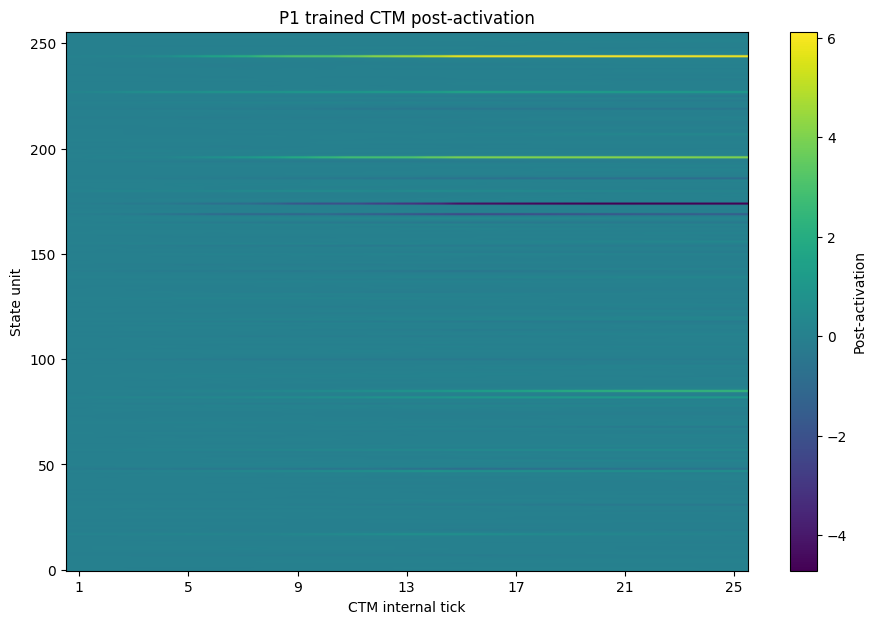

In [19]:
import matplotlib.pyplot as plt


example_activity = (
    p1_b1_b4_activity[
        "post_activity"
    ][
        example_idx
    ]
)

# [25 ticks, 256 units]


fig, ax = plt.subplots(
    figsize=(
        11,
        7,
    )
)


image = ax.imshow(
    example_activity.T,
    aspect="auto",
    origin="lower",
)


ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "State unit"
)

ax.set_title(
    "P1 trained CTM post-activation"
)


ticks = np.arange(
    0,
    25,
    4,
)

ax.set_xticks(
    ticks
)

ax.set_xticklabels(
    ticks + 1
)


fig.colorbar(
    image,
    ax=ax,
    label="Post-activation",
)


plt.show()

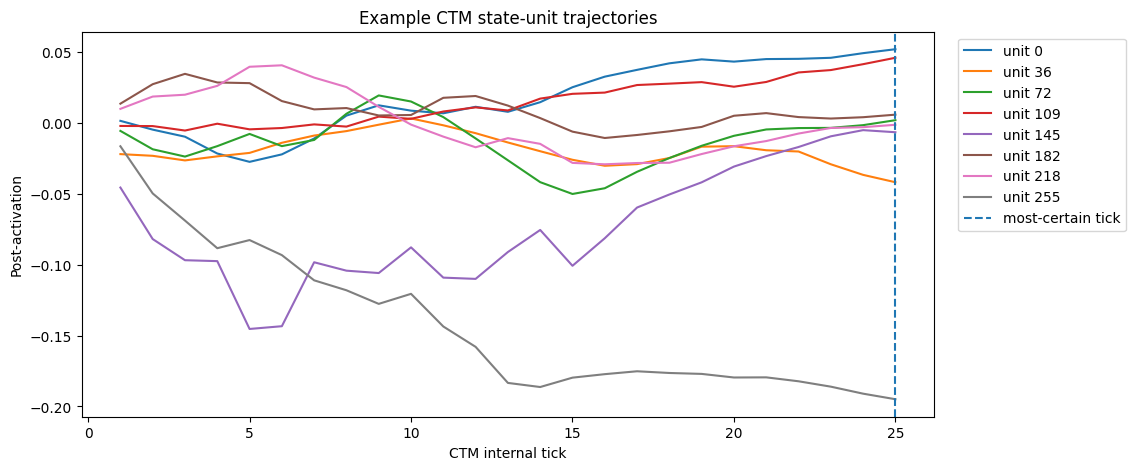

In [20]:
trace_units = np.linspace(
    0,
    p1_model.d_model - 1,
    8,
    dtype=int,
)


fig, ax = plt.subplots(
    figsize=(
        11,
        5,
    )
)


ticks = np.arange(
    1,
    p1_model.iterations + 1,
)


for unit in trace_units:

    ax.plot(
        ticks,
        example_activity[
            :,
            unit
        ],
        label=f"unit {unit}",
    )


ax.axvline(
    example_metadata[
        "selected_tick"
    ],
    linestyle="--",
    label="most-certain tick",
)


ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "Post-activation"
)

ax.set_title(
    "Example CTM state-unit trajectories"
)

ax.legend(
    bbox_to_anchor=(
        1.02,
        1,
    ),
    loc="upper left",
)


plt.show()

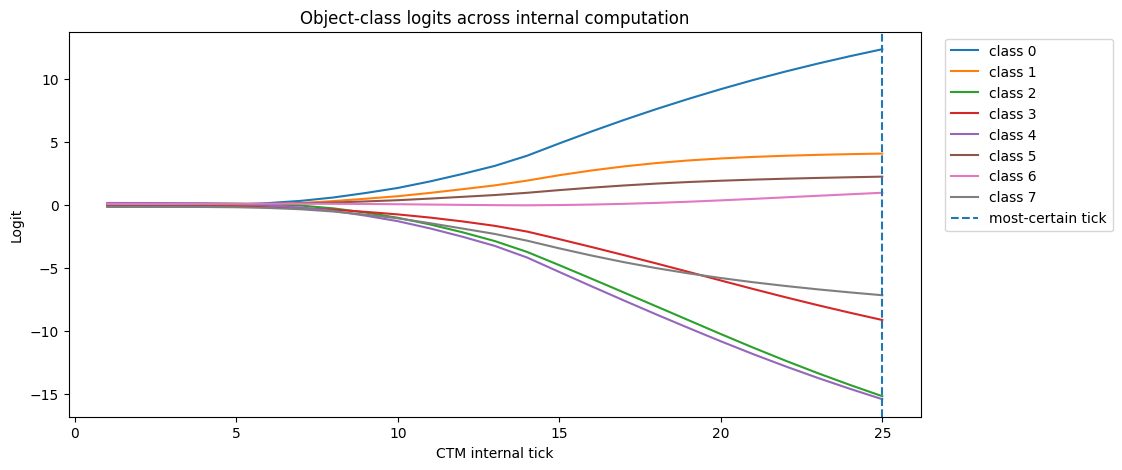

In [21]:
example_logits = (
    p1_b1_b4_activity[
        "logits"
    ][
        example_idx
    ]
)

# [25 ticks, 8 classes]


fig, ax = plt.subplots(
    figsize=(
        11,
        5,
    )
)


for class_id in range(
    example_logits.shape[
        1
    ]
):

    ax.plot(
        ticks,
        example_logits[
            :,
            class_id
        ],
        label=f"class {class_id}",
    )


ax.axvline(
    example_metadata[
        "selected_tick"
    ],
    linestyle="--",
    label="most-certain tick",
)


ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "Logit"
)

ax.set_title(
    "Object-class logits across internal computation"
)

ax.legend(
    bbox_to_anchor=(
        1.02,
        1,
    ),
    loc="upper left",
)


plt.show()

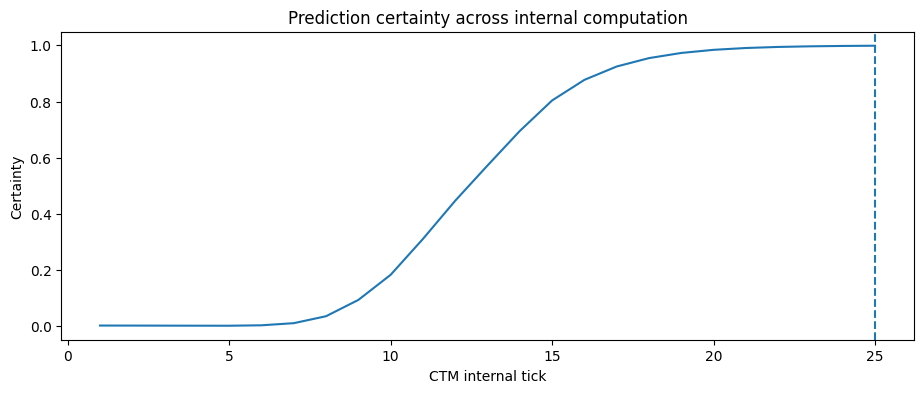

In [22]:
example_certainty = (
    p1_b1_b4_activity[
        "certainty"
    ][
        example_idx
    ]
)


example_predictions = (
    p1_b1_b4_activity[
        "predictions_per_tick"
    ][
        example_idx
    ]
)


fig, ax = plt.subplots(
    figsize=(
        11,
        4,
    )
)


ax.plot(
    ticks,
    example_certainty,
)


ax.axvline(
    example_metadata[
        "selected_tick"
    ],
    linestyle="--",
)


ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "Certainty"
)

ax.set_title(
    "Prediction certainty across internal computation"
)


plt.show()

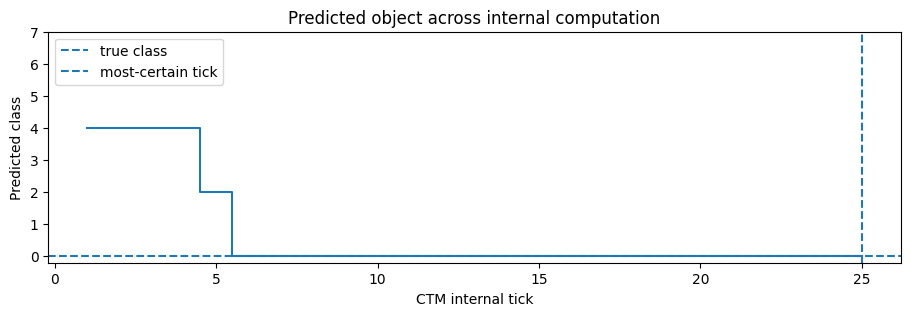

In [23]:
fig, ax = plt.subplots(
    figsize=(
        11,
        3,
    )
)


ax.step(
    ticks,
    example_predictions,
    where="mid",
)


ax.axhline(
    example_metadata[
        "class_label"
    ],
    linestyle="--",
    label="true class",
)


ax.axvline(
    example_metadata[
        "selected_tick"
    ],
    linestyle="--",
    label="most-certain tick",
)


ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "Predicted class"
)

ax.set_yticks(
    range(
        8
    )
)

ax.set_title(
    "Predicted object across internal computation"
)

ax.legend()


plt.show()

### Foundation observations

The full P1 extraction is numerically well behaved:

- no non-finite values,
- no globally constant state units,
- no units fall below the documented near-static **within-recording** threshold,
- within-recording temporal variability is explicitly separated from between-recording variability.

The deterministic B1-B4 example shows changes in state activity, class logits, certainty, and categorical prediction across internal computation.

These observations support the presence of internal CTM dynamics. They do **not** establish evidence accumulation, decision thresholds, or a drift-diffusion process.


In [24]:
from pathlib import Path

FOUNDATION_DIR = Path(
    "results/"
    "rtg_internal_dynamics_ddm/"
    "p1_foundation"
)

FOUNDATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def save_activity_npz(
    path,
    activity,
):

    np.savez_compressed(
        path,

        targets=activity[
            "targets"
        ],

        pre_activity=activity[
            "pre_activity"
        ],

        post_activity=activity[
            "post_activity"
        ],

        synch_out=activity[
            "synch_out"
        ],

        synch_action=activity[
            "synch_action"
        ],

        logits=activity[
            "logits"
        ],

        certainty=activity[
            "certainty"
        ],

        predictions_per_tick=activity[
            "predictions_per_tick"
        ],

        selected_tick_index=activity[
            "selected_tick_index"
        ],

        selected_tick=activity[
            "selected_tick"
        ],

        selected_prediction=activity[
            "selected_prediction"
        ],

        final_prediction=activity[
            "final_prediction"
        ],
    )


save_activity_npz(
    FOUNDATION_DIR
    / "p1_b0_activity.npz",
    p1_b0_activity,
)


save_activity_npz(
    FOUNDATION_DIR
    / "p1_b1_b4_activity.npz",
    p1_b1_b4_activity,
)


p1_b0_metadata.to_csv(
    FOUNDATION_DIR
    / "p1_b0_metadata.csv",
    index=False,
)


p1_b1_b4_metadata.to_csv(
    FOUNDATION_DIR
    / "p1_b1_b4_metadata.csv",
    index=False,
)


variability_summary.to_csv(
    FOUNDATION_DIR
    / "variability_summary.csv",
    index=False,
)


unit_variability.to_csv(
    FOUNDATION_DIR
    / "unit_variability.csv",
    index=False,
)


print(
    "Foundation exports saved to:",
    FOUNDATION_DIR.resolve(),
)


Foundation exports saved to: /Users/arthu/Desktop/CTM_Res-Pro/models/ctm/results/rtg_internal_dynamics_ddm/p1_foundation


In [25]:
import hashlib
import inspect
import json
import platform
import sys


def sha256_file(
    path,
):

    hash_object = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b"",
        ):

            hash_object.update(
                chunk
            )

    return hash_object.hexdigest()


# ============================================================
# Recompute verification quantities for provenance
# ============================================================


# ------------------------------------------------------------
# A. Instrumentation equivalence
# ------------------------------------------------------------

provenance_X, _ = next(
    iter(
        p1_bundle[
            "test_loader"
        ]
    )
)

provenance_X = provenance_X[
    :8
].to(
    device
)


p1_model.eval()


with torch.inference_mode():

    (
        provenance_plain_predictions,
        provenance_plain_certainties,
        _,
    ) = p1_model(
        provenance_X
    )

    (
        provenance_tracked_predictions,
        provenance_tracked_certainties,
        _,
        _,
        _,
        _,
    ) = p1_model(
        provenance_X,
        track=True,
    )


instrumentation_max_logit_difference = float(
    (
        provenance_plain_predictions
        -
        provenance_tracked_predictions
    )
    .abs()
    .max()
    .item()
)


instrumentation_max_certainty_difference = float(
    (
        provenance_plain_certainties
        -
        provenance_tracked_certainties
    )
    .abs()
    .max()
    .item()
)


instrumentation_plain_tick = (
    provenance_plain_certainties[
        :,
        1,
        :
    ]
    .argmax(
        dim=1
    )
)


instrumentation_tracked_tick = (
    provenance_tracked_certainties[
        :,
        1,
        :
    ]
    .argmax(
        dim=1
    )
)


instrumentation_batch_index = torch.arange(
    len(
        provenance_X
    ),
    device=device,
)


instrumentation_plain_class = (
    provenance_plain_predictions[
        instrumentation_batch_index,
        :,
        instrumentation_plain_tick,
    ]
    .argmax(
        dim=1
    )
)


instrumentation_tracked_class = (
    provenance_tracked_predictions[
        instrumentation_batch_index,
        :,
        instrumentation_tracked_tick,
    ]
    .argmax(
        dim=1
    )
)


instrumentation_selected_ticks_identical = bool(
    torch.equal(
        instrumentation_plain_tick,
        instrumentation_tracked_tick,
    )
)


instrumentation_predictions_identical = bool(
    torch.equal(
        instrumentation_plain_class,
        instrumentation_tracked_class,
    )
)


instrumentation_passed = bool(
    instrumentation_max_logit_difference <= 1e-6
    and instrumentation_max_certainty_difference <= 1e-6
    and instrumentation_selected_ticks_identical
    and instrumentation_predictions_identical
)


# ------------------------------------------------------------
# B. Saved-checkpoint reproduction
# ------------------------------------------------------------

provenance_restored_outputs = (
    rtg_experiment_runner
    .collect_split_predictions(
        model=p1_model,
        loader=p1_bundle[
            "test_loader"
        ],
        device=device,
    )
)


with np.load(
    P1_RUN_DIR
    / "per_tick_test_outputs.npz"
) as provenance_saved_outputs:

    restoration_target_mismatches = int(
        np.count_nonzero(
            provenance_restored_outputs[
                "targets"
            ]
            !=
            provenance_saved_outputs[
                "targets"
            ]
        )
    )

    restoration_mc_prediction_mismatches = int(
        np.count_nonzero(
            provenance_restored_outputs[
                "most_certain_prediction"
            ]
            !=
            provenance_saved_outputs[
                "most_certain_prediction"
            ]
        )
    )

    restoration_final_prediction_mismatches = int(
        np.count_nonzero(
            provenance_restored_outputs[
                "final_prediction"
            ]
            !=
            provenance_saved_outputs[
                "final_prediction"
            ]
        )
    )

    restoration_tick_mismatches = int(
        np.count_nonzero(
            provenance_restored_outputs[
                "most_certain_tick"
            ]
            !=
            provenance_saved_outputs[
                "most_certain_tick"
            ]
        )
    )

    restoration_max_logit_difference = float(
        np.max(
            np.abs(
                provenance_restored_outputs[
                    "logits"
                ]
                -
                provenance_saved_outputs[
                    "logits"
                ]
            )
        )
    )

    restoration_max_certainty_difference = float(
        np.max(
            np.abs(
                provenance_restored_outputs[
                    "certainties"
                ]
                -
                provenance_saved_outputs[
                    "certainties"
                ]
            )
        )
    )


restoration_passed = bool(
    restoration_target_mismatches == 0
    and restoration_mc_prediction_mismatches == 0
    and restoration_final_prediction_mismatches == 0
    and restoration_tick_mismatches == 0
    and restoration_max_logit_difference <= 1e-6
    and restoration_max_certainty_difference <= 1e-6
)


# ------------------------------------------------------------
# C. Scaler and recording-identity reconstruction
# ------------------------------------------------------------

with np.load(
    P1_RUN_DIR
    / "scaler.npz"
) as provenance_saved_scaler:

    scaler_mean_max_difference = float(
        np.max(
            np.abs(
                p1_bundle[
                    "scaler"
                ][
                    "mean"
                ]
                -
                provenance_saved_scaler[
                    "mean"
                ]
            )
        )
    )

    scaler_std_max_difference = float(
        np.max(
            np.abs(
                p1_bundle[
                    "scaler"
                ][
                    "std"
                ]
                -
                provenance_saved_scaler[
                    "std"
                ]
            )
        )
    )


provenance_saved_metadata = pd.read_csv(
    P1_RUN_DIR
    / "split_metadata.csv"
)


provenance_identity_columns = [
    "participant",
    "block",
    "trial_number",
    "rep_number",
    "attempt_number",
    "class_label",
    "file",
    "split",
]


try:

    pd.testing.assert_frame_equal(
        provenance_saved_metadata[
            provenance_identity_columns
        ].reset_index(
            drop=True
        ),

        p1_bundle[
            "metadata"
        ][
            provenance_identity_columns
        ].reset_index(
            drop=True
        ),

        check_dtype=False,
    )

    recording_identity_match = True

except AssertionError:

    recording_identity_match = False


preprocessing_reconstruction_passed = bool(
    scaler_mean_max_difference <= 1e-7
    and scaler_std_max_difference <= 1e-7
    and recording_identity_match
)


# ------------------------------------------------------------
# D. Source and artifact identity
# ------------------------------------------------------------

ctm_source = Path(
    inspect.getfile(
        type(
            p1_model
        )
    )
).resolve()


rtg_runner_source = Path(
    inspect.getfile(
        rtg_experiment_runner
    )
).resolve()


experiment_runner_source = Path(
    inspect.getfile(
        build_model
    )
).resolve()


# ------------------------------------------------------------
# E. Provenance record
# ------------------------------------------------------------

provenance = {

    "pilot_participant": 1,

    "source_run": str(
        P1_RUN_DIR.resolve()
    ),

    "artifacts": {

        "checkpoint_sha256": sha256_file(
            P1_RUN_DIR
            / "checkpoint.pt"
        ),

        "config_sha256": sha256_file(
            P1_RUN_DIR
            / "config.json"
        ),

        "scaler_sha256": sha256_file(
            P1_RUN_DIR
            / "scaler.npz"
        ),

        "evaluation_settings_sha256": sha256_file(
            P1_RUN_DIR
            / "evaluation_settings.json"
        ),
    },

    "source_code": {

        "ctm_path": str(
            ctm_source
        ),

        "ctm_sha256": sha256_file(
            ctm_source
        ),

        "rtg_runner_path": str(
            rtg_runner_source
        ),

        "rtg_runner_sha256": sha256_file(
            rtg_runner_source
        ),

        "experiment_runner_path": str(
            experiment_runner_source
        ),

        "experiment_runner_sha256": sha256_file(
            experiment_runner_source
        ),
    },

    "architecture": {

        "iterations": p1_model.iterations,
        "d_model": p1_model.d_model,
        "d_input": p1_model.d_input,
        "memory_length": p1_model.memory_length,
        "n_synch_out": p1_model.n_synch_out,
        "n_synch_action": p1_model.n_synch_action,
        "backbone_type": p1_model.backbone_type,
        "positional_embedding_type": (
            p1_model
            .positional_embedding_type
        ),
        "neuron_select_type": (
            p1_model
            .neuron_select_type
        ),
    },

    "activity_definition": {

        "primary_variable": (
            "post-activation state after neuron-level models"
        ),

        "stored_axis_order": (
            "recording, internal_tick, state_unit"
        ),

        "shape_b0": list(
            p1_b0_activity[
                "post_activity"
            ].shape
        ),

        "shape_b1_b4": list(
            p1_b1_b4_activity[
                "post_activity"
            ].shape
        ),

        "initial_learned_state_included": False,

        "per_trial_rescaling": False,

        "variability_decomposition": (
            "within-recording temporal variance separated "
            "from between-recording variance"
        ),
    },

    "synchronization_timing": {

        "action": (
            "computed from the activated state entering "
            "each internal tick"
        ),

        "output": (
            "computed from the newly updated post-activation "
            "state within that tick"
        ),
    },

    "preprocessing_reconstruction": {

        "scaler_mean_max_difference": (
            scaler_mean_max_difference
        ),

        "scaler_std_max_difference": (
            scaler_std_max_difference
        ),

        "recording_identity_match": (
            recording_identity_match
        ),

        "passed": (
            preprocessing_reconstruction_passed
        ),
    },

    "instrumentation_verification": {

        "max_logit_difference": (
            instrumentation_max_logit_difference
        ),

        "max_certainty_difference": (
            instrumentation_max_certainty_difference
        ),

        "selected_ticks_identical": (
            instrumentation_selected_ticks_identical
        ),

        "predictions_identical": (
            instrumentation_predictions_identical
        ),

        "passed": (
            instrumentation_passed
        ),
    },

    "checkpoint_reproduction": {

        "n_train": len(
            p1_bundle[
                "train_loader"
            ].dataset
        ),

        "n_test": len(
            p1_bundle[
                "test_loader"
            ].dataset
        ),

        "test_accuracy_most_certain": float(
            np.mean(
                provenance_restored_outputs[
                    "most_certain_prediction"
                ]
                ==
                provenance_restored_outputs[
                    "targets"
                ]
            )
        ),

        "test_accuracy_final_tick": float(
            np.mean(
                provenance_restored_outputs[
                    "final_prediction"
                ]
                ==
                provenance_restored_outputs[
                    "targets"
                ]
            )
        ),

        "target_mismatches": (
            restoration_target_mismatches
        ),

        "most_certain_prediction_mismatches": (
            restoration_mc_prediction_mismatches
        ),

        "final_prediction_mismatches": (
            restoration_final_prediction_mismatches
        ),

        "selected_tick_mismatches": (
            restoration_tick_mismatches
        ),

        "max_logit_difference": (
            restoration_max_logit_difference
        ),

        "max_certainty_difference": (
            restoration_max_certainty_difference
        ),

        "passed": (
            restoration_passed
        ),
    },

    "variability_audit": {

        "summary_file": "variability_summary.csv",

        "unit_file": "unit_variability.csv",

        "method": (
            "total variance decomposed into mean within-recording "
            "temporal variance and between-recording variance of "
            "recording means"
        ),
    },

    "deterministic_example": {

        "selection_rule": (
            "first B1-B4 recording after "
            "lexicographic metadata sorting"
        ),

        "index": int(
            example_idx
        ),
    },

    "software": {

        "python": sys.version,
        "platform": platform.platform(),
        "torch": torch.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,

        "device": str(
            device
        ),
    },
}


all_foundation_checks_passed = bool(
    preprocessing_reconstruction_passed
    and instrumentation_passed
    and restoration_passed
)


provenance[
    "all_foundation_checks_passed"
] = all_foundation_checks_passed


with (
    FOUNDATION_DIR
    / "provenance.json"
).open(
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        provenance,
        f,
        indent=2,
    )


print(
    "Preprocessing reconstruction:",
    preprocessing_reconstruction_passed,
)

print(
    "Instrumentation verification:",
    instrumentation_passed,
)

print(
    "Checkpoint reproduction:",
    restoration_passed,
)

print(
    "All foundation checks:",
    all_foundation_checks_passed,
)

print(
    "Saved provenance:",
    FOUNDATION_DIR
    / "provenance.json"
)


Preprocessing reconstruction: True
Instrumentation verification: True
Checkpoint reproduction: True
All foundation checks: True
Saved provenance: results/rtg_internal_dynamics_ddm/p1_foundation/provenance.json


## 5. Foundation review checkpoint

The P1 foundation is now verified.

**Model and inference**
- exact saved P1 checkpoint restored,
- saved scaler and recording identities reproduced,
- saved logits, certainty, predictions and selected ticks reproduced exactly,
- `track=True` is verified not to alter model behaviour.

**Activity**
- primary signal: CTM post-activation state,
- stored as `[recording, internal tick, state unit]`,
- B0 shape: `(64, 25, 256)`,
- B1-B4 shape: `(128, 25, 256)`,
- the learned initial state is not included as an additional tracked tick,
- raw activity is retained without per-trial normalization.

**Variability**
- no non-finite values or globally constant state units,
- within-recording temporal variability is evaluated separately from between-recording variability,
- no unit is called dynamically meaningful solely from flattened variance.

**Synchronization timing**
- action synchronization uses the state entering a tick,
- output synchronization uses the updated post-activation state,
- identical tick indices therefore have different temporal meanings for these two signals.

**Interpretation boundary**

Internal ticks describe CTM computation, not physical movement time. The current observations do not establish evidence accumulation or DDM-like dynamics.

### Next stage

The next analysis will be planned separately:

1. Pearson-related state-unit groups,
2. shared internal-tick trends,
3. relationships to object recognition and certainty,
4. population trajectories / PCA,
5. only then, evidence-accumulation analysis.


## 6. Population analysis

### 6.1 B0-derived activity standardization

The verified foundation exports are reused from this point onward; model inference is not repeated.

Raw post-activation remains the primary recorded signal.

For analyses that depend on activity scale, each state unit is standardized using one mean and standard deviation fitted across all B0 recordings and internal ticks.

The same B0-derived parameters are then applied unchanged to B1-B4.

No B1-B4 recording is normalized independently.

In [31]:
from pathlib import Path

import numpy as np
import pandas as pd


FOUNDATION_DIR = Path(
    "results/"
    "rtg_internal_dynamics_ddm/"
    "p1_foundation"
)


with np.load(
    FOUNDATION_DIR
    / "p1_b0_activity.npz"
) as data:

    b0_raw = data[
        "post_activity"
    ].astype(
        np.float64
    )

    b0_targets = data[
        "targets"
    ].astype(
        np.int64
    )


with np.load(
    FOUNDATION_DIR
    / "p1_b1_b4_activity.npz"
) as data:

    b1_b4_raw = data[
        "post_activity"
    ].astype(
        np.float64
    )

    b1_b4_targets = data[
        "targets"
    ].astype(
        np.int64
    )


b0_metadata = pd.read_csv(
    FOUNDATION_DIR
    / "p1_b0_metadata.csv"
)

b1_b4_metadata = pd.read_csv(
    FOUNDATION_DIR
    / "p1_b1_b4_metadata.csv"
)


print(
    "B0 activity:",
    b0_raw.shape,
)

print(
    "B1-B4 activity:",
    b1_b4_raw.shape,
)


np.testing.assert_array_equal(
    b0_metadata[
        "class_label"
    ].to_numpy(),
    b0_targets,
)

np.testing.assert_array_equal(
    b1_b4_metadata[
        "class_label"
    ].to_numpy(),
    b1_b4_targets,
)


# Fit one mean and standard deviation per state unit,
# using B0 only.

b0_unit_mean = b0_raw.mean(
    axis=(
        0,
        1,
    )
)

b0_unit_std = b0_raw.std(
    axis=(
        0,
        1,
    ),
    ddof=0,
)


print()
print(
    "B0 unit mean shape:",
    b0_unit_mean.shape,
)

print(
    "B0 unit std shape:",
    b0_unit_std.shape,
)

print(
    "Minimum unit std:",
    b0_unit_std.min(),
)

print(
    "Median unit std:",
    np.median(
        b0_unit_std
    ),
)

print(
    "Maximum unit std:",
    b0_unit_std.max(),
)

print(
    "Exactly zero-variance units:",
    np.sum(
        b0_unit_std == 0
    ),
)

B0 activity: (64, 25, 256)
B1-B4 activity: (128, 25, 256)

B0 unit mean shape: (256,)
B0 unit std shape: (256,)
Minimum unit std: 0.004006093842405055
Median unit std: 0.03971141016564113
Maximum unit std: 2.364662260233977
Exactly zero-variance units: 0


#### B0 standardization check

All 256 state units have non-zero variance in the raw B0 representation.

The observed B0 unit standard deviations range from approximately `0.0040` to `2.3647`, so unit scales differ substantially.

**Decision:** retain all 256 units for B0-derived standardization. A numerical guard is used only to prevent division by zero; it is not treated as an analysis threshold.

Variance will be checked again later for the temporally centered Pearson representation.

In [32]:
# ------------------------------------------------------------
# Fit standardization on B0 only
# ------------------------------------------------------------

STD_EPS = 1e-12


usable_for_standardization = (
    b0_unit_std
    >
    STD_EPS
)


assert usable_for_standardization.all()


b0_standardized = (
    b0_raw
    -
    b0_unit_mean[
        None,
        None,
        :
    ]
) / b0_unit_std[
    None,
    None,
    :
]


# Apply the SAME B0 statistics to B1-B4.
b1_b4_standardized = (
    b1_b4_raw
    -
    b0_unit_mean[
        None,
        None,
        :
    ]
) / b0_unit_std[
    None,
    None,
    :
]


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

b0_standardized_mean = (
    b0_standardized.mean(
        axis=(
            0,
            1,
        )
    )
)

b0_standardized_std = (
    b0_standardized.std(
        axis=(
            0,
            1,
        ),
        ddof=0,
    )
)


print(
    "B0 standardized shape:",
    b0_standardized.shape,
)

print(
    "B1-B4 standardized shape:",
    b1_b4_standardized.shape,
)

print()

print(
    "Largest absolute B0 unit mean after standardization:",
    np.abs(
        b0_standardized_mean
    ).max(),
)

print(
    "Largest absolute deviation from unit std = 1:",
    np.abs(
        b0_standardized_std
        -
        1.0
    ).max(),
)

print()

print(
    "All B0 standardized values finite:",
    np.isfinite(
        b0_standardized
    ).all(),
)

print(
    "All B1-B4 standardized values finite:",
    np.isfinite(
        b1_b4_standardized
    ).all(),
)


assert np.isfinite(
    b0_standardized
).all()

assert np.isfinite(
    b1_b4_standardized
).all()


np.testing.assert_allclose(
    b0_standardized_mean,
    0.0,
    atol=1e-10,
)

np.testing.assert_allclose(
    b0_standardized_std,
    1.0,
    atol=1e-10,
)


print()
print(
    "B0-derived standardization: PASSED"
)

B0 standardized shape: (64, 25, 256)
B1-B4 standardized shape: (128, 25, 256)

Largest absolute B0 unit mean after standardization: 1.006590644170302e-15
Largest absolute deviation from unit std = 1: 2.55351295663786e-15

All B0 standardized values finite: True
All B1-B4 standardized values finite: True

B0-derived standardization: PASSED


#### Raw versus B0-standardized activity

To visualize the effect of standardization, we use one deterministic B0 recording selected only from metadata ordering.

The raw heatmap preserves the learned numerical amplitudes of the CTM state units. Units with much larger amplitudes can therefore dominate the colour scale.

The standardized heatmap expresses each unit relative to its own mean and standard deviation estimated from the complete B0 discovery set.

This is **not per-recording normalization**. The same B0-derived transformation is also used for B1-B4.

In [33]:
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Deterministic B0 example
# ------------------------------------------------------------

sort_columns = [
    "participant",
    "block",
    "trial_number",
    "rep_number",
    "attempt_number",
    "file",
]


b0_example_idx = int(
    b0_metadata
    .sort_values(
        sort_columns
    )
    .index[
        0
    ]
)


b0_example_metadata = (
    b0_metadata
    .loc[
        b0_example_idx
    ]
)


print(
    "Selected B0 recording:"
)

print(
    b0_example_metadata[
        [
            "participant",
            "block",
            "trial_number",
            "rep_number",
            "attempt_number",
            "class_label",
            "file",
        ]
    ]
)


raw_example = (
    b0_raw[
        b0_example_idx
    ]
)

standardized_example = (
    b0_standardized[
        b0_example_idx
    ]
)


print()
print(
    "Raw range:",
    raw_example.min(),
    "to",
    raw_example.max(),
)

print(
    "Standardized range:",
    standardized_example.min(),
    "to",
    standardized_example.max(),
)

Selected B0 recording:
participant                                 1
block                                       0
trial_number                                0
rep_number                                  0
attempt_number                              0
class_label                                 0
file              B0_trial0_rep0_attempt0.csv
Name: 0, dtype: object

Raw range: -3.872978925704956 to 6.67730712890625
Standardized range: -3.4063598800137664 to 3.5138028047213417


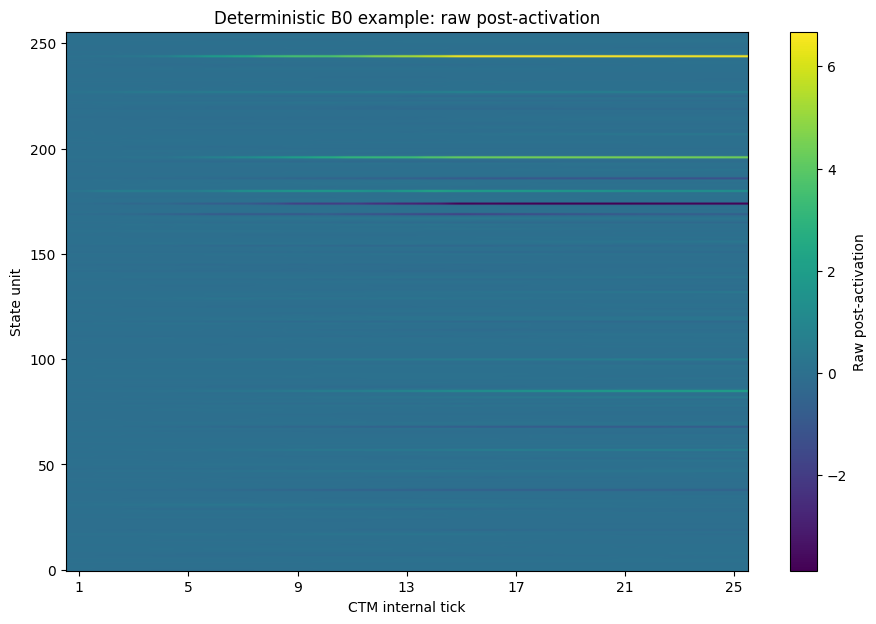

In [34]:
fig, ax = plt.subplots(
    figsize=(
        11,
        7,
    )
)


image = ax.imshow(
    raw_example.T,
    aspect="auto",
    origin="lower",
)


ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "State unit"
)

ax.set_title(
    "Deterministic B0 example: raw post-activation"
)


ax.set_xticks(
    np.arange(
        0,
        25,
        4,
    )
)

ax.set_xticklabels(
    np.arange(
        0,
        25,
        4,
    )
    + 1
)


fig.colorbar(
    image,
    ax=ax,
    label="Raw post-activation",
)


plt.show()

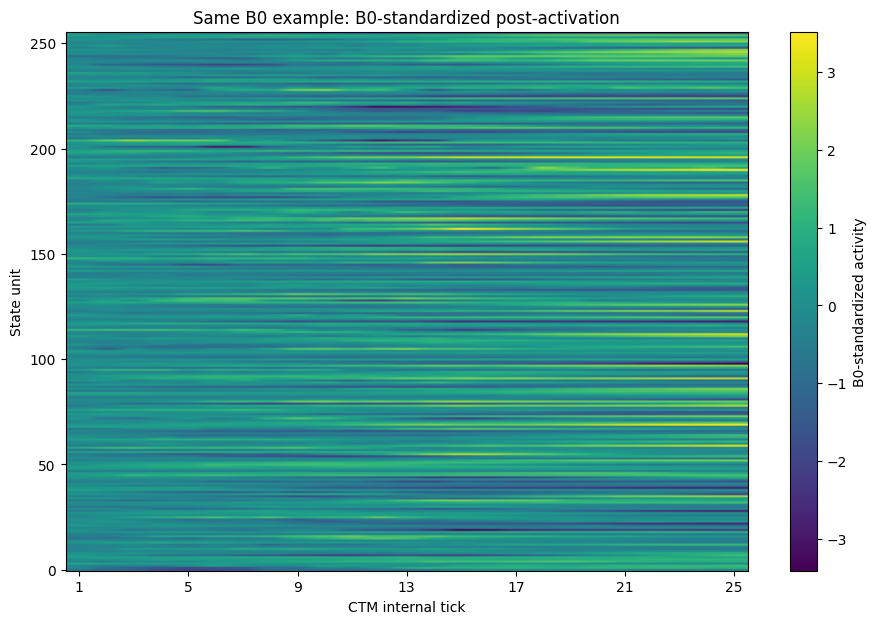

In [35]:
fig, ax = plt.subplots(
    figsize=(
        11,
        7,
    )
)


image = ax.imshow(
    standardized_example.T,
    aspect="auto",
    origin="lower",
)


ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "State unit"
)

ax.set_title(
    "Same B0 example: B0-standardized post-activation"
)


ax.set_xticks(
    np.arange(
        0,
        25,
        4,
    )
)

ax.set_xticklabels(
    np.arange(
        0,
        25,
        4,
    )
    + 1
)


fig.colorbar(
    image,
    ax=ax,
    label="B0-standardized activity",
)


plt.show()

#### 6.1 Observation

The raw B0 heatmap is dominated by a small number of high-amplitude state units, consistent with the large variation in unit-wise B0 standard deviations.

Using B0-derived standardization makes lower-amplitude units visible on a comparable scale while preserving the recording's internal-tick structure.

The same B0 transformation will be applied unchanged to B1-B4.

This standardization does not determine which units are dynamically informative. Variance is checked again for the specific Pearson representations below.

### 6.2 Pearson representations

Two complementary B0 neuron-neuron correlation representations are considered.

**A. Raw flattened activity**

Raw post-activation is flattened across recordings and internal ticks. Correlation therefore reflects both sustained between-recording differences and within-recording temporal co-variation.

**B. Within-recording temporally centered activity**

For each recording and state unit, the mean over the 25 internal ticks is subtracted:

$$
\tilde{x}_{r,t,j}
=
x_{r,t,j}
-
\frac{1}{25}
\sum_{t=1}^{25}
x_{r,t,j}.
$$

The centered activity is then flattened across recordings and ticks.

**Decision:** representation B is the primary grouping representation because it emphasizes shared changes during internal computation. Representation A is retained as a reference because sustained activity offsets removed by B may themselves contain object-related information.

Before computing Pearson correlations, unit variance is checked separately in both representations.

In [36]:
# ------------------------------------------------------------
# Representation A:
# raw B0 post-activation
# ------------------------------------------------------------

b0_raw_flat = (
    b0_raw
    .reshape(
        -1,
        b0_raw.shape[-1],
    )
)


# ------------------------------------------------------------
# Representation B:
# within-recording temporally centered activity
# ------------------------------------------------------------

b0_temporal_centered = (
    b0_raw
    -
    b0_raw.mean(
        axis=1,
        keepdims=True,
    )
)


b0_centered_flat = (
    b0_temporal_centered
    .reshape(
        -1,
        b0_temporal_centered.shape[-1],
    )
)


print(
    "Representation A:",
    b0_raw_flat.shape,
)

print(
    "Representation B:",
    b0_centered_flat.shape,
)


# ------------------------------------------------------------
# Unit variability in each representation
# ------------------------------------------------------------

raw_unit_std = (
    b0_raw_flat.std(
        axis=0,
        ddof=0,
    )
)


centered_unit_std = (
    b0_centered_flat.std(
        axis=0,
        ddof=0,
    )
)


print()
print("Raw representation")

print(
    "min std:",
    raw_unit_std.min(),
)

print(
    "median std:",
    np.median(
        raw_unit_std
    ),
)

print(
    "max std:",
    raw_unit_std.max(),
)

print(
    "zero-variance units:",
    np.sum(
        raw_unit_std == 0
    ),
)


print()
print("Temporally centered representation")

print(
    "min std:",
    centered_unit_std.min(),
)

print(
    "median std:",
    np.median(
        centered_unit_std
    ),
)

print(
    "max std:",
    centered_unit_std.max(),
)

print(
    "zero-variance units:",
    np.sum(
        centered_unit_std == 0
    ),
)


print()
print(
    "Smallest 10 centered-unit stds:"
)

print(
    np.sort(
        centered_unit_std
    )[
        :10
    ]
)

Representation A: (1600, 256)
Representation B: (1600, 256)

Raw representation
min std: 0.004006093842405055
median std: 0.03971141016564113
max std: 2.364662260233977
zero-variance units: 0

Temporally centered representation
min std: 0.0037102633214235524
median std: 0.02582517400562065
max std: 1.6357236425420811
zero-variance units: 0

Smallest 10 centered-unit stds:
[0.00371026 0.00595614 0.00632341 0.00637288 0.00637689 0.00879327
 0.00921738 0.00929726 0.00963574 0.00980616]


#### Pearson representation variability

All 256 state units retain non-zero variability after within-recording temporal centering.

The centered unit standard deviations range from approximately `0.0037` to `1.636`, so no unit is numerically degenerate for the primary Pearson representation.

**Decision:** retain all 256 units for both Pearson representations A and B. No variance-based exclusion is required at this stage.

In [37]:
# ------------------------------------------------------------
# Pearson correlation matrices
# ------------------------------------------------------------

corr_A_raw = np.corrcoef(
    b0_raw_flat,
    rowvar=False,
)


corr_B_centered = np.corrcoef(
    b0_centered_flat,
    rowvar=False,
)


print(
    "Correlation A shape:",
    corr_A_raw.shape,
)

print(
    "Correlation B shape:",
    corr_B_centered.shape,
)

print()

print(
    "All A correlations finite:",
    np.isfinite(
        corr_A_raw
    ).all(),
)

print(
    "All B correlations finite:",
    np.isfinite(
        corr_B_centered
    ).all(),
)


# ------------------------------------------------------------
# Off-diagonal correlation values only
# ------------------------------------------------------------

upper_triangle = np.triu_indices(
    corr_A_raw.shape[0],
    k=1,
)


corr_A_values = corr_A_raw[
    upper_triangle
]


corr_B_values = corr_B_centered[
    upper_triangle
]


def summarize_correlations(
    values,
    name,
):

    print()
    print(name)

    print(
        "min:",
        values.min(),
    )

    print(
        "25%:",
        np.quantile(
            values,
            0.25,
        ),
    )

    print(
        "median:",
        np.median(
            values
        ),
    )

    print(
        "75%:",
        np.quantile(
            values,
            0.75,
        ),
    )

    print(
        "max:",
        values.max(),
    )

    print(
        "r >= 0.6:",
        np.sum(
            values
            >=
            0.6
        ),
    )

    print(
        "r >= 0.7:",
        np.sum(
            values
            >=
            0.7
        ),
    )

    print(
        "r >= 0.8:",
        np.sum(
            values
            >=
            0.8
        ),
    )

    print(
        "r <= -0.6:",
        np.sum(
            values
            <=
            -0.6
        ),
    )


summarize_correlations(
    corr_A_values,
    "Representation A: raw flattened",
)


summarize_correlations(
    corr_B_values,
    "Representation B: within-recording centered",
)

Correlation A shape: (256, 256)
Correlation B shape: (256, 256)

All A correlations finite: True
All B correlations finite: True

Representation A: raw flattened
min: -0.9561673318496559
25%: -0.20441123306400233
median: 0.0006617900477363452
75%: 0.20630105610691485
max: 0.9880564620588468
r >= 0.6: 574
r >= 0.7: 157
r >= 0.8: 32
r <= -0.6: 549

Representation B: within-recording centered
min: -0.9099812620394038
25%: -0.19358709797522936
median: 0.0022803756612079958
75%: 0.1951019604462883
max: 0.9685135364403252
r >= 0.6: 431
r >= 0.7: 122
r >= 0.8: 21
r <= -0.6: 442


#### Correlation distribution observation

Both representations contain strong positive and negative correlations, while their median pairwise correlation is close to zero.

Within-recording temporal centering reduces the number of strongly correlated pairs. For example, pairs with $r \ge 0.7$ decrease from 157 in the raw representation to 122 in the centered representation.

This suggests that some raw correlation structure is associated with sustained recording-level offsets, while substantial temporal co-variation remains after those offsets are removed.

The $r=0.7$ threshold remains an exploratory analysis choice rather than a validated boundary.

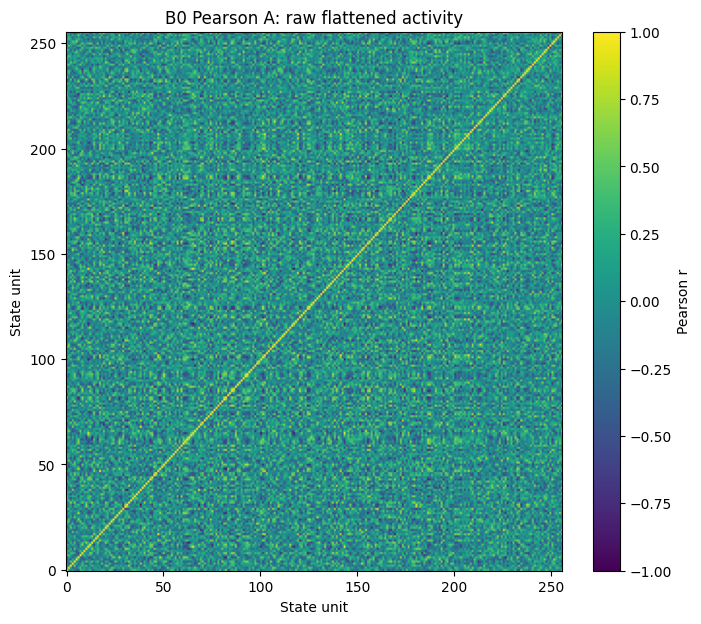

In [38]:
fig, ax = plt.subplots(
    figsize=(
        8,
        7,
    )
)


image = ax.imshow(
    corr_A_raw,
    vmin=-1,
    vmax=1,
    aspect="auto",
    origin="lower",
)


ax.set_xlabel(
    "State unit"
)

ax.set_ylabel(
    "State unit"
)

ax.set_title(
    "B0 Pearson A: raw flattened activity"
)


fig.colorbar(
    image,
    ax=ax,
    label="Pearson r",
)


plt.show()

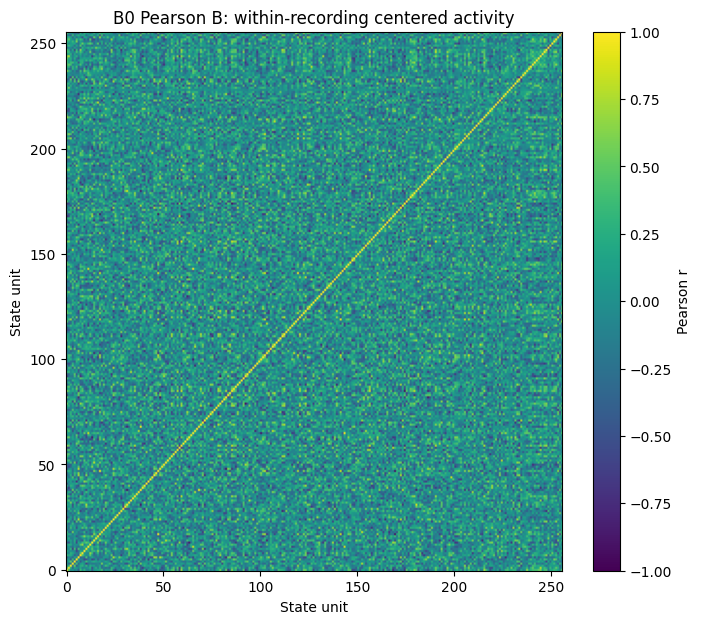

In [39]:
fig, ax = plt.subplots(
    figsize=(
        8,
        7,
    )
)


image = ax.imshow(
    corr_B_centered,
    vmin=-1,
    vmax=1,
    aspect="auto",
    origin="lower",
)


ax.set_xlabel(
    "State unit"
)

ax.set_ylabel(
    "State unit"
)

ax.set_title(
    "B0 Pearson B: within-recording centered activity"
)


fig.colorbar(
    image,
    ax=ax,
    label="Pearson r",
)


plt.show()

#### Correlation-matrix observation

In the original state-unit ordering, both correlation matrices show distributed positive and negative relationships rather than obvious large contiguous blocks.

Temporal centering reduces the number of strongly correlated pairs, but substantial correlation structure remains.

The absence of visible blocks in this ordering does not imply the absence of correlated groups because CTM state-unit indices have no reason to place related units next to one another. Group structure will only be assessed after a declared clustering procedure.

### 6.3 Common-tick-trend diagnostic

Representation B removes each unit's mean within each recording, but units may still share a stereotyped trajectory across internal ticks.

To diagnose this, we compute each unit's mean centered trajectory across the 64 B0 recordings and subtract it at every tick.

The resulting residual representation asks whether neuron-neuron correlations remain after removing the average tick-dependent trend.

This is a descriptive diagnostic only. Representation B remains the primary grouping representation, and residual correlations are not interpreted as evidence of direct interaction between state units.

In [40]:
# ------------------------------------------------------------
# Representation C:
# remove each unit's mean trajectory across B0 recordings
# from temporally centered activity
# ------------------------------------------------------------

b0_mean_tick_trajectory = (
    b0_temporal_centered.mean(
        axis=0,
        keepdims=True,
    )
)


b0_tick_residual = (
    b0_temporal_centered
    -
    b0_mean_tick_trajectory
)


b0_residual_flat = (
    b0_tick_residual.reshape(
        -1,
        b0_tick_residual.shape[-1],
    )
)


# ------------------------------------------------------------
# Variability after removing the common tick trajectory
# ------------------------------------------------------------

residual_unit_std = (
    b0_residual_flat.std(
        axis=0,
        ddof=0,
    )
)


print(
    "Representation C:",
    b0_residual_flat.shape,
)

print()

print(
    "Residual min std:",
    residual_unit_std.min(),
)

print(
    "Residual median std:",
    np.median(
        residual_unit_std
    ),
)

print(
    "Residual max std:",
    residual_unit_std.max(),
)

print(
    "Zero-variance units:",
    np.sum(
        residual_unit_std == 0
    ),
)


# ------------------------------------------------------------
# Pearson correlations after common-tick removal
# ------------------------------------------------------------

corr_C_residual = np.corrcoef(
    b0_residual_flat,
    rowvar=False,
)


print()
print(
    "All residual correlations finite:",
    np.isfinite(
        corr_C_residual
    ).all(),
)


corr_C_values = (
    corr_C_residual[
        upper_triangle
    ]
)


summarize_correlations(
    corr_C_values,
    "Representation C: common-tick residual",
)

Representation C: (1600, 256)

Residual min std: 0.0032771135971244743
Residual median std: 0.023971246893077596
Residual max std: 0.9769765818334983
Zero-variance units: 0

All residual correlations finite: True

Representation C: common-tick residual
min: -0.9179850406674925
25%: -0.21798315924686107
median: -0.001278350510936248
75%: 0.21734703807826064
max: 0.9661171922892965
r >= 0.6: 676
r >= 0.7: 194
r >= 0.8: 32
r <= -0.6: 676


#### Common-tick residual observation

Removing each unit's average tick trajectory does not eliminate strong correlations. The number of pairs with $r \ge 0.7$ increases from 122 in representation B to 194 in the residual diagnostic.

This suggests that the primary correlations are not explained solely by a shared average internal-tick trend.

Representation B remains the grouping representation; representation C is diagnostic only.

## 7. Candidate correlated groups

Groups are discovered from B0 representation B only.

We use complete-linkage hierarchical clustering with

$$
d_{ij} = 1 - r_{ij}.
$$

For the exploratory primary threshold $r = 0.7$, the clustering cut is therefore

$$
d = 0.3.
$$

Complete linkage is useful here because a cluster survives the cut only when its most dissimilar members remain sufficiently similar.

Negative correlations are preserved as large distances and are not converted using absolute correlation.

Clusters with at least three units are treated as candidate groups. Smaller clusters and singletons are retained in the summary rather than discarded.

In [41]:
from scipy.cluster.hierarchy import (
    linkage,
    fcluster,
)

from scipy.spatial.distance import squareform


PRIMARY_R = 0.7
PRIMARY_DISTANCE = 1.0 - PRIMARY_R
MIN_GROUP_SIZE = 3


# ------------------------------------------------------------
# Convert correlation to dissimilarity
# ------------------------------------------------------------

distance_B = (
    1.0
    -
    corr_B_centered
)


# Numerical symmetry cleanup
distance_B = (
    distance_B
    +
    distance_B.T
) / 2.0


np.fill_diagonal(
    distance_B,
    0.0,
)


print(
    "Distance range:",
    distance_B.min(),
    "to",
    distance_B.max(),
)


# ------------------------------------------------------------
# Complete-linkage clustering
# ------------------------------------------------------------

condensed_distance = squareform(
    distance_B,
    checks=True,
)


linkage_B = linkage(
    condensed_distance,
    method="complete",
)


cluster_labels_r07 = fcluster(
    linkage_B,
    t=PRIMARY_DISTANCE,
    criterion="distance",
)


# ------------------------------------------------------------
# Cluster summary
# ------------------------------------------------------------

cluster_sizes_r07 = (
    pd.Series(
        cluster_labels_r07
    )
    .value_counts()
    .sort_index()
)


candidate_cluster_ids_r07 = (
    cluster_sizes_r07[
        cluster_sizes_r07
        >=
        MIN_GROUP_SIZE
    ]
    .index
    .to_numpy()
)


print()
print(
    "Total clusters:",
    len(
        cluster_sizes_r07
    ),
)

print(
    "Candidate groups (>= 3 units):",
    len(
        candidate_cluster_ids_r07
    ),
)

print(
    "Size-2 clusters:",
    int(
        (
            cluster_sizes_r07
            ==
            2
        ).sum()
    ),
)

print(
    "Singletons:",
    int(
        (
            cluster_sizes_r07
            ==
            1
        ).sum()
    ),
)

print()

print(
    "Candidate group sizes:"
)

print(
    cluster_sizes_r07.loc[
        candidate_cluster_ids_r07
    ]
    .sort_values(
        ascending=False
    )
)

Distance range: 0.0 to 1.9099812620394037

Total clusters: 203
Candidate groups (>= 3 units): 7
Size-2 clusters: 38
Singletons: 158

Candidate group sizes:
114    4
45     3
87     3
131    3
169    3
175    3
181    3
Name: count, dtype: int64


### B0 candidate-group result

At the exploratory $r=0.7$ complete-linkage cut, seven candidate groups are found.

The groups are small: one contains four units and six contain three units. Most of the 256 state units remain singletons or pairs.

This suggests sparse local correlation structure rather than large correlated populations.

The threshold is exploratory, so group sensitivity at $r=0.6$ and $r=0.8$ and recording-bootstrap stability are evaluated before interpreting these groups further.

In [42]:
candidate_groups_r07 = {}


for cluster_id in (
    candidate_cluster_ids_r07
):

    units = np.where(
        cluster_labels_r07
        ==
        cluster_id
    )[0]

    candidate_groups_r07[
        int(
            cluster_id
        )
    ] = units


candidate_group_table = pd.DataFrame(
    [
        {
            "cluster_id": cluster_id,
            "n_units": len(
                units
            ),
            "state_units": units.tolist(),
        }

        for (
            cluster_id,
            units,
        ) in candidate_groups_r07.items()
    ]
).sort_values(
    [
        "n_units",
        "cluster_id",
    ],
    ascending=[
        False,
        True,
    ],
)


candidate_group_table

,cluster_id,n_units,state_units
2,114,4,"[102, 119, 141, 207]"
0,45,3,"[6, 24, 48]"
1,87,3,"[63, 160, 231]"
3,131,3,"[11, 65, 143]"
4,169,3,"[38, 68, 173]"
5,175,3,"[69, 78, 120]"
6,181,3,"[156, 190, 246]"


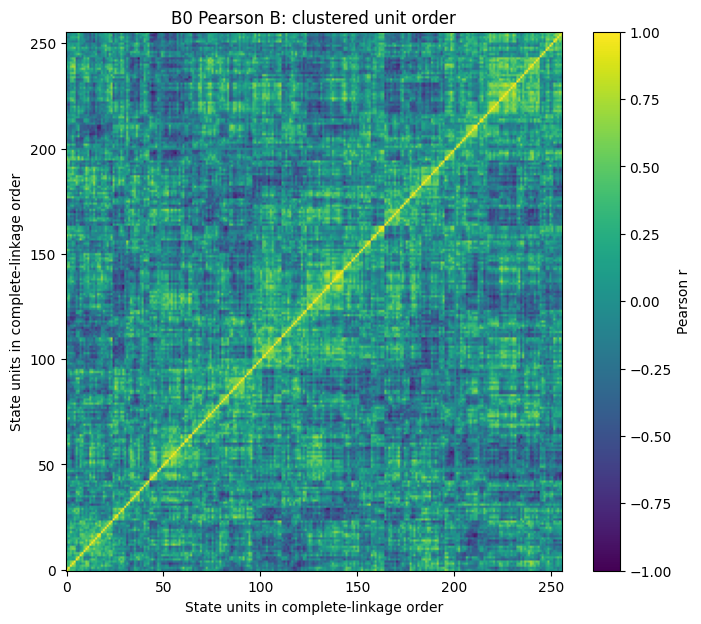

In [43]:
from scipy.cluster.hierarchy import (
    leaves_list,
)


leaf_order = leaves_list(
    linkage_B
)


corr_B_clustered = (
    corr_B_centered[
        np.ix_(
            leaf_order,
            leaf_order,
        )
    ]
)


fig, ax = plt.subplots(
    figsize=(
        8,
        7,
    )
)


image = ax.imshow(
    corr_B_clustered,
    vmin=-1,
    vmax=1,
    aspect="auto",
    origin="lower",
)


ax.set_xlabel(
    "State units in complete-linkage order"
)

ax.set_ylabel(
    "State units in complete-linkage order"
)

ax.set_title(
    "B0 Pearson B: clustered unit order"
)


fig.colorbar(
    image,
    ax=ax,
    label="Pearson r",
)


plt.show()

In [44]:
def summarize_cluster_cut(
    r_threshold,
):

    distance_threshold = (
        1.0
        -
        r_threshold
    )

    labels = fcluster(
        linkage_B,
        t=distance_threshold,
        criterion="distance",
    )

    sizes = (
        pd.Series(
            labels
        )
        .value_counts()
    )

    candidate_sizes = sizes[
        sizes
        >=
        MIN_GROUP_SIZE
    ]


    return {
        "r_threshold": (
            r_threshold
        ),

        "total_clusters": int(
            len(
                sizes
            )
        ),

        "candidate_groups": int(
            len(
                candidate_sizes
            )
        ),

        "units_in_candidate_groups": int(
            candidate_sizes.sum()
        ),

        "largest_group": int(
            sizes.max()
        ),

        "size_2_clusters": int(
            (
                sizes
                ==
                2
            ).sum()
        ),

        "singletons": int(
            (
                sizes
                ==
                1
            ).sum()
        ),
    }


threshold_sensitivity = pd.DataFrame(
    [
        summarize_cluster_cut(
            0.6
        ),

        summarize_cluster_cut(
            0.7
        ),

        summarize_cluster_cut(
            0.8
        ),
    ]
)


threshold_sensitivity

,r_threshold,total_clusters,candidate_groups,units_in_candidate_groups,largest_group,size_2_clusters,singletons
0,0.6,161,19,64,5,50,92
1,0.7,203,7,22,4,38,158
2,0.8,244,1,3,3,10,233


In [45]:
from itertools import combinations


N_BOOTSTRAPS = 100
BOOTSTRAP_SEED = 20260929


rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


def stratified_recording_bootstrap(
    labels,
    rng,
):

    sampled_indices = []

    for class_id in np.unique(
        labels
    ):

        class_indices = np.where(
            labels
            ==
            class_id
        )[0]

        sampled = rng.choice(
            class_indices,
            size=len(
                class_indices
            ),
            replace=True,
        )

        sampled_indices.extend(
            sampled.tolist()
        )


    return np.asarray(
        sampled_indices,
        dtype=int,
    )


candidate_unit_ids = np.concatenate(
    list(
        candidate_groups_r07.values()
    )
)


unit_position = {
    int(
        unit
    ): position

    for (
        position,
        unit,
    ) in enumerate(
        candidate_unit_ids
    )
}


coassignment_count = np.zeros(
    (
        len(
            candidate_unit_ids
        ),
        len(
            candidate_unit_ids
        ),
    ),
    dtype=int,
)


for bootstrap_idx in range(
    N_BOOTSTRAPS
):

    sampled_recordings = (
        stratified_recording_bootstrap(
            b0_targets,
            rng,
        )
    )


    bootstrap_activity = (
        b0_raw[
            sampled_recordings
        ]
    )


    bootstrap_centered = (
        bootstrap_activity
        -
        bootstrap_activity.mean(
            axis=1,
            keepdims=True,
        )
    )


    bootstrap_flat = (
        bootstrap_centered.reshape(
            -1,
            bootstrap_centered.shape[-1],
        )
    )


    bootstrap_corr = np.corrcoef(
        bootstrap_flat,
        rowvar=False,
    )


    bootstrap_distance = (
        1.0
        -
        bootstrap_corr
    )


    bootstrap_distance = (
        bootstrap_distance
        +
        bootstrap_distance.T
    ) / 2.0


    np.fill_diagonal(
        bootstrap_distance,
        0.0,
    )


    bootstrap_linkage = linkage(
        squareform(
            bootstrap_distance,
            checks=True,
        ),
        method="complete",
    )


    bootstrap_labels = fcluster(
        bootstrap_linkage,
        t=PRIMARY_DISTANCE,
        criterion="distance",
    )


    for (
        unit_a,
        unit_b,
    ) in combinations(
        candidate_unit_ids,
        2,
    ):

        if (
            bootstrap_labels[
                unit_a
            ]
            ==
            bootstrap_labels[
                unit_b
            ]
        ):

            i = unit_position[
                int(
                    unit_a
                )
            ]

            j = unit_position[
                int(
                    unit_b
                )
            ]

            coassignment_count[
                i,
                j
            ] += 1

            coassignment_count[
                j,
                i
            ] += 1


coassignment_fraction = (
    coassignment_count
    /
    N_BOOTSTRAPS
)


np.fill_diagonal(
    coassignment_fraction,
    1.0,
)

In [46]:
stability_rows = []


for (
    cluster_id,
    units,
) in candidate_groups_r07.items():

    pair_stabilities = []


    for (
        unit_a,
        unit_b,
    ) in combinations(
        units,
        2,
    ):

        i = unit_position[
            int(
                unit_a
            )
        ]

        j = unit_position[
            int(
                unit_b
            )
        ]


        pair_stabilities.append(
            coassignment_fraction[
                i,
                j
            ]
        )


    stability_rows.append(
        {
            "cluster_id": (
                cluster_id
            ),

            "n_units": len(
                units
            ),

            "mean_pair_coassignment": (
                np.mean(
                    pair_stabilities
                )
            ),

            "minimum_pair_coassignment": (
                np.min(
                    pair_stabilities
                )
            ),

            "maximum_pair_coassignment": (
                np.max(
                    pair_stabilities
                )
            ),
        }
    )


group_stability = pd.DataFrame(
    stability_rows
).sort_values(
    "mean_pair_coassignment",
    ascending=False,
)


group_stability

,cluster_id,n_units,mean_pair_coassignment,minimum_pair_coassignment,maximum_pair_coassignment
3,131,3,1.000000,1.00,1.00
4,169,3,1.000000,1.00,1.00
5,175,3,0.986667,0.98,1.00
1,87,3,0.726667,0.64,0.82
2,114,4,0.640000,0.46,1.00
0,45,3,0.586667,0.38,1.00
6,181,3,0.520000,0.28,0.67


### B0 group-discovery summary

The exploratory $r=0.7$ complete-linkage analysis identifies seven small candidate groups containing 22 of 256 state units.

Reordering the correlation matrix by complete linkage reveals localized correlated structure that is not visible in the original state-unit ordering.

The result is threshold-sensitive:

- $r=0.6$: 19 candidate groups,
- $r=0.7$: 7 candidate groups,
- $r=0.8$: 1 candidate group.

Bootstrap resampling of whole B0 recordings also shows heterogeneous stability. Some groups are reproduced almost perfectly across resamples, whereas others are substantially less stable.

**Decision:** retain all seven $r=0.7$ groups as the frozen exploratory B0 discovery result. Bootstrap stability is reported as a continuous property of each group rather than used to redefine membership.

B1-B4 will not be used to change the threshold or group membership.

In [47]:
from pathlib import Path
import json


POPULATION_DIR = Path(
    "results/"
    "rtg_internal_dynamics_ddm/"
    "p1_population_analysis"
)

POPULATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


candidate_group_table.to_csv(
    POPULATION_DIR
    / "b0_candidate_groups_r07.csv",
    index=False,
)


threshold_sensitivity.to_csv(
    POPULATION_DIR
    / "b0_threshold_sensitivity.csv",
    index=False,
)


group_stability.to_csv(
    POPULATION_DIR
    / "b0_bootstrap_group_stability.csv",
    index=False,
)


frozen_groups = {
    str(
        cluster_id
    ): units.tolist()

    for (
        cluster_id,
        units,
    ) in candidate_groups_r07.items()
}


with (
    POPULATION_DIR
    / "b0_frozen_groups_r07.json"
).open(
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        frozen_groups,
        f,
        indent=2,
    )


grouping_settings = {
    "participant": 1,

    "discovery_domain": "B0",

    "primary_representation": (
        "within-recording temporally centered post-activation"
    ),

    "correlation": "Pearson",

    "distance": "1 - r",

    "linkage": "complete",

    "primary_r_threshold": 0.7,

    "sensitivity_thresholds": [
        0.6,
        0.8,
    ],

    "candidate_min_units": 3,

    "absolute_correlation_used": False,

    "bootstrap_resamples": 100,

    "bootstrap_seed": 20260929,

    "bootstrap_unit": "whole recording",

    "bootstrap_stratified_by": "class_label",

    "group_membership_filtered_by_bootstrap": False,
}


with (
    POPULATION_DIR
    / "b0_grouping_settings.json"
).open(
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        grouping_settings,
        f,
        indent=2,
    )


print(
    "Frozen B0 candidate groups:",
    len(
        candidate_groups_r07
    ),
)

print(
    "Saved to:",
    POPULATION_DIR.resolve(),
)

Frozen B0 candidate groups: 7
Saved to: /Users/arthu/Desktop/CTM_Res-Pro/models/ctm/results/rtg_internal_dynamics_ddm/p1_population_analysis


## 8. Frozen-group evaluation on B1-B4

The B0 discovery result is now frozen.

B1-B4 is used only to evaluate whether the same state-unit relationships persist under transfer.

For B1-B4 we compute the same three descriptive correlation representations:

- A: raw flattened activity,
- B: within-recording temporally centered activity,
- C: common-tick residual diagnostic.

B1-B4 centering is evaluation-only. It does not redefine groups, thresholds, unit membership, or ordering.

The primary transfer comparison uses the seven frozen B0 groups and representation B.

In [48]:
# ------------------------------------------------------------
# B1-B4 representation A:
# raw activity
# ------------------------------------------------------------

b1_b4_raw_flat = (
    b1_b4_raw.reshape(
        -1,
        b1_b4_raw.shape[-1],
    )
)


# ------------------------------------------------------------
# B1-B4 representation B:
# within-recording temporal centering
# ------------------------------------------------------------

b1_b4_temporal_centered = (
    b1_b4_raw
    -
    b1_b4_raw.mean(
        axis=1,
        keepdims=True,
    )
)


b1_b4_centered_flat = (
    b1_b4_temporal_centered.reshape(
        -1,
        b1_b4_temporal_centered.shape[-1],
    )
)


# ------------------------------------------------------------
# B1-B4 representation C:
# evaluation-only common-tick residual
# ------------------------------------------------------------

b1_b4_mean_tick_trajectory = (
    b1_b4_temporal_centered.mean(
        axis=0,
        keepdims=True,
    )
)


b1_b4_tick_residual = (
    b1_b4_temporal_centered
    -
    b1_b4_mean_tick_trajectory
)


b1_b4_residual_flat = (
    b1_b4_tick_residual.reshape(
        -1,
        b1_b4_tick_residual.shape[-1],
    )
)


# ------------------------------------------------------------
# Variance checks
# ------------------------------------------------------------

for (
    name,
    representation,
) in [
    (
        "A raw",
        b1_b4_raw_flat,
    ),
    (
        "B centered",
        b1_b4_centered_flat,
    ),
    (
        "C residual",
        b1_b4_residual_flat,
    ),
]:

    unit_std = representation.std(
        axis=0,
        ddof=0,
    )

    print()
    print(name)

    print(
        "min std:",
        unit_std.min(),
    )

    print(
        "median std:",
        np.median(
            unit_std
        ),
    )

    print(
        "max std:",
        unit_std.max(),
    )

    print(
        "zero-variance units:",
        np.sum(
            unit_std == 0
        ),
    )


# ------------------------------------------------------------
# Correlation matrices
# ------------------------------------------------------------

corr_b1_A_raw = np.corrcoef(
    b1_b4_raw_flat,
    rowvar=False,
)


corr_b1_B_centered = np.corrcoef(
    b1_b4_centered_flat,
    rowvar=False,
)


corr_b1_C_residual = np.corrcoef(
    b1_b4_residual_flat,
    rowvar=False,
)


assert np.isfinite(
    corr_b1_A_raw
).all()

assert np.isfinite(
    corr_b1_B_centered
).all()

assert np.isfinite(
    corr_b1_C_residual
).all()


print()
print(
    "All B1-B4 correlation matrices finite: PASSED"
)


A raw
min std: 0.004896068232810658
median std: 0.039223449176367005
max std: 1.952202179903294
zero-variance units: 0

B centered
min std: 0.0043255301522127495
median std: 0.027161840212269688
max std: 1.4302810100778434
zero-variance units: 0

C residual
min std: 0.0038793991261394413
median std: 0.0234852299977201
max std: 0.8063903374900447
zero-variance units: 0

All B1-B4 correlation matrices finite: PASSED


In [49]:
corr_b1_A_values = (
    corr_b1_A_raw[
        upper_triangle
    ]
)


corr_b1_B_values = (
    corr_b1_B_centered[
        upper_triangle
    ]
)


corr_b1_C_values = (
    corr_b1_C_residual[
        upper_triangle
    ]
)


summarize_correlations(
    corr_b1_A_values,
    "B1-B4 A: raw flattened",
)


summarize_correlations(
    corr_b1_B_values,
    "B1-B4 B: within-recording centered",
)


summarize_correlations(
    corr_b1_C_values,
    "B1-B4 C: common-tick residual",
)


B1-B4 A: raw flattened
min: -0.940832303463882
25%: -0.20825041517480675
median: 0.0012338961029200214
75%: 0.20807949411754673
max: 0.9796683523776409
r >= 0.6: 529
r >= 0.7: 160
r >= 0.8: 31
r <= -0.6: 521

B1-B4 B: within-recording centered
min: -0.9255926458550923
25%: -0.20982830330510283
median: 0.001041624370845528
75%: 0.21175200555509574
max: 0.9620879038384484
r >= 0.6: 581
r >= 0.7: 175
r >= 0.8: 24
r <= -0.6: 546

B1-B4 C: common-tick residual
min: -0.9324365250639778
25%: -0.2149270350684633
median: -0.0017575834250830194
75%: 0.2117709509095255
max: 0.9530967462408363
r >= 0.6: 625
r >= 0.7: 181
r >= 0.8: 33
r <= -0.6: 648


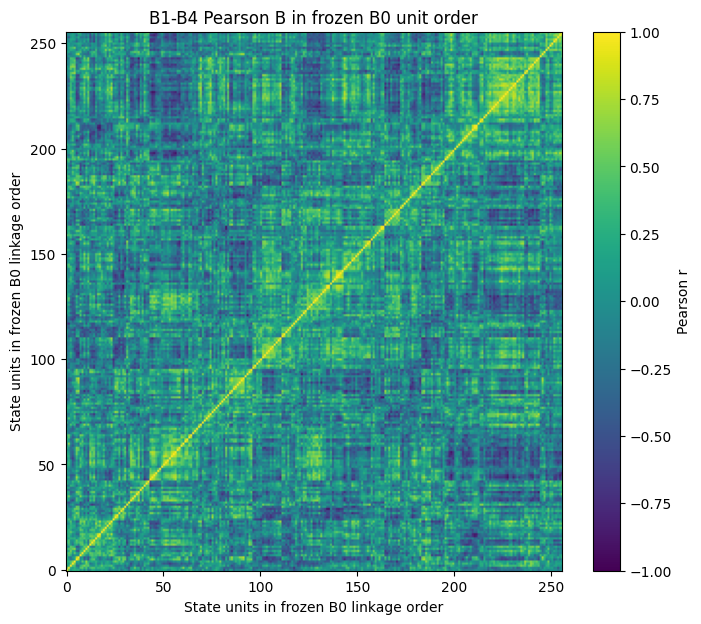

In [50]:
corr_b1_B_frozen_order = (
    corr_b1_B_centered[
        np.ix_(
            leaf_order,
            leaf_order,
        )
    ]
)


fig, ax = plt.subplots(
    figsize=(
        8,
        7,
    )
)


image = ax.imshow(
    corr_b1_B_frozen_order,
    vmin=-1,
    vmax=1,
    aspect="auto",
    origin="lower",
)


ax.set_xlabel(
    "State units in frozen B0 linkage order"
)

ax.set_ylabel(
    "State units in frozen B0 linkage order"
)

ax.set_title(
    "B1-B4 Pearson B in frozen B0 unit order"
)


fig.colorbar(
    image,
    ax=ax,
    label="Pearson r",
)


plt.show()

In [51]:
def within_group_correlations(
    correlation_matrix,
    units,
):

    units = np.asarray(
        units,
        dtype=int,
    )

    submatrix = (
        correlation_matrix[
            np.ix_(
                units,
                units,
            )
        ]
    )


    pair_indices = np.triu_indices(
        len(
            units
        ),
        k=1,
    )


    return submatrix[
        pair_indices
    ]


transfer_rows = []


for (
    cluster_id,
    units,
) in candidate_groups_r07.items():

    b0_pairs = (
        within_group_correlations(
            corr_B_centered,
            units,
        )
    )


    b1_pairs = (
        within_group_correlations(
            corr_b1_B_centered,
            units,
        )
    )


    stability_row = (
        group_stability.loc[
            group_stability[
                "cluster_id"
            ]
            ==
            cluster_id
        ]
        .iloc[
            0
        ]
    )


    transfer_rows.append(
        {
            "cluster_id": int(
                cluster_id
            ),

            "n_units": int(
                len(
                    units
                )
            ),

            "state_units": (
                units.tolist()
            ),

            "b0_mean_r": float(
                b0_pairs.mean()
            ),

            "b0_min_r": float(
                b0_pairs.min()
            ),

            "b1_b4_mean_r": float(
                b1_pairs.mean()
            ),

            "b1_b4_min_r": float(
                b1_pairs.min()
            ),

            "change_mean_r": float(
                b1_pairs.mean()
                -
                b0_pairs.mean()
            ),

            "b0_bootstrap_mean_coassignment": float(
                stability_row[
                    "mean_pair_coassignment"
                ]
            ),
        }
    )


frozen_group_transfer = (
    pd.DataFrame(
        transfer_rows
    )
    .sort_values(
        "b0_bootstrap_mean_coassignment",
        ascending=False,
    )
)


frozen_group_transfer

,cluster_id,n_units,state_units,b0_mean_r,b0_min_r,b1_b4_mean_r,b1_b4_min_r,change_mean_r,b0_bootstrap_mean_coassignment
3,131,3,"[11, 65, 143]",0.887687,0.829649,0.705880,0.559050,-0.181807,1.000000
4,169,3,"[38, 68, 173]",0.824305,0.754071,0.844802,0.773636,0.020497,1.000000
5,175,3,"[69, 78, 120]",0.782119,0.761898,0.692875,0.573294,-0.089244,0.986667
1,87,3,"[63, 160, 231]",0.713712,0.710024,0.722064,0.692641,0.008352,0.726667
2,114,4,"[102, 119, 141, 207]",0.819938,0.704652,0.809282,0.683003,-0.010656,0.640000
0,45,3,"[6, 24, 48]",0.766808,0.757569,0.823771,0.777690,0.056963,0.586667
6,181,3,"[156, 190, 246]",0.783319,0.701866,0.769826,0.672142,-0.013493,0.520000


In [52]:
np.savez_compressed(
    POPULATION_DIR
    / "b1_b4_correlation_matrices.npz",

    raw=corr_b1_A_raw,

    within_recording_centered=(
        corr_b1_B_centered
    ),

    common_tick_residual=(
        corr_b1_C_residual
    ),
)


frozen_group_transfer.to_csv(
    POPULATION_DIR
    / "frozen_group_transfer_correlations.csv",
    index=False,
)


print(
    "Transfer correlation results saved."
)

Transfer correlation results saved.


### Frozen-group transfer result

The seven B0-derived candidate groups retain substantial positive correlation in B1-B4 without reclustering or changing membership.

Group-level transfer is heterogeneous. Some groups remain nearly unchanged or become more correlated, while others weaken, especially groups 131 and 175.

Importantly, B0 bootstrap stability and B1-B4 transfer persistence are not the same quantity. A group can be sensitive to B0 resampling yet still show strong correlation in the transfer domain.

These results support reproducible correlated motifs across B0 and B1-B4, but do not imply that the groups have the same functional role or object selectivity in both domains.

In [53]:
# ------------------------------------------------------------
# Build group activity from B0-standardized ORIGINAL activity
# ------------------------------------------------------------

group_ids = sorted(
    candidate_groups_r07
)


def build_group_activity(
    standardized_activity,
    groups,
):

    traces = []

    for cluster_id in sorted(
        groups
    ):

        units = groups[
            cluster_id
        ]

        traces.append(
            standardized_activity[
                :,
                :,
                units,
            ].mean(
                axis=2
            )
        )

    return np.stack(
        traces,
        axis=2,
    )


b0_group_activity = build_group_activity(
    b0_standardized,
    candidate_groups_r07,
)


b1_b4_group_activity = build_group_activity(
    b1_b4_standardized,
    candidate_groups_r07,
)


print(
    "B0 group activity:",
    b0_group_activity.shape,
)

print(
    "B1-B4 group activity:",
    b1_b4_group_activity.shape,
)

B0 group activity: (64, 25, 7)
B1-B4 group activity: (128, 25, 7)


## 9. Group activity, object identity, and certainty

Group membership remains frozen from B0.

Each group's activity is defined as the mean of its member units' **B0-standardized original post-activations**.

Temporal centering was useful for discovering correlated units, but it is not applied to the group readout because sustained activity differences may contain object-related information.

The same B0-derived standardization is used for B1-B4.

In [54]:
def plot_group_object_trajectories(
    group_activity,
    metadata,
    domain_name,
):

    ticks = np.arange(
        1,
        group_activity.shape[1]
        + 1,
    )

    labels = metadata[
        "class_label"
    ].to_numpy()


    for group_position, cluster_id in enumerate(
        group_ids
    ):

        fig, ax = plt.subplots(
            figsize=(
                10,
                5,
            )
        )


        for class_id in sorted(
            np.unique(
                labels
            )
        ):

            class_mask = (
                labels
                ==
                class_id
            )

            trajectories = (
                group_activity[
                    class_mask,
                    :,
                    group_position,
                ]
            )

            mean_trace = trajectories.mean(
                axis=0
            )

            std_trace = trajectories.std(
                axis=0,
                ddof=0,
            )


            line = ax.plot(
                ticks,
                mean_trace,
                label=(
                    f"class {class_id} "
                    f"(n={class_mask.sum()})"
                ),
            )[0]


            ax.fill_between(
                ticks,
                mean_trace
                -
                std_trace,
                mean_trace
                +
                std_trace,
                alpha=0.12,
                color=line.get_color(),
            )


        ax.set_xlabel(
            "CTM internal tick"
        )

        ax.set_ylabel(
            "Mean B0-standardized group activity"
        )

        ax.set_title(
            f"{domain_name}: frozen group {cluster_id}\n"
            "object-conditioned activity (mean ± 1 SD)"
        )

        ax.legend(
            bbox_to_anchor=(
                1.02,
                1,
            ),
            loc="upper left",
        )

        plt.show()

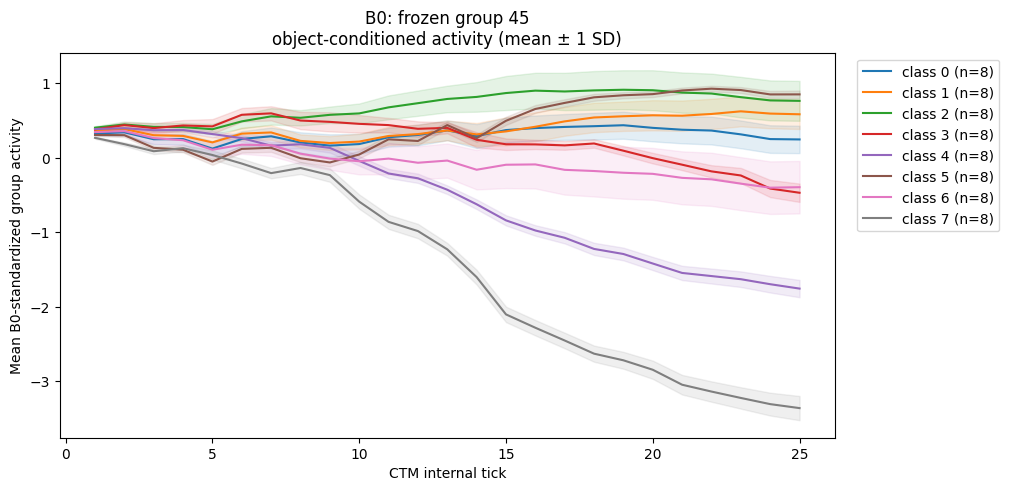

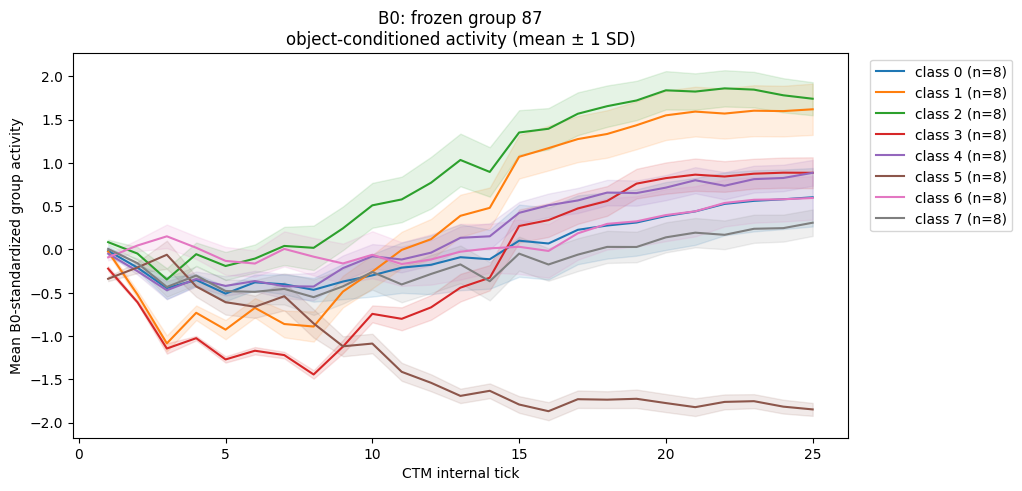

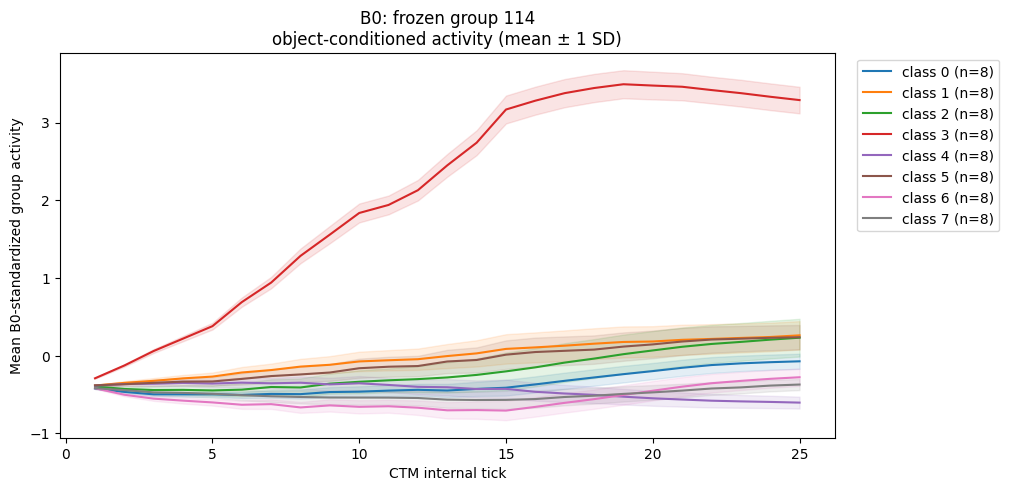

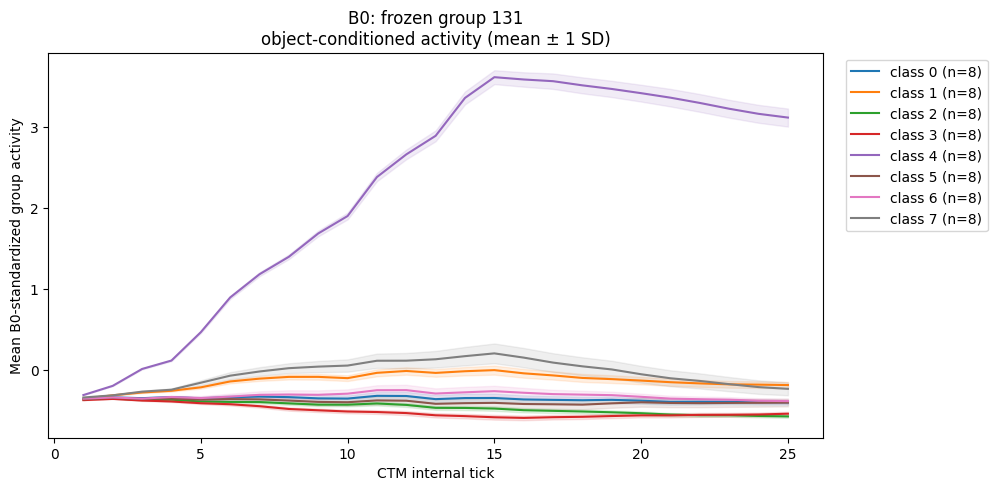

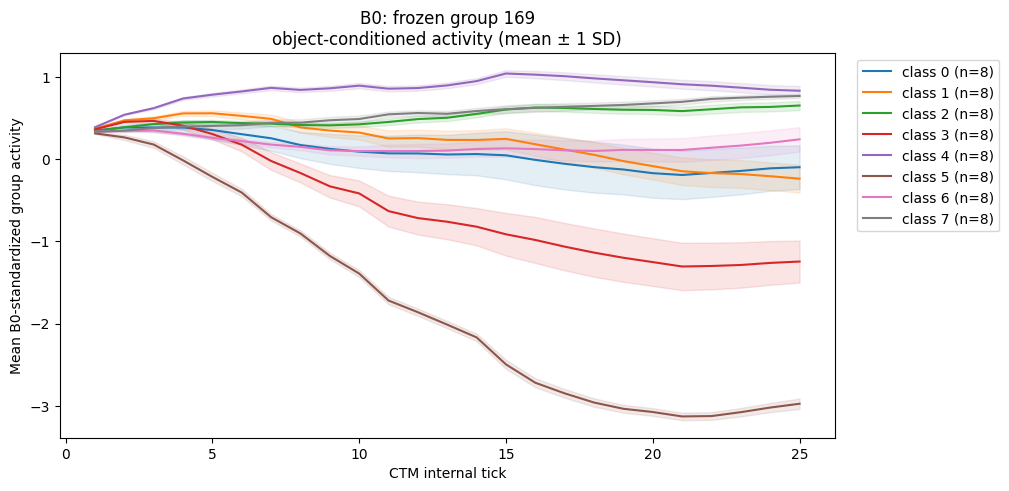

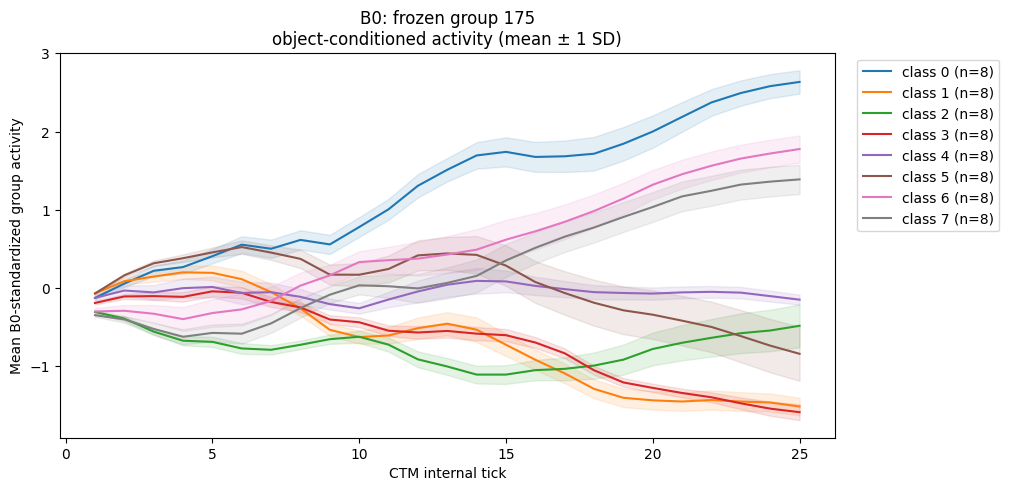

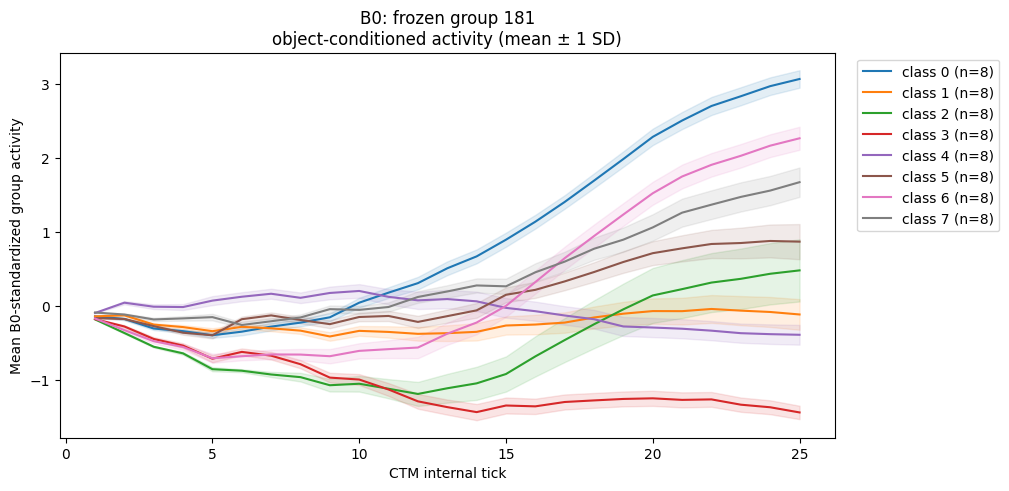

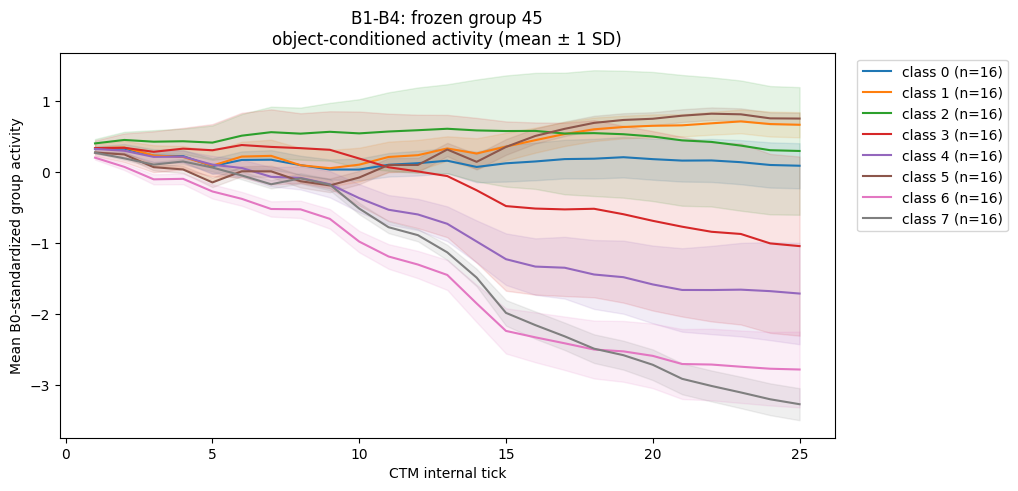

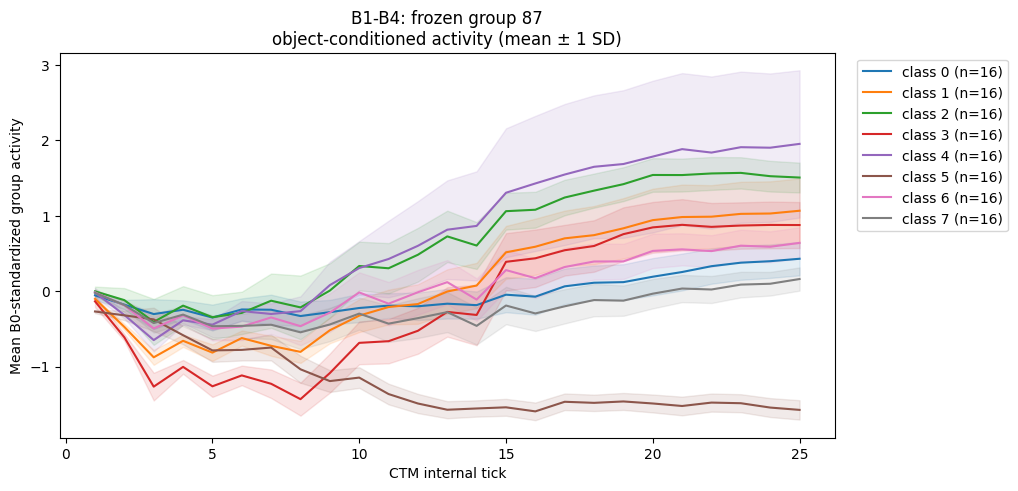

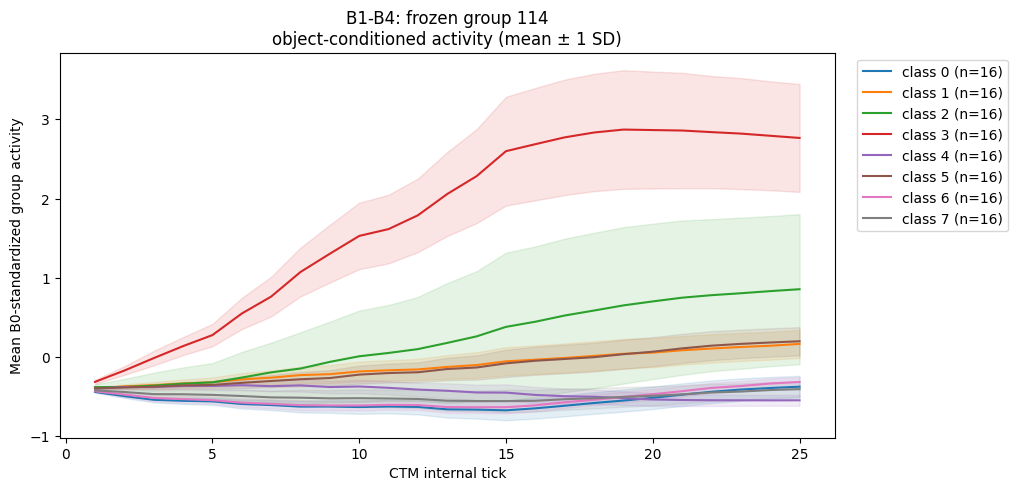

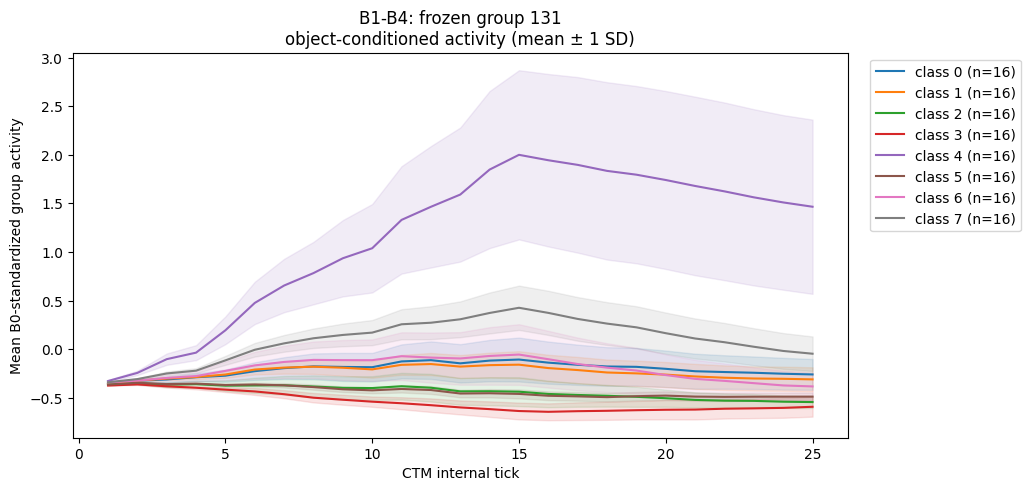

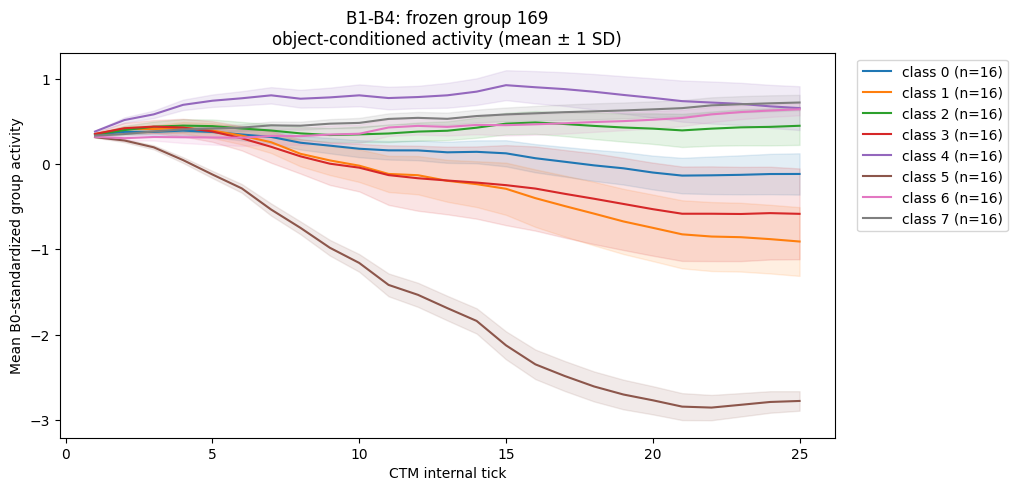

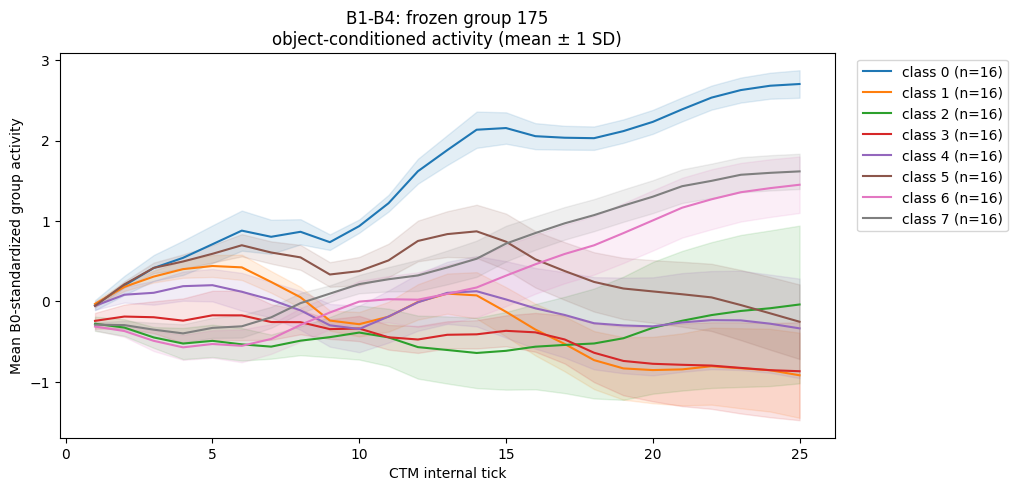

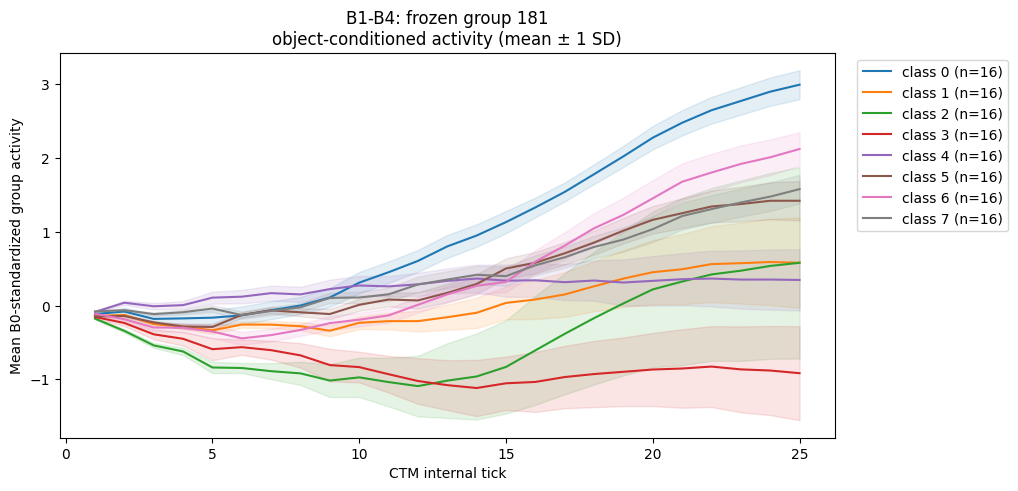

In [55]:
plot_group_object_trajectories(
    b0_group_activity,
    b0_metadata,
    "B0",
)


plot_group_object_trajectories(
    b1_b4_group_activity,
    b1_b4_metadata,
    "B1-B4",
)

In [56]:
def eta_squared(
    values,
    labels,
):

    values = np.asarray(
        values,
        dtype=float,
    )

    labels = np.asarray(
        labels,
    )

    grand_mean = values.mean()

    total_ss = np.sum(
        (
            values
            -
            grand_mean
        )
        ** 2
    )


    if total_ss == 0:

        return np.nan


    between_ss = 0.0


    for class_id in np.unique(
        labels
    ):

        class_values = values[
            labels
            ==
            class_id
        ]

        between_ss += (
            len(
                class_values
            )
            *
            (
                class_values.mean()
                -
                grand_mean
            )
            ** 2
        )


    return (
        between_ss
        /
        total_ss
    )

In [57]:
object_effect_rows = []


for (
    domain,
    activity,
    metadata,
) in [
    (
        "B0",
        b0_group_activity,
        b0_metadata,
    ),
    (
        "B1-B4",
        b1_b4_group_activity,
        b1_b4_metadata,
    ),
]:

    labels = metadata[
        "class_label"
    ].to_numpy()


    for group_position, cluster_id in enumerate(
        group_ids
    ):

        for tick in range(
            activity.shape[1]
        ):

            effect = eta_squared(
                activity[
                    :,
                    tick,
                    group_position,
                ],
                labels,
            )


            object_effect_rows.append(
                {
                    "domain": domain,
                    "cluster_id": cluster_id,
                    "tick": tick + 1,
                    "eta_squared": effect,
                }
            )


object_effects = pd.DataFrame(
    object_effect_rows
)


object_effect_summary = (
    object_effects
    .groupby(
        [
            "domain",
            "cluster_id",
        ]
    )
    .agg(
        median_eta_squared=(
            "eta_squared",
            "median",
        ),
        maximum_eta_squared=(
            "eta_squared",
            "max",
        ),
    )
    .reset_index()
)


object_effect_summary

,domain,cluster_id,median_eta_squared,maximum_eta_squared
0,B0,45,0.954401,0.978537
1,B0,87,0.925099,0.957137
2,B0,114,0.980460,0.983780
3,B0,131,0.996940,0.997711
4,B0,169,0.979126,0.983421
5,B0,175,0.949716,0.982760
6,B0,181,0.971810,0.981951
7,B1-B4,45,0.752175,0.837348
8,B1-B4,87,0.800979,0.849195
9,B1-B4,114,0.852618,0.862415


In [58]:
def safe_correlation(
    x,
    y,
):

    x = np.asarray(
        x,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )


    if (
        len(
            x
        )
        < 3
        or
        x.std() <= 1e-12
        or
        y.std() <= 1e-12
    ):

        return np.nan


    return np.corrcoef(
        x,
        y,
    )[
        0,
        1
    ]

In [60]:
# ------------------------------------------------------------
# Load saved certainty traces from the verified foundation
# ------------------------------------------------------------

with np.load(
    FOUNDATION_DIR
    / "p1_b0_activity.npz"
) as data:

    b0_certainty = data[
        "certainty"
    ].astype(
        np.float64
    )


with np.load(
    FOUNDATION_DIR
    / "p1_b1_b4_activity.npz"
) as data:

    b1_b4_certainty = data[
        "certainty"
    ].astype(
        np.float64
    )


print(
    "B0 certainty:",
    b0_certainty.shape,
)

print(
    "B1-B4 certainty:",
    b1_b4_certainty.shape,
)

print(
    "All certainty values finite:",
    (
        np.isfinite(
            b0_certainty
        ).all()
        and
        np.isfinite(
            b1_b4_certainty
        ).all()
    ),
)


assert b0_certainty.shape == (
    64,
    25,
)

assert b1_b4_certainty.shape == (
    128,
    25,
)

B0 certainty: (64, 25)
B1-B4 certainty: (128, 25)
All certainty values finite: True


In [61]:
certainty_within_rows = []


for (
    domain,
    activity,
    certainty,
    metadata,
) in [
    (
        "B0",
        b0_group_activity,
        b0_certainty,
        b0_metadata,
    ),
    (
        "B1-B4",
        b1_b4_group_activity,
        b1_b4_certainty,
        b1_b4_metadata,
    ),
]:

    for group_position, cluster_id in enumerate(
        group_ids
    ):

        for recording_idx in range(
            len(
                metadata
            )
        ):

            r_value = safe_correlation(
                activity[
                    recording_idx,
                    :,
                    group_position,
                ],
                certainty[
                    recording_idx,
                    :,
                ],
            )


            certainty_within_rows.append(
                {
                    "domain": domain,
                    "cluster_id": cluster_id,
                    "recording": recording_idx,
                    "correct": bool(
                        metadata.loc[
                            recording_idx,
                            "correct",
                        ]
                    ),
                    "r_activity_certainty": (
                        r_value
                    ),
                }
            )


certainty_within = pd.DataFrame(
    certainty_within_rows
)


certainty_within_summary = (
    certainty_within
    .groupby(
        [
            "domain",
            "cluster_id",
            "correct",
        ]
    )
    .agg(
        n_recordings=(
            "recording",
            "size",
        ),
        median_r=(
            "r_activity_certainty",
            "median",
        ),
    )
    .reset_index()
)


certainty_within_summary

,domain,cluster_id,correct,n_recordings,median_r
0,B0,45,True,64,-0.596857
1,B0,87,True,64,0.941908
2,B0,114,True,64,0.872314
3,B0,131,True,64,-0.436588
4,B0,169,True,64,-0.767526
5,B0,175,True,64,0.021065
6,B0,181,True,64,0.861471
7,B1-B4,45,False,34,-0.917237
8,B1-B4,45,True,94,-0.029616
9,B1-B4,87,False,34,0.910348


In [62]:
certainty_fixed_tick_rows = []


for (
    domain,
    activity,
    certainty,
    metadata,
) in [
    (
        "B0",
        b0_group_activity,
        b0_certainty,
        b0_metadata,
    ),
    (
        "B1-B4",
        b1_b4_group_activity,
        b1_b4_certainty,
        b1_b4_metadata,
    ),
]:

    correct = metadata[
        "correct"
    ].to_numpy(
        dtype=bool
    )


    for group_position, cluster_id in enumerate(
        group_ids
    ):

        for tick in range(
            activity.shape[1]
        ):

            for subset_name, mask in [
                (
                    "all",
                    np.ones(
                        len(
                            metadata
                        ),
                        dtype=bool,
                    ),
                ),
                (
                    "correct",
                    correct,
                ),
                (
                    "incorrect",
                    ~correct,
                ),
            ]:

                r_value = safe_correlation(
                    activity[
                        mask,
                        tick,
                        group_position,
                    ],
                    certainty[
                        mask,
                        tick,
                    ],
                )


                certainty_fixed_tick_rows.append(
                    {
                        "domain": domain,
                        "cluster_id": cluster_id,
                        "tick": tick + 1,
                        "subset": subset_name,
                        "n_recordings": int(
                            mask.sum()
                        ),
                        "r_activity_certainty": (
                            r_value
                        ),
                    }
                )


certainty_fixed_tick = pd.DataFrame(
    certainty_fixed_tick_rows
)

In [63]:
object_effects.to_csv(
    POPULATION_DIR
    / "group_object_eta_squared_by_tick.csv",
    index=False,
)


object_effect_summary.to_csv(
    POPULATION_DIR
    / "group_object_eta_squared_summary.csv",
    index=False,
)


certainty_within.to_csv(
    POPULATION_DIR
    / "group_certainty_within_recording.csv",
    index=False,
)


certainty_fixed_tick.to_csv(
    POPULATION_DIR
    / "group_certainty_fixed_tick.csv",
    index=False,
)


np.savez_compressed(
    POPULATION_DIR
    / "frozen_group_activity.npz",

    group_ids=np.asarray(
        group_ids
    ),

    b0=b0_group_activity,

    b1_b4=b1_b4_group_activity,
)


print(
    "Group/object/certainty results saved."
)

Group/object/certainty results saved.


### Object and within-recording certainty observations

All seven frozen groups show strong object-related variation in B0, and substantial object-related structure remains in B1-B4.

Within recordings, group activity has heterogeneous relationships with model certainty. Some groups track certainty positively, some negatively, and some show markedly different relationships for correct versus incorrect B1-B4 predictions.

These temporal correlations do not establish evidence accumulation. Both group activity and certainty can share systematic internal-tick trends, and certainty is derived from the model's logits rather than an independent behavioural measure.

In [65]:
def mean_absolute_finite(
    values,
):

    values = np.asarray(
        values,
        dtype=float,
    )

    finite = np.isfinite(
        values
    )

    if not finite.any():

        return np.nan

    return np.mean(
        np.abs(
            values[
                finite
            ]
        )
    )


fixed_tick_summary = (
    certainty_fixed_tick
    .groupby(
        [
            "domain",
            "cluster_id",
            "subset",
        ]
    )
    .agg(
        n_ticks=(
            "tick",
            "size",
        ),

        min_n_recordings=(
            "n_recordings",
            "min",
        ),

        max_n_recordings=(
            "n_recordings",
            "max",
        ),

        median_r=(
            "r_activity_certainty",
            "median",
        ),

        q25_r=(
            "r_activity_certainty",
            lambda x: x.quantile(
                0.25
            ),
        ),

        q75_r=(
            "r_activity_certainty",
            lambda x: x.quantile(
                0.75
            ),
        ),

        mean_abs_r=(
            "r_activity_certainty",
            mean_absolute_finite,
        ),
    )
    .reset_index()
)


fixed_tick_summary

,domain,cluster_id,subset,n_ticks,min_n_recordings,max_n_recordings,median_r,q25_r,q75_r,mean_abs_r
0,B0,45,all,25,64,64,-0.091224,-0.385344,0.244330,0.318892
1,B0,45,correct,25,64,64,-0.091224,-0.385344,0.244330,0.318892
2,B0,45,incorrect,25,0,0,NaN,NaN,NaN,NaN
3,B0,87,all,25,64,64,-0.073630,-0.359905,0.023009,0.198699
4,B0,87,correct,25,64,64,-0.073630,-0.359905,0.023009,0.198699
5,B0,87,incorrect,25,0,0,NaN,NaN,NaN,NaN
6,B0,114,all,25,64,64,0.032128,-0.031299,0.131261,0.172189
7,B0,114,correct,25,64,64,0.032128,-0.031299,0.131261,0.172189
8,B0,114,incorrect,25,0,0,NaN,NaN,NaN,NaN
9,B0,131,all,25,64,64,0.314724,0.220641,0.398416,0.350796


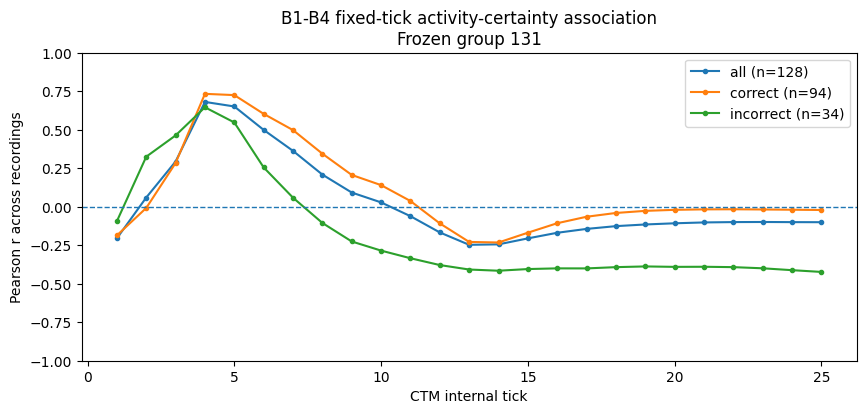

In [66]:
DISPLAY_GROUP = 131


plot_data = (
    certainty_fixed_tick
    .query(
        "domain == 'B1-B4' "
        "and cluster_id == @DISPLAY_GROUP"
    )
)


fig, ax = plt.subplots(
    figsize=(
        10,
        4,
    )
)


for subset in [
    "all",
    "correct",
    "incorrect",
]:

    subset_data = (
        plot_data
        .query(
            "subset == @subset"
        )
        .sort_values(
            "tick"
        )
    )

    ax.plot(
        subset_data[
            "tick"
        ],
        subset_data[
            "r_activity_certainty"
        ],
        marker="o",
        markersize=3,
        label=(
            f"{subset} "
            f"(n={subset_data['n_recordings'].iloc[0]})"
        ),
    )


ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)


ax.set_ylim(
    -1,
    1,
)

ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "Pearson r across recordings"
)

ax.set_title(
    "B1-B4 fixed-tick activity-certainty association\n"
    "Frozen group 131"
)

ax.legend()

plt.show()

### Certainty relationship summary

The certainty analysis gives different answers depending on how time is handled.

Within individual recordings, several groups show strong positive or negative activity-certainty correlations across the 25 internal ticks. However, fixed-tick correlations across recordings are generally more moderate and can change sign over computation.

For frozen group 131, the fixed-tick association is positive early, crosses approximately zero around the middle of computation, and becomes negative later. Incorrect B1-B4 trials show the strongest late negative association.

This shows that group activity and certainty have a time-dependent relationship rather than a single monotonic coupling.

Because certainty is derived from the model logits and can also be high for incorrect predictions, these associations are descriptive and do not yet establish evidence accumulation.

## 10. PCA population trajectories

PCA is used to describe the dominant directions of variation in the full CTM population state.

Each recording × internal-tick state is treated as one 256-dimensional observation.

PCA is fitted using B0-standardized activity only. The same B0 standardization and fitted PCA transformation are then applied unchanged to B1-B4.

Separate PCA spaces are not fitted for different objects or domains.

PCA maximizes represented variance, not object discrimination. Separation in PCA space therefore does not by itself imply a decision variable or diffusion process.

In [67]:
from sklearn.decomposition import PCA


# ------------------------------------------------------------
# Arrange population states as observations
#
# B0:
# 64 recordings × 25 ticks = 1600 observations
#
# Each observation has 256 state-unit values.
# ------------------------------------------------------------

b0_pca_input = (
    b0_standardized.reshape(
        -1,
        b0_standardized.shape[-1],
    )
)


b1_b4_pca_input = (
    b1_b4_standardized.reshape(
        -1,
        b1_b4_standardized.shape[-1],
    )
)


print(
    "B0 PCA input:",
    b0_pca_input.shape,
)

print(
    "B1-B4 PCA input:",
    b1_b4_pca_input.shape,
)


# ------------------------------------------------------------
# Fit PCA on B0 only
# ------------------------------------------------------------

population_pca = PCA(
    svd_solver="full"
)


b0_pca_flat = (
    population_pca.fit_transform(
        b0_pca_input
    )
)


# Transfer projection only.
b1_b4_pca_flat = (
    population_pca.transform(
        b1_b4_pca_input
    )
)


# Restore recording × tick structure.
b0_pca = (
    b0_pca_flat.reshape(
        64,
        25,
        -1,
    )
)


b1_b4_pca = (
    b1_b4_pca_flat.reshape(
        128,
        25,
        -1,
    )
)


explained_variance = (
    population_pca
    .explained_variance_ratio_
)


cumulative_variance = np.cumsum(
    explained_variance
)


print()
print(
    "PC1 explained variance:",
    explained_variance[
        0
    ],
)

print(
    "PC2 explained variance:",
    explained_variance[
        1
    ],
)

print(
    "PC1 + PC2:",
    explained_variance[
        :2
    ].sum(),
)

print(
    "PC1 + PC2 + PC3:",
    explained_variance[
        :3
    ].sum(),
)

B0 PCA input: (1600, 256)
B1-B4 PCA input: (3200, 256)

PC1 explained variance: 0.18339021212965095
PC2 explained variance: 0.13927068918859595
PC1 + PC2: 0.3226609013182469
PC1 + PC2 + PC3: 0.42247334390412916


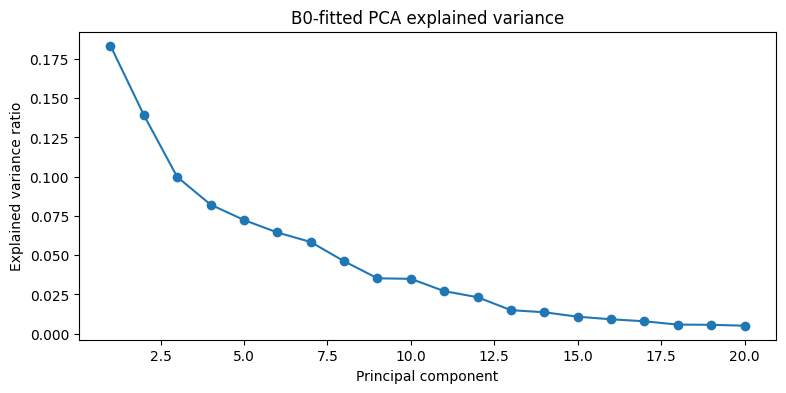

In [68]:
n_components_to_show = 20


fig, ax = plt.subplots(
    figsize=(
        9,
        4,
    )
)


ax.plot(
    np.arange(
        1,
        n_components_to_show + 1,
    ),
    explained_variance[
        :n_components_to_show
    ],
    marker="o",
)


ax.set_xlabel(
    "Principal component"
)

ax.set_ylabel(
    "Explained variance ratio"
)

ax.set_title(
    "B0-fitted PCA explained variance"
)


plt.show()

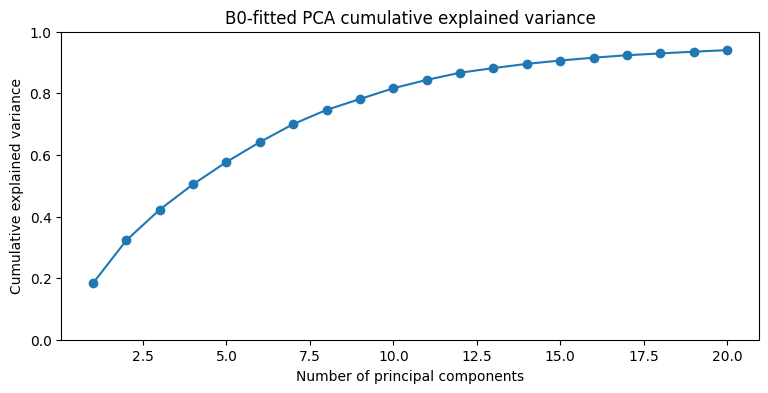

In [69]:
fig, ax = plt.subplots(
    figsize=(
        9,
        4,
    )
)


ax.plot(
    np.arange(
        1,
        n_components_to_show + 1,
    ),
    cumulative_variance[
        :n_components_to_show
    ],
    marker="o",
)


ax.set_xlabel(
    "Number of principal components"
)

ax.set_ylabel(
    "Cumulative explained variance"
)

ax.set_ylim(
    0,
    1,
)

ax.set_title(
    "B0-fitted PCA cumulative explained variance"
)


plt.show()

In [70]:
def plot_mean_pca_trajectories(
    scores,
    metadata,
    title,
    xlim=None,
    ylim=None,
):

    labels = metadata[
        "class_label"
    ].to_numpy()


    fig, ax = plt.subplots(
        figsize=(
            8,
            7,
        )
    )


    for class_id in sorted(
        np.unique(
            labels
        )
    ):

        mean_trajectory = (
            scores[
                labels
                ==
                class_id,
                :,
                :2,
            ]
            .mean(
                axis=0
            )
        )


        line = ax.plot(
            mean_trajectory[
                :,
                0
            ],
            mean_trajectory[
                :,
                1
            ],
            label=(
                f"class {class_id} "
                f"(n={(labels == class_id).sum()})"
            ),
        )[0]


        # Tick 1
        ax.scatter(
            mean_trajectory[
                0,
                0
            ],
            mean_trajectory[
                0,
                1
            ],
            marker="o",
            color=line.get_color(),
        )


        # Tick 25
        ax.scatter(
            mean_trajectory[
                -1,
                0
            ],
            mean_trajectory[
                -1,
                1
            ],
            marker="x",
            color=line.get_color(),
        )


    ax.set_xlabel(
        "PC1"
    )

    ax.set_ylabel(
        "PC2"
    )

    ax.set_title(
        title
        +
        "\ncircle = tick 1, x = tick 25"
    )


    if xlim is not None:

        ax.set_xlim(
            xlim
        )


    if ylim is not None:

        ax.set_ylim(
            ylim
        )


    ax.legend(
        bbox_to_anchor=(
            1.02,
            1,
        ),
        loc="upper left",
    )


    plt.show()

In [71]:
all_pc1 = np.concatenate(
    [
        b0_pca[
            :,
            :,
            0
        ].ravel(),

        b1_b4_pca[
            :,
            :,
            0
        ].ravel(),
    ]
)


all_pc2 = np.concatenate(
    [
        b0_pca[
            :,
            :,
            1
        ].ravel(),

        b1_b4_pca[
            :,
            :,
            1
        ].ravel(),
    ]
)


x_margin = (
    all_pc1.max()
    -
    all_pc1.min()
) * 0.05


y_margin = (
    all_pc2.max()
    -
    all_pc2.min()
) * 0.05


shared_xlim = (
    all_pc1.min()
    -
    x_margin,
    all_pc1.max()
    +
    x_margin,
)


shared_ylim = (
    all_pc2.min()
    -
    y_margin,
    all_pc2.max()
    +
    y_margin,
)

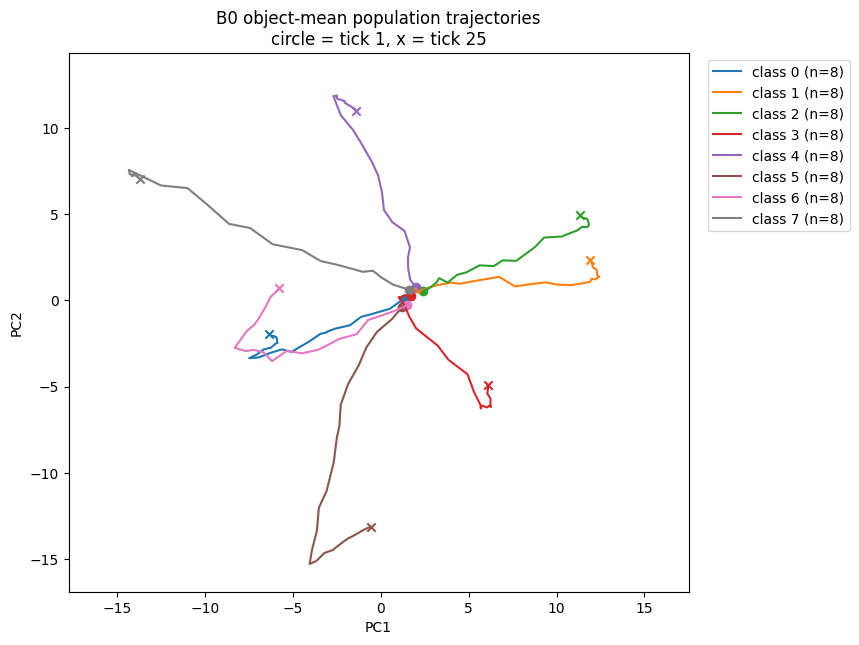

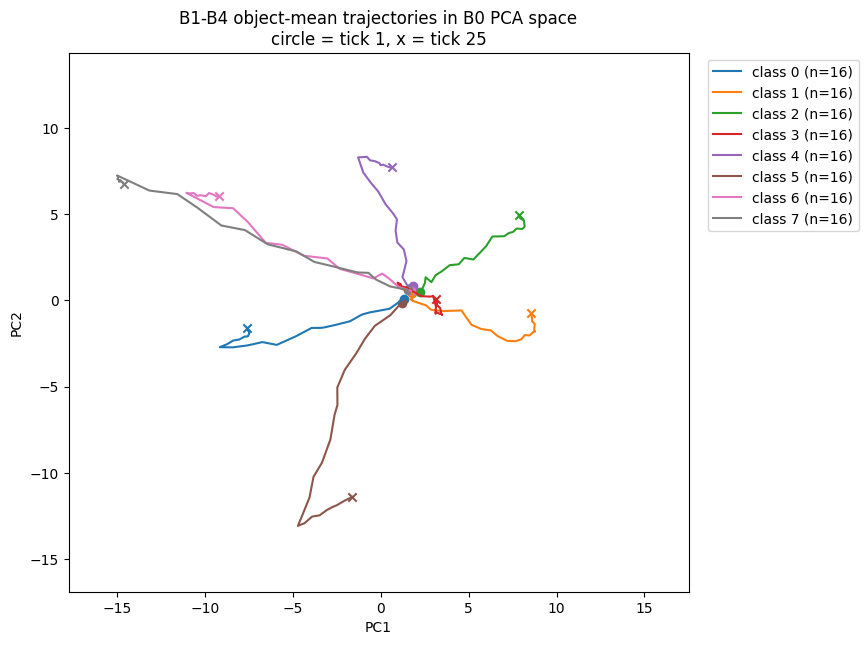

In [72]:
plot_mean_pca_trajectories(
    b0_pca,
    b0_metadata,
    "B0 object-mean population trajectories",
    shared_xlim,
    shared_ylim,
)


plot_mean_pca_trajectories(
    b1_b4_pca,
    b1_b4_metadata,
    "B1-B4 object-mean trajectories in B0 PCA space",
    shared_xlim,
    shared_ylim,
)

In [73]:
PCA_EXAMPLE_CLASSES = [
    0,
    2,
    4,
    6,
]


def deterministic_pca_examples(
    metadata,
):

    ordered = metadata.sort_values(
        [
            "participant",
            "block",
            "trial_number",
            "rep_number",
            "attempt_number",
            "file",
        ]
    )


    indices = []


    for class_id in (
        PCA_EXAMPLE_CLASSES
    ):

        class_rows = ordered[
            ordered[
                "class_label"
            ]
            ==
            class_id
        ]


        indices.append(
            int(
                class_rows.index[
                    0
                ]
            )
        )


    return indices

In [74]:
def plot_individual_pca_examples(
    scores,
    metadata,
    title,
    xlim,
    ylim,
):

    indices = (
        deterministic_pca_examples(
            metadata
        )
    )


    fig, ax = plt.subplots(
        figsize=(
            8,
            7,
        )
    )


    for recording_idx in indices:

        trajectory = (
            scores[
                recording_idx,
                :,
                :2,
            ]
        )


        class_id = int(
            metadata.loc[
                recording_idx,
                "class_label",
            ]
        )


        line = ax.plot(
            trajectory[
                :,
                0
            ],
            trajectory[
                :,
                1
            ],
            label=(
                f"class {class_id}, "
                f"row {recording_idx}"
            ),
        )[0]


        ax.scatter(
            trajectory[
                0,
                0
            ],
            trajectory[
                0,
                1
            ],
            marker="o",
            color=line.get_color(),
        )


        ax.scatter(
            trajectory[
                -1,
                0
            ],
            trajectory[
                -1,
                1
            ],
            marker="x",
            color=line.get_color(),
        )


    ax.set_xlim(
        shared_xlim
    )

    ax.set_ylim(
        shared_ylim
    )

    ax.set_xlabel(
        "PC1"
    )

    ax.set_ylabel(
        "PC2"
    )

    ax.set_title(
        title
        +
        "\ncircle = tick 1, x = tick 25"
    )

    ax.legend()

    plt.show()

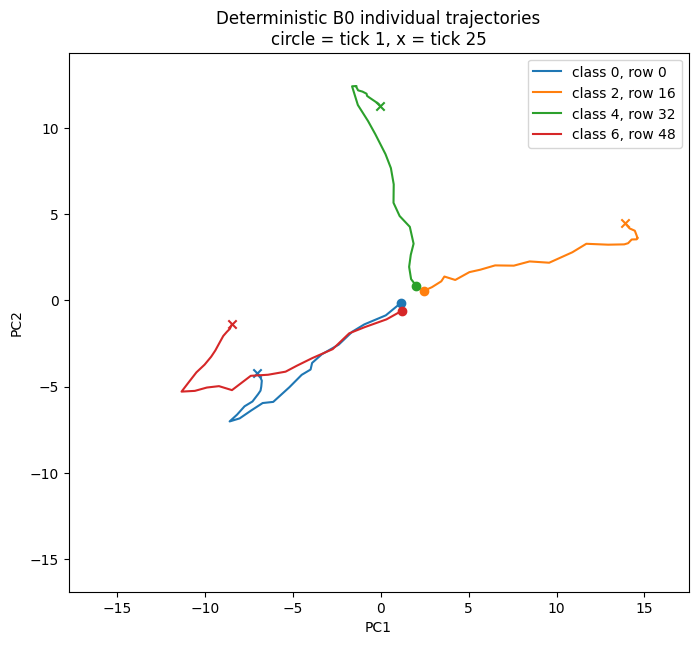

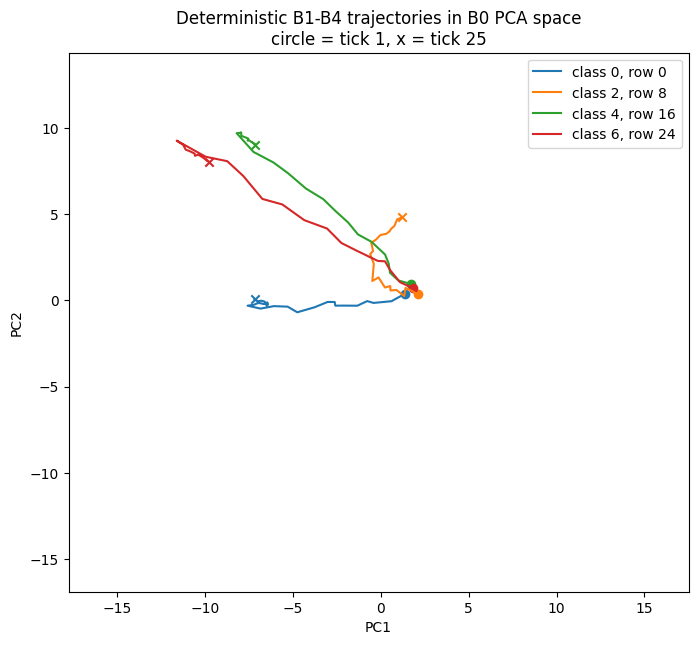

In [75]:
plot_individual_pca_examples(
    b0_pca,
    b0_metadata,
    "Deterministic B0 individual trajectories",
    shared_xlim,
    shared_ylim,
)


plot_individual_pca_examples(
    b1_b4_pca,
    b1_b4_metadata,
    "Deterministic B1-B4 trajectories in B0 PCA space",
    shared_xlim,
    shared_ylim,
)

### PCA observations

The first two B0-fitted principal components explain approximately 32.3% of population variance, and the first three explain approximately 42.2%.

Object-mean trajectories begin in a relatively similar region of the B0 PCA space and diverge along different paths over internal computation.

When B1-B4 activity is projected into the same frozen B0 PCA coordinates, substantial object-dependent trajectory structure remains visible, although several trajectories change in shape and extent relative to B0.

Deterministically selected individual recordings show similar large-scale movement through the PCA space, while also revealing trial-level variability.

These trajectories demonstrate structured population dynamics and transfer of population geometry. PCA itself maximizes variance rather than object discrimination, so trajectory separation does not establish an evidence-accumulation or diffusion process.

### Group-specific PCA

For one compact comparison, frozen group 131 is selected using B0 information only.

Groups 131 and 169 both had perfect mean bootstrap co-assignment (`1.0`). The lower cluster ID is used as a deterministic tie-break.

Group 131 contains state units `[11, 65, 143]`.

PCA is fitted on the B0-standardized original activity of these units and applied unchanged to B1-B4. This supplementary analysis does not replace the all-unit population PCA.

In [76]:
selected_group_id = 131

selected_group_units = (
    candidate_groups_r07[
        selected_group_id
    ]
)


print(
    "Selected group:",
    selected_group_id
)

print(
    "State units:",
    selected_group_units
)


b0_group_pca_input = (
    b0_standardized[
        :,
        :,
        selected_group_units,
    ]
    .reshape(
        -1,
        len(
            selected_group_units
        ),
    )
)


b1_b4_group_pca_input = (
    b1_b4_standardized[
        :,
        :,
        selected_group_units,
    ]
    .reshape(
        -1,
        len(
            selected_group_units
        ),
    )
)


group_pca = PCA(
    svd_solver="full"
)


b0_group_pca_flat = (
    group_pca.fit_transform(
        b0_group_pca_input
    )
)


b1_b4_group_pca_flat = (
    group_pca.transform(
        b1_b4_group_pca_input
    )
)


b0_group_pca = (
    b0_group_pca_flat.reshape(
        64,
        25,
        -1,
    )
)


b1_b4_group_pca = (
    b1_b4_group_pca_flat.reshape(
        128,
        25,
        -1,
    )
)


print()
print(
    "Group PC1 explained variance:",
    group_pca.explained_variance_ratio_[0],
)

print(
    "Group PC2 explained variance:",
    group_pca.explained_variance_ratio_[1],
)

print(
    "Group PC1 + PC2:",
    group_pca.explained_variance_ratio_[:2].sum(),
)

Selected group: 131
State units: [ 11  65 143]

Group PC1 explained variance: 0.9707604356954788
Group PC2 explained variance: 0.02559629352098161
Group PC1 + PC2: 0.9963567292164603


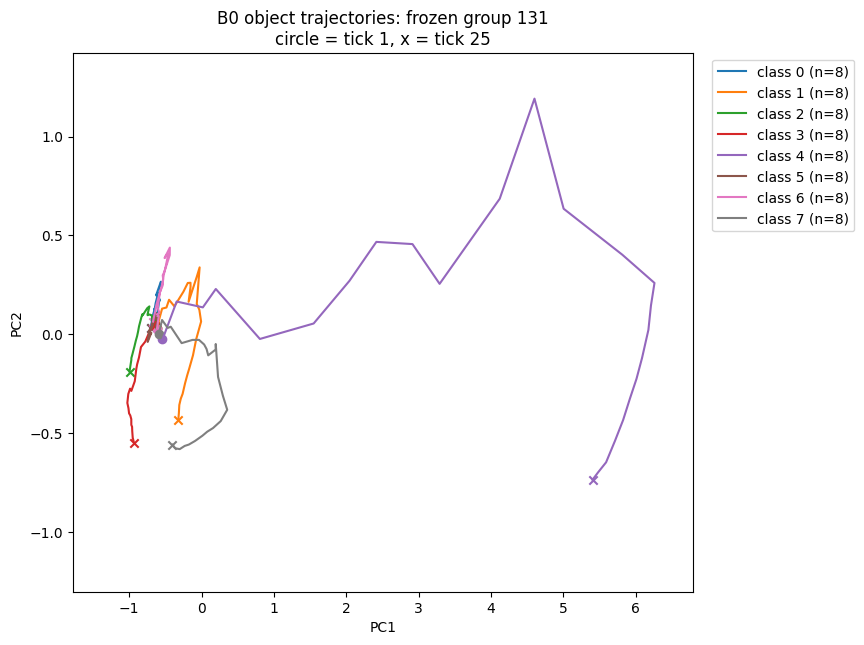

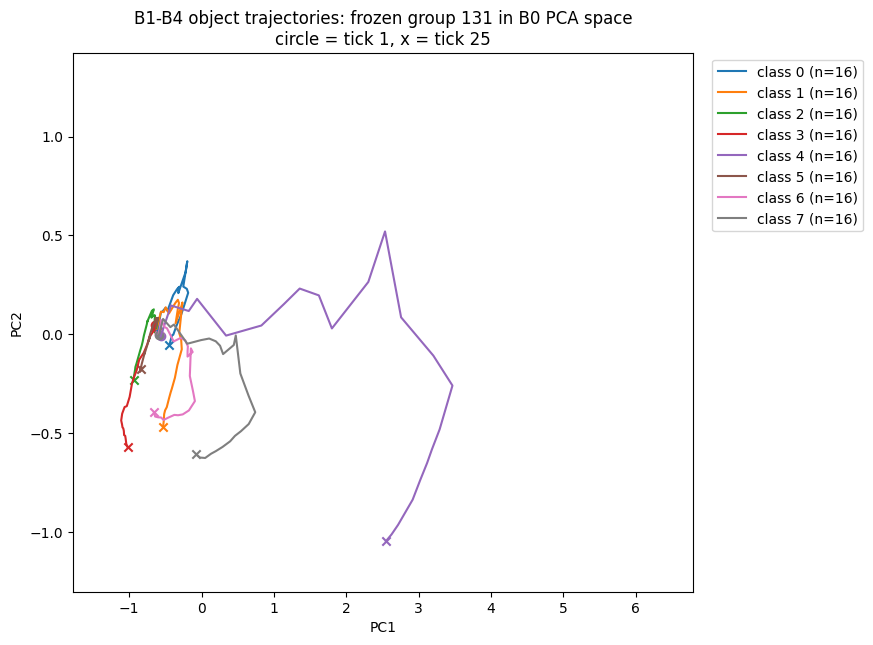

In [77]:
group_pc1 = np.concatenate(
    [
        b0_group_pca[
            :,
            :,
            0
        ].ravel(),

        b1_b4_group_pca[
            :,
            :,
            0
        ].ravel(),
    ]
)


group_pc2 = np.concatenate(
    [
        b0_group_pca[
            :,
            :,
            1
        ].ravel(),

        b1_b4_group_pca[
            :,
            :,
            1
        ].ravel(),
    ]
)


group_x_margin = (
    group_pc1.max()
    -
    group_pc1.min()
) * 0.05


group_y_margin = (
    group_pc2.max()
    -
    group_pc2.min()
) * 0.05


group_xlim = (
    group_pc1.min()
    -
    group_x_margin,
    group_pc1.max()
    +
    group_x_margin,
)


group_ylim = (
    group_pc2.min()
    -
    group_y_margin,
    group_pc2.max()
    +
    group_y_margin,
)


plot_mean_pca_trajectories(
    b0_group_pca,
    b0_metadata,
    "B0 object trajectories: frozen group 131",
    group_xlim,
    group_ylim,
)


plot_mean_pca_trajectories(
    b1_b4_group_pca,
    b1_b4_metadata,
    "B1-B4 object trajectories: frozen group 131 in B0 PCA space",
    group_xlim,
    group_ylim,
)

In [78]:
np.savez_compressed(
    POPULATION_DIR
    / "pca_all_units_b0_fitted.npz",

    components=(
        population_pca.components_
    ),

    explained_variance_ratio=(
        explained_variance
    ),

    b0_scores=b0_pca,

    b1_b4_scores=b1_b4_pca,
)


np.savez_compressed(
    POPULATION_DIR
    / "pca_group_131_b0_fitted.npz",

    state_units=(
        selected_group_units
    ),

    components=(
        group_pca.components_
    ),

    explained_variance_ratio=(
        group_pca.explained_variance_ratio_
    ),

    b0_scores=b0_group_pca,

    b1_b4_scores=b1_b4_group_pca,
)


print(
    "PCA results saved."
)

PCA results saved.


### Group-specific PCA observation

Frozen group 131 is almost one-dimensional in its B0-fitted PCA space.

PC1 explains approximately 97.1% of its variance, while PC1 and PC2 together explain approximately 99.6%.

This is consistent with the strong positive correlation among the three member units: most of their joint activity changes along a single dominant direction.

Object-dependent trajectories remain visible when B1-B4 is projected into the same frozen group-PCA coordinates, although their shapes and amplitudes are not identical to B0.

This supports a compact shared population mode, but it does not establish that PC1 is a decision variable or an evidence-accumulation axis.

## 11. Population-analysis review checkpoint

| Question | Result |
|---|---|
| Were candidate correlated groups found? | Yes. Seven small candidate groups were found at the exploratory $r=0.7$ complete-linkage cut, containing 22 of 256 units. |
| How sensitive was grouping to the correlation threshold? | Strongly. There were 19 candidate groups at $r=0.6$, 7 at $r=0.7$, and 1 at $r=0.8$. The threshold is therefore treated as exploratory, not validated. |
| How stable were the B0 groups? | Stability was heterogeneous. Groups 131 and 169 had perfect mean pair co-assignment, group 175 was also highly stable, while the remaining groups were progressively less stable. |
| Did the groups persist in B1-B4? | Yes, all seven frozen B0 groups retained substantial positive within-group correlation in B1-B4, although some weakened and others strengthened. |
| Was activity related to object identity? | Yes. All seven groups showed strong object-related variation in B0, and substantial object-related structure remained in B1-B4. |
| Was activity related to certainty? | Yes, but the relationship was strongly time-dependent. Within-recording correlations were often large, while fixed-tick correlations across recordings were generally more moderate and sometimes changed sign across ticks. |
| What did whole-population PCA show? | PC1 explained 18.3%, PC2 13.9%, and the first two together 32.3% of B0 population variance. Object-dependent trajectories remained visible when B1-B4 was projected into the same B0 PCA space. |
| What did group-specific PCA show? | Frozen group 131 was nearly one-dimensional: PC1 explained 97.1% and PC1+PC2 explained 99.6% of its variance. |
| What remains unresolved before DDM-like analysis? | A defensible decision variable has not yet been defined. We still need to test whether any population direction shows accumulation-like dynamics beyond shared tick trends, whether such dynamics relate to changing external evidence, and whether a threshold-like interpretation is justified. |

### Interpretation boundary

The current results support reproducible correlated CTM motifs, object-related population structure, transfer of population geometry, and time-dependent relationships with model certainty.

They do **not** yet establish a diffusion process, evidence accumulator, decision threshold, or reaction-time analogue.

CTM internal ticks remain computational iterations rather than physical milliseconds.

In [79]:
population_summary = pd.DataFrame(
    {
        "metric": [
            "candidate_groups_r07",
            "units_in_candidate_groups",
            "candidate_groups_r06",
            "candidate_groups_r08",
            "all_unit_pc1_variance",
            "all_unit_pc2_variance",
            "all_unit_pc1_pc2_variance",
            "all_unit_pc1_pc2_pc3_variance",
            "group131_pc1_variance",
            "group131_pc1_pc2_variance",
        ],

        "value": [
            7,
            22,
            19,
            1,
            explained_variance[0],
            explained_variance[1],
            explained_variance[:2].sum(),
            explained_variance[:3].sum(),
            group_pca.explained_variance_ratio_[0],
            group_pca.explained_variance_ratio_[:2].sum(),
        ],
    }
)


population_summary.to_csv(
    POPULATION_DIR
    / "population_analysis_summary.csv",
    index=False,
)


print(
    "Population-analysis summary saved."
)

Population-analysis summary saved.


In [80]:
residual_transfer_rows = []


for (
    cluster_id,
    units,
) in candidate_groups_r07.items():

    b0_residual_pairs = (
        within_group_correlations(
            corr_C_residual,
            units,
        )
    )

    b1_b4_residual_pairs = (
        within_group_correlations(
            corr_b1_C_residual,
            units,
        )
    )


    residual_transfer_rows.append(
        {
            "cluster_id": int(
                cluster_id
            ),

            "n_units": int(
                len(
                    units
                )
            ),

            "state_units": (
                units.tolist()
            ),

            "b0_residual_mean_r": float(
                b0_residual_pairs.mean()
            ),

            "b0_residual_min_r": float(
                b0_residual_pairs.min()
            ),

            "b1_b4_residual_mean_r": float(
                b1_b4_residual_pairs.mean()
            ),

            "b1_b4_residual_min_r": float(
                b1_b4_residual_pairs.min()
            ),
        }
    )


frozen_group_residual = (
    pd.DataFrame(
        residual_transfer_rows
    )
    .sort_values(
        "cluster_id"
    )
)


frozen_group_residual

,cluster_id,n_units,state_units,b0_residual_mean_r,b0_residual_min_r,b1_b4_residual_mean_r,b1_b4_residual_min_r
0,45,3,"[6, 24, 48]",0.785625,0.763285,0.818022,0.794209
1,87,3,"[63, 160, 231]",0.646087,0.589847,0.648507,0.561503
2,114,4,"[102, 119, 141, 207]",0.792050,0.659607,0.802480,0.677758
3,131,3,"[11, 65, 143]",0.928743,0.887406,0.856396,0.805843
4,169,3,"[38, 68, 173]",0.838602,0.770692,0.839647,0.764065
5,175,3,"[69, 78, 120]",0.795685,0.785541,0.723167,0.642307
6,181,3,"[156, 190, 246]",0.742461,0.676700,0.647876,0.535835


In [81]:
frozen_group_residual.to_csv(
    POPULATION_DIR
    / "frozen_group_residual_correlations.csv",
    index=False,
)

### Transfer interpretation

All seven frozen B0 groups retain positive mean within-group correlation in B1-B4, but transfer strength is heterogeneous.

Only groups 45 and 169 retain a minimum pairwise correlation above the exploratory $r=0.7$ criterion in B1-B4. Other groups preserve positive structure while one or more member pairs weaken below that original discovery threshold.

The appropriate conclusion is therefore that **positive correlation structure persists with heterogeneous weakening or strengthening**, not that all groups satisfy the original clustering criterion in the transfer domain.

In [82]:
np.savez_compressed(
    POPULATION_DIR
    / "pca_all_units_b0_fitted.npz",

    # B0-fitted activity scaler
    activity_mean=b0_unit_mean,

    activity_std=b0_unit_std,

    # PCA transform itself
    pca_mean=(
        population_pca.mean_
    ),

    components=(
        population_pca.components_
    ),

    explained_variance=(
        population_pca.explained_variance_
    ),

    explained_variance_ratio=(
        population_pca.explained_variance_ratio_
    ),

    # Already transformed data
    b0_scores=b0_pca,

    b1_b4_scores=b1_b4_pca,
)

In [83]:
np.savez_compressed(
    POPULATION_DIR
    / "pca_group_131_b0_fitted.npz",

    state_units=(
        selected_group_units
    ),

    activity_mean=(
        b0_unit_mean[
            selected_group_units
        ]
    ),

    activity_std=(
        b0_unit_std[
            selected_group_units
        ]
    ),

    pca_mean=(
        group_pca.mean_
    ),

    components=(
        group_pca.components_
    ),

    explained_variance=(
        group_pca.explained_variance_
    ),

    explained_variance_ratio=(
        group_pca.explained_variance_ratio_
    ),

    b0_scores=b0_group_pca,

    b1_b4_scores=b1_b4_group_pca,
)

## 12. Object-directed population score

### 12.1 Select a two-object pilot from B0

Frozen group 131 is retained as the illustrative population because it was selected previously using B0 bootstrap stability.

For each object, a three-dimensional prototype is calculated from the B0-standardized original activity of group 131 by averaging across all recordings of that object and all 25 internal ticks.

The two objects with the greatest Euclidean distance between these B0 prototypes are selected.

This deliberately chooses a favourable, maximally separated object pair for an illustrative pilot. It is not intended to represent all object distinctions.

Because the prototypes average across all internal ticks, they are whole-trajectory B0 prototypes rather than final-decision states.

In [84]:
from itertools import combinations


PILOT_GROUP_ID = 131

pilot_units = np.asarray(
    candidate_groups_r07[
        PILOT_GROUP_ID
    ],
    dtype=int,
)


print(
    "Pilot group:",
    PILOT_GROUP_ID
)

print(
    "State units:",
    pilot_units
)


# ------------------------------------------------------------
# 3D B0 population state for group 131
#
# shape:
# [recording, tick, 3 units]
# ------------------------------------------------------------

b0_pilot_activity = (
    b0_standardized[
        :,
        :,
        pilot_units,
    ]
)


b0_labels = (
    b0_metadata[
        "class_label"
    ]
    .to_numpy(
        dtype=int
    )
)


# ------------------------------------------------------------
# One whole-trajectory centroid per object
# ------------------------------------------------------------

object_centroids = {}

centroid_rows = []


for object_id in sorted(
    np.unique(
        b0_labels
    )
):

    mask = (
        b0_labels
        ==
        object_id
    )

    object_activity = (
        b0_pilot_activity[
            mask
        ]
    )

    centroid = object_activity.mean(
        axis=(
            0,
            1,
        )
    )

    object_centroids[
        int(
            object_id
        )
    ] = centroid


    centroid_rows.append(
        {
            "object": int(
                object_id
            ),

            "n_recordings": int(
                mask.sum()
            ),

            "unit_11": float(
                centroid[
                    0
                ]
            ),

            "unit_65": float(
                centroid[
                    1
                ]
            ),

            "unit_143": float(
                centroid[
                    2
                ]
            ),
        }
    )


centroid_table = pd.DataFrame(
    centroid_rows
)


centroid_table

Pilot group: 131
State units: [ 11  65 143]


,object,n_recordings,unit_11,unit_65,unit_143
0,0,8,-0.245297,-0.415348,-0.420236
1,1,8,-0.139716,-0.202954,-0.064872
2,2,8,-0.438392,-0.471617,-0.480260
3,3,8,-0.696314,-0.406172,-0.424454
4,4,8,2.254064,2.185002,2.253181
5,5,8,-0.358362,-0.416503,-0.404433
6,6,8,-0.119732,-0.374590,-0.467178
7,7,8,-0.256250,0.102183,0.008253


In [85]:
pair_rows = []


for (
    object_a,
    object_b,
) in combinations(
    sorted(
        object_centroids
    ),
    2,
):

    centroid_a = object_centroids[
        object_a
    ]

    centroid_b = object_centroids[
        object_b
    ]


    distance = np.linalg.norm(
        centroid_a
        -
        centroid_b
    )


    pair_rows.append(
        {
            "object_a": (
                object_a
            ),

            "object_b": (
                object_b
            ),

            "centroid_distance": float(
                distance
            ),
        }
    )


pair_distances = (
    pd.DataFrame(
        pair_rows
    )
    .sort_values(
        [
            "centroid_distance",
            "object_a",
            "object_b",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(
        drop=True
    )
)


pair_distances

,object_a,object_b,centroid_distance
0,3,4,4.752751
1,2,4,4.666759
2,4,5,4.544834
3,0,4,4.489520
4,4,6,4.425695
5,1,4,4.099499
6,4,7,3.959736
7,3,7,0.799573
8,2,7,0.775285
9,1,3,0.693107


In [86]:
selected_pair = (
    pair_distances.iloc[
        0
    ]
)


OBJECT_A = int(
    selected_pair[
        "object_a"
    ]
)

OBJECT_B = int(
    selected_pair[
        "object_b"
    ]
)


centroid_A = (
    object_centroids[
        OBJECT_A
    ]
)

centroid_B = (
    object_centroids[
        OBJECT_B
    ]
)


print(
    "Selected B0 object pair:",
    OBJECT_A,
    "vs",
    OBJECT_B,
)

print(
    "Centroid distance:",
    selected_pair[
        "centroid_distance"
    ],
)

print()

print(
    f"Object {OBJECT_A} centroid:",
    centroid_A,
)

print(
    f"Object {OBJECT_B} centroid:",
    centroid_B,
)

print()

print(
    "B0 recordings per selected object:",
    int(
        (
            b0_labels
            ==
            OBJECT_A
        ).sum()
    ),
    "and",
    int(
        (
            b0_labels
            ==
            OBJECT_B
        ).sum()
    ),
)

Selected B0 object pair: 3 vs 4
Centroid distance: 4.752751158474206

Object 3 centroid: [-0.69631406 -0.40617212 -0.42445417]
Object 4 centroid: [2.25406358 2.18500202 2.25318135]

B0 recordings per selected object: 8 and 8


### Two-object pilot selection

Using frozen group 131, one whole-trajectory B0 centroid was calculated for each object from the three B0-standardized state units.

The maximally separated pair is object 3 versus object 4, with Euclidean centroid distance approximately `4.753`.

Several of the next-largest distances also involve object 4, indicating that this pilot largely captures a strong object-4-versus-other-objects direction within group 131.

The 3-versus-4 pair is retained because it follows the declared B0-only maximum-distance rule. It is an illustrative favourable pair rather than a representative summary of all object distinctions.

### 12.2 Signed population score

The selected B0 prototypes define a midpoint and a normalized population direction.

For the selected objects 3 and 4:

$$
\mathbf{m}
=
\frac{\boldsymbol{\mu}_3+\boldsymbol{\mu}_4}{2},
$$

and

$$
\hat{\mathbf{w}}
=
\frac{\boldsymbol{\mu}_3-\boldsymbol{\mu}_4}
{\|\boldsymbol{\mu}_3-\boldsymbol{\mu}_4\|}.
$$

For each recording and internal tick, the signed population score is

$$
s(t)
=
\bigl(\mathbf{x}(t)-\mathbf{m}\bigr)^\top
\hat{\mathbf{w}}.
$$

Positive values lie toward the B0 prototype of object 3. Negative values lie toward the B0 prototype of object 4.

Zero is only the midpoint between the two B0 prototypes. It is not assumed to be the CTM's learned decision threshold.

In [87]:
# ------------------------------------------------------------
# Freeze the B0-derived score geometry
# ------------------------------------------------------------

score_midpoint = (
    centroid_A
    +
    centroid_B
) / 2.0


score_direction = (
    centroid_A
    -
    centroid_B
)


score_direction_norm = np.linalg.norm(
    score_direction
)


score_unit_direction = (
    score_direction
    /
    score_direction_norm
)


print(
    "Object A:",
    OBJECT_A,
)

print(
    "Object B:",
    OBJECT_B,
)

print()

print(
    "Midpoint:",
    score_midpoint,
)

print(
    "Unit direction:",
    score_unit_direction,
)

print(
    "Direction norm:",
    np.linalg.norm(
        score_unit_direction
    ),
)

Object A: 3
Object B: 4

Midpoint: [0.77887476 0.88941495 0.91436359]
Unit direction: [-0.62077259 -0.54519457 -0.56338643]
Direction norm: 1.0


In [88]:
def population_score(
    standardized_activity,
    units,
    midpoint,
    direction,
):
    """
    standardized_activity:
        [recording, tick, state_unit]

    returns:
        [recording, tick]
    """

    group_state = standardized_activity[
        :,
        :,
        units,
    ]

    centered_state = (
        group_state
        -
        midpoint[
            None,
            None,
            :
        ]
    )

    return np.einsum(
        "rtu,u->rt",
        centered_state,
        direction,
    )

In [89]:
b0_signed_score = population_score(
    standardized_activity=b0_standardized,
    units=pilot_units,
    midpoint=score_midpoint,
    direction=score_unit_direction,
)


print(
    "B0 signed score shape:",
    b0_signed_score.shape,
)

print(
    "All finite:",
    np.isfinite(
        b0_signed_score
    ).all(),
)

print(
    "Observed score range:",
    b0_signed_score.min(),
    "to",
    b0_signed_score.max(),
)

B0 signed score shape: (64, 25)
All finite: True
Observed score range: -4.930059534913515 to 2.5952040636965488


In [90]:
b0_pair_mask = (
    (b0_labels == OBJECT_A)
    |
    (b0_labels == OBJECT_B)
)


b0_pair_score = (
    b0_signed_score[
        b0_pair_mask
    ]
)


b0_pair_labels = (
    b0_labels[
        b0_pair_mask
    ]
)


print(
    "Selected-pair B0 recordings:",
    len(
        b0_pair_labels
    ),
)

print(
    "Object 3:",
    np.sum(
        b0_pair_labels
        ==
        OBJECT_A
    ),
)

print(
    "Object 4:",
    np.sum(
        b0_pair_labels
        ==
        OBJECT_B
    ),
)

Selected-pair B0 recordings: 16
Object 3: 8
Object 4: 8


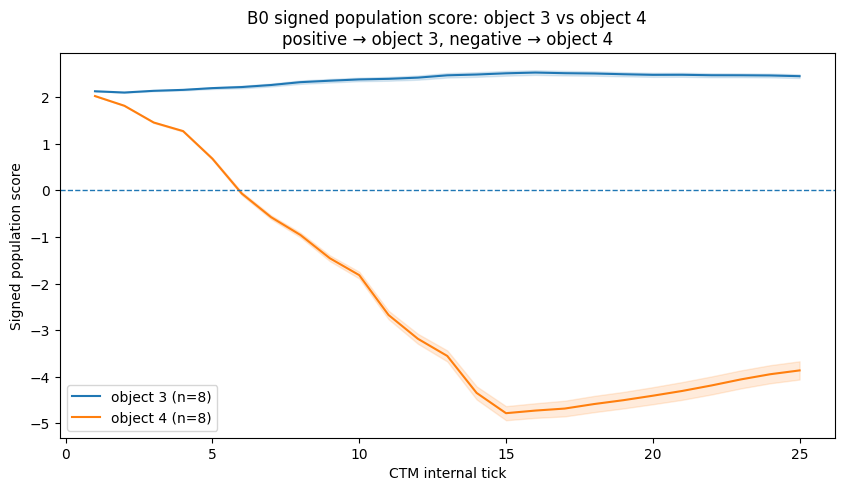

In [91]:
ticks = np.arange(
    1,
    26,
)


fig, ax = plt.subplots(
    figsize=(
        10,
        5,
    )
)


for object_id in [
    OBJECT_A,
    OBJECT_B,
]:

    mask = (
        b0_pair_labels
        ==
        object_id
    )

    traces = (
        b0_pair_score[
            mask
        ]
    )

    mean_trace = traces.mean(
        axis=0
    )

    std_trace = traces.std(
        axis=0,
        ddof=0,
    )


    line = ax.plot(
        ticks,
        mean_trace,
        label=(
            f"object {object_id} "
            f"(n={mask.sum()})"
        ),
    )[0]


    ax.fill_between(
        ticks,
        mean_trace
        -
        std_trace,
        mean_trace
        +
        std_trace,
        alpha=0.15,
        color=line.get_color(),
    )


ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)


ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "Signed population score"
)

ax.set_title(
    "B0 signed population score: object 3 vs object 4\n"
    "positive → object 3, negative → object 4"
)

ax.legend()


plt.show()

### B0 signed-score observation

The B0 score does not show two alternatives symmetrically diverging from an initially neutral state.

Object 3 begins strongly on the positive side and remains there with relatively little change. Object 4 also begins positive, then crosses zero around the early-middle internal ticks and moves strongly toward the negative prototype before partially rebounding later.

Thus, for this favourable B0-selected pair, the population direction appears to capture a substantial transformation of object-4 activity while object-3 activity is comparatively stable.

Because the score axis was defined from whole-trajectory B0 prototypes, this B0 trajectory is descriptive rather than an independent validation of accumulation.

In [92]:
score_definition = {
    "pilot_group_id": int(
        PILOT_GROUP_ID
    ),

    "state_units": (
        pilot_units.tolist()
    ),

    "object_positive": int(
        OBJECT_A
    ),

    "object_negative": int(
        OBJECT_B
    ),

    "selection_rule": (
        "maximum Euclidean distance between "
        "whole-trajectory B0 object centroids"
    ),

    "centroid_positive": (
        centroid_A.tolist()
    ),

    "centroid_negative": (
        centroid_B.tolist()
    ),

    "midpoint": (
        score_midpoint.tolist()
    ),

    "unit_direction": (
        score_unit_direction.tolist()
    ),
}


with (
    POPULATION_DIR
    / "signed_population_score_definition.json"
).open(
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        score_definition,
        f,
        indent=2,
    )


print(
    "Signed population score frozen."
)

Signed population score frozen.


In [93]:
b1_b4_signed_score = population_score(
    standardized_activity=(
        b1_b4_standardized
    ),
    units=pilot_units,
    midpoint=score_midpoint,
    direction=score_unit_direction,
)


b1_b4_labels = (
    b1_b4_metadata[
        "class_label"
    ]
    .to_numpy(
        dtype=int
    )
)


b1_b4_pair_mask = (
    (b1_b4_labels == OBJECT_A)
    |
    (b1_b4_labels == OBJECT_B)
)


b1_b4_pair_score = (
    b1_b4_signed_score[
        b1_b4_pair_mask
    ]
)


b1_b4_pair_labels = (
    b1_b4_labels[
        b1_b4_pair_mask
    ]
)


b1_b4_pair_metadata = (
    b1_b4_metadata.loc[
        b1_b4_pair_mask
    ]
    .reset_index(
        drop=True
    )
)


print(
    "Selected-pair B1-B4 recordings:",
    len(
        b1_b4_pair_labels
    ),
)

print(
    f"Object {OBJECT_A}:",
    np.sum(
        b1_b4_pair_labels
        ==
        OBJECT_A
    ),
)

print(
    f"Object {OBJECT_B}:",
    np.sum(
        b1_b4_pair_labels
        ==
        OBJECT_B
    ),
)

print(
    "All scores finite:",
    np.isfinite(
        b1_b4_pair_score
    ).all(),
)

print(
    "Observed score range:",
    b1_b4_pair_score.min(),
    "to",
    b1_b4_pair_score.max(),
)

Selected-pair B1-B4 recordings: 32
Object 3: 16
Object 4: 16
All scores finite: True
Observed score range: -4.250821315913887 to 2.910309954722975


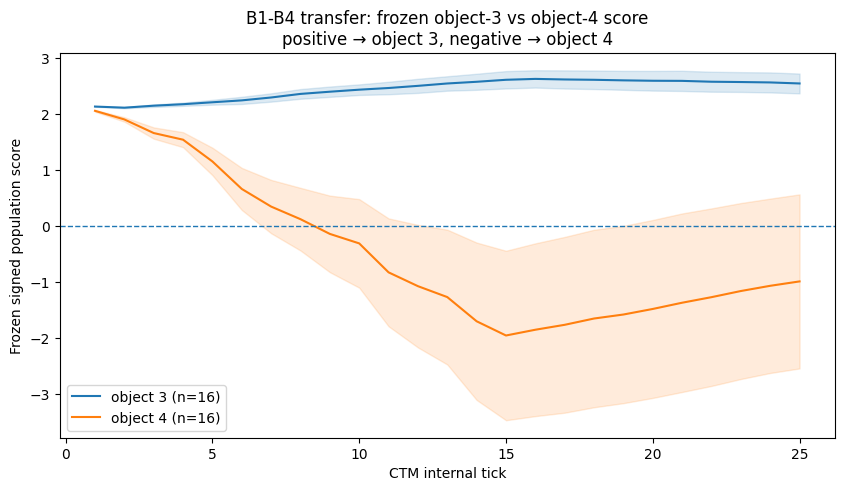

In [94]:
fig, ax = plt.subplots(
    figsize=(
        10,
        5,
    )
)


for object_id in [
    OBJECT_A,
    OBJECT_B,
]:

    mask = (
        b1_b4_pair_labels
        ==
        object_id
    )

    traces = (
        b1_b4_pair_score[
            mask
        ]
    )

    mean_trace = traces.mean(
        axis=0
    )

    std_trace = traces.std(
        axis=0,
        ddof=0,
    )


    line = ax.plot(
        ticks,
        mean_trace,
        label=(
            f"object {object_id} "
            f"(n={mask.sum()})"
        ),
    )[0]


    ax.fill_between(
        ticks,
        mean_trace
        -
        std_trace,
        mean_trace
        +
        std_trace,
        alpha=0.15,
        color=line.get_color(),
    )


ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)


ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "Frozen signed population score"
)

ax.set_title(
    "B1-B4 transfer: frozen object-3 vs object-4 score\n"
    "positive → object 3, negative → object 4"
)

ax.legend()


plt.show()

In [95]:
score_prediction = np.where(
    b1_b4_pair_score
    >=
    0.0,
    OBJECT_A,
    OBJECT_B,
)


score_accuracy_by_tick = (
    score_prediction
    ==
    b1_b4_pair_labels[
        :,
        None
    ]
).mean(
    axis=0
)


score_accuracy_table = pd.DataFrame(
    {
        "tick": np.arange(
            1,
            26,
        ),

        "score_accuracy": (
            score_accuracy_by_tick
        ),
    }
)


score_accuracy_table

,tick,score_accuracy
0,1,0.50000
1,2,0.50000
2,3,0.50000
3,4,0.50000
4,5,0.50000
5,6,0.50000
6,7,0.65625
7,8,0.71875
8,9,0.75000
9,10,0.75000


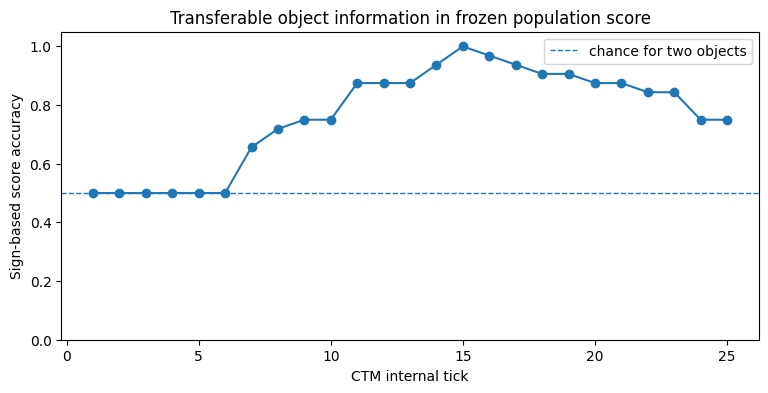

In [96]:
fig, ax = plt.subplots(
    figsize=(
        9,
        4,
    )
)


ax.plot(
    score_accuracy_table[
        "tick"
    ],
    score_accuracy_table[
        "score_accuracy"
    ],
    marker="o",
)


ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="chance for two objects",
)


ax.set_ylim(
    0,
    1.05,
)

ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "Sign-based score accuracy"
)

ax.set_title(
    "Transferable object information in frozen population score"
)

ax.legend()


plt.show()

In [97]:
print(
    "Tick-1 score accuracy:",
    score_accuracy_by_tick[
        0
    ],
)

print(
    "Best score accuracy:",
    score_accuracy_by_tick.max(),
)

print(
    "Best tick:",
    np.argmax(
        score_accuracy_by_tick
    )
    + 1,
)

print(
    "Final-tick score accuracy:",
    score_accuracy_by_tick[
        -1
    ],
)

Tick-1 score accuracy: 0.5
Best score accuracy: 1.0
Best tick: 15
Final-tick score accuracy: 0.75


### Frozen-score transfer observation

The B0-derived signed population score transfers to B1-B4.

For the selected object-3 versus object-4 pilot:

- tick 1 sign-based accuracy is 50%,
- discrimination begins improving after the early ticks,
- accuracy reaches 100% at tick 15,
- final-tick accuracy falls to 75%.

Object 3 remains strongly on the positive side throughout computation. Object 4 progressively moves from the positive side toward the negative prototype, reaches its strongest separation around the middle-late ticks, and then partially returns toward zero.

Thus, this population direction shows progressive development of object discrimination, but not monotonic accumulation through the final tick.

The sign-based score is a population-derived diagnostic, not the CTM's actual classifier.

In [98]:
with np.load(
    FOUNDATION_DIR
    / "p1_b1_b4_activity.npz"
) as data:

    b1_b4_logits = data[
        "logits"
    ].astype(
        np.float64
    )

    b1_b4_predictions_per_tick = data[
        "predictions_per_tick"
    ].astype(
        np.int64
    )


print(
    "Logits:",
    b1_b4_logits.shape,
)

print(
    "Predictions per tick:",
    b1_b4_predictions_per_tick.shape,
)


assert b1_b4_logits.shape == (
    128,
    25,
    8,
)

assert b1_b4_predictions_per_tick.shape == (
    128,
    25,
)

Logits: (128, 25, 8)
Predictions per tick: (128, 25)


In [99]:
pair_logits = (
    b1_b4_logits[
        b1_b4_pair_mask
    ]
)


pair_full_prediction = (
    b1_b4_predictions_per_tick[
        b1_b4_pair_mask
    ]
)


pair_certainty = (
    b1_b4_certainty[
        b1_b4_pair_mask
    ]
)


logit_difference = (
    pair_logits[
        :,
        :,
        OBJECT_A,
    ]
    -
    pair_logits[
        :,
        :,
        OBJECT_B,
    ]
)


print(
    "Logit difference:",
    logit_difference.shape,
)

print(
    "Observed range:",
    logit_difference.min(),
    "to",
    logit_difference.max(),
)

print(
    "All finite:",
    np.isfinite(
        logit_difference
    ).all(),
)

Logit difference: (32, 25)
Observed range: -12.867727994918823 to 16.972325086593628
All finite: True


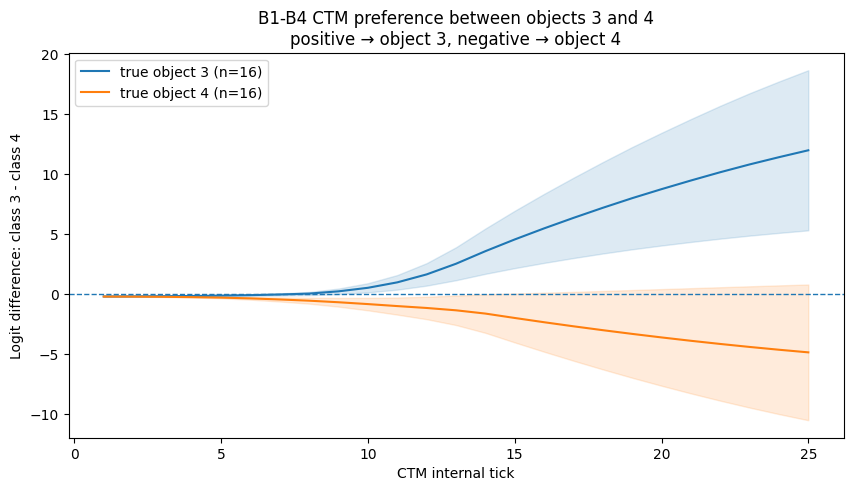

In [100]:
fig, ax = plt.subplots(
    figsize=(
        10,
        5,
    )
)


for object_id in [
    OBJECT_A,
    OBJECT_B,
]:

    mask = (
        b1_b4_pair_labels
        ==
        object_id
    )

    traces = (
        logit_difference[
            mask
        ]
    )

    mean_trace = traces.mean(
        axis=0
    )

    std_trace = traces.std(
        axis=0,
        ddof=0,
    )


    line = ax.plot(
        ticks,
        mean_trace,
        label=(
            f"true object {object_id} "
            f"(n={mask.sum()})"
        ),
    )[0]


    ax.fill_between(
        ticks,
        mean_trace
        -
        std_trace,
        mean_trace
        +
        std_trace,
        alpha=0.15,
        color=line.get_color(),
    )


ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)


ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "Logit difference: class 3 - class 4"
)

ax.set_title(
    "B1-B4 CTM preference between objects 3 and 4\n"
    "positive → object 3, negative → object 4"
)

ax.legend()


plt.show()

In [101]:
# Population-score binary decision
score_binary_prediction = np.where(
    b1_b4_pair_score
    >=
    0,
    OBJECT_A,
    OBJECT_B,
)


# Binary decision based only on the two selected logits
logit_binary_prediction = np.where(
    logit_difference
    >=
    0,
    OBJECT_A,
    OBJECT_B,
)


decision_rows = []


for tick_index in range(
    25
):

    true_labels = (
        b1_b4_pair_labels
    )


    score_accuracy = np.mean(
        score_binary_prediction[
            :,
            tick_index,
        ]
        ==
        true_labels
    )


    logit_pair_accuracy = np.mean(
        logit_binary_prediction[
            :,
            tick_index,
        ]
        ==
        true_labels
    )


    full_model_accuracy = np.mean(
        pair_full_prediction[
            :,
            tick_index,
        ]
        ==
        true_labels
    )


    third_object_rate = np.mean(
        ~np.isin(
            pair_full_prediction[
                :,
                tick_index,
            ],
            [
                OBJECT_A,
                OBJECT_B,
            ],
        )
    )


    score_logit_agreement = np.mean(
        score_binary_prediction[
            :,
            tick_index,
        ]
        ==
        logit_binary_prediction[
            :,
            tick_index,
        ]
    )


    decision_rows.append(
        {
            "tick": (
                tick_index
                +
                1
            ),

            "population_score_accuracy": (
                score_accuracy
            ),

            "pairwise_logit_accuracy": (
                logit_pair_accuracy
            ),

            "full_8class_accuracy": (
                full_model_accuracy
            ),

            "third_object_prediction_rate": (
                third_object_rate
            ),

            "score_logit_sign_agreement": (
                score_logit_agreement
            ),
        }
    )


decision_comparison = pd.DataFrame(
    decision_rows
)


decision_comparison

,tick,population_score_accuracy,pairwise_logit_accuracy,full_8class_accuracy,third_object_prediction_rate,score_logit_sign_agreement
0,1,0.50000,0.50000,0.50000,0.00000,0.00000
1,2,0.50000,0.50000,0.50000,0.00000,0.00000
2,3,0.50000,0.50000,0.50000,0.00000,0.00000
3,4,0.50000,0.50000,0.50000,0.03125,0.00000
4,5,0.50000,0.50000,0.50000,0.06250,0.00000
5,6,0.50000,0.50000,0.46875,0.15625,0.00000
6,7,0.65625,0.81250,0.62500,0.18750,0.46875
7,8,0.71875,0.87500,0.68750,0.18750,0.59375
8,9,0.75000,0.87500,0.71875,0.18750,0.62500
9,10,0.75000,0.90625,0.78125,0.21875,0.65625


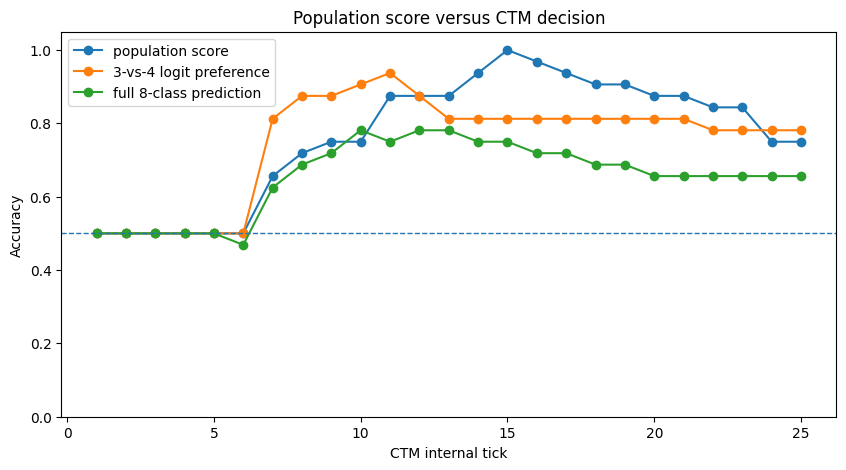

In [102]:
fig, ax = plt.subplots(
    figsize=(
        10,
        5,
    )
)


ax.plot(
    decision_comparison[
        "tick"
    ],
    decision_comparison[
        "population_score_accuracy"
    ],
    marker="o",
    label="population score",
)


ax.plot(
    decision_comparison[
        "tick"
    ],
    decision_comparison[
        "pairwise_logit_accuracy"
    ],
    marker="o",
    label="3-vs-4 logit preference",
)


ax.plot(
    decision_comparison[
        "tick"
    ],
    decision_comparison[
        "full_8class_accuracy"
    ],
    marker="o",
    label="full 8-class prediction",
)


ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
)


ax.set_ylim(
    0,
    1.05,
)

ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "Accuracy"
)

ax.set_title(
    "Population score versus CTM decision"
)

ax.legend()


plt.show()

### Population score versus CTM decision

The frozen population score and the CTM's object-3-versus-object-4 logit preference develop on different schedules.

During the earliest ticks, both binary readouts are at chance, but their signs disagree across all recordings. The pairwise logit preference becomes informative first, reaching high accuracy before the population score.

The population score develops later and reaches 100% sign-based accuracy at tick 15, after which its accuracy declines.

Meanwhile, the mean object-3-versus-object-4 logit difference continues to separate strongly, even though pairwise-logit accuracy no longer improves. This indicates increasing output magnitude without uniformly improving trial-level discrimination.

The full eight-class prediction performs below the binary 3-versus-4 logit comparison because an increasing fraction of recordings are assigned to third objects, reaching roughly one-third at later ticks.

Thus, the group-131 population direction carries decision-relevant information, but it is not simply an earlier copy of the CTM output and does not evolve monotonically with final decision accuracy.

In [103]:
true_oriented_score = np.where(
    b1_b4_pair_labels[
        :,
        None
    ]
    ==
    OBJECT_A,
    b1_b4_pair_score,
    -b1_b4_pair_score,
)

In [104]:
def cohens_d(
    x,
    y,
):

    x = np.asarray(
        x,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )


    nx = len(
        x
    )

    ny = len(
        y
    )


    pooled_var = (
        (
            nx - 1
        )
        *
        x.var(
            ddof=1
        )
        +
        (
            ny - 1
        )
        *
        y.var(
            ddof=1
        )
    ) / (
        nx
        +
        ny
        -
        2
    )


    if pooled_var <= 0:

        return np.nan


    pooled_std = np.sqrt(
        pooled_var
    )


    return (
        x.mean()
        -
        y.mean()
    ) / pooled_std

In [105]:
separation_rows = []


for tick_index in range(
    25
):

    score_A = (
        b1_b4_pair_score[
            b1_b4_pair_labels
            ==
            OBJECT_A,
            tick_index,
        ]
    )

    score_B = (
        b1_b4_pair_score[
            b1_b4_pair_labels
            ==
            OBJECT_B,
            tick_index,
        ]
    )


    separation_rows.append(
        {
            "tick": (
                tick_index
                +
                1
            ),

            "mean_object_A": float(
                score_A.mean()
            ),

            "mean_object_B": float(
                score_B.mean()
            ),

            "mean_difference": float(
                score_A.mean()
                -
                score_B.mean()
            ),

            "cohens_d": float(
                cohens_d(
                    score_A,
                    score_B,
                )
            ),
        }
    )


score_separation = pd.DataFrame(
    separation_rows
)


score_separation

,tick,mean_object_A,mean_object_B,mean_difference,cohens_d
0,1,2.125842,2.049669,0.076173,6.556311
1,2,2.105566,1.895801,0.209765,7.015927
2,3,2.141169,1.652825,0.488343,6.475233
3,4,2.167624,1.534099,0.633525,6.329299
4,5,2.202265,1.145338,1.056927,5.814663
5,6,2.236194,0.654652,1.581542,5.684226
6,7,2.287594,0.339752,1.947842,5.535917
7,8,2.351585,0.114760,2.236825,5.409926
8,9,2.390813,-0.148079,2.538892,5.040189
9,10,2.427149,-0.317395,2.744544,4.719909


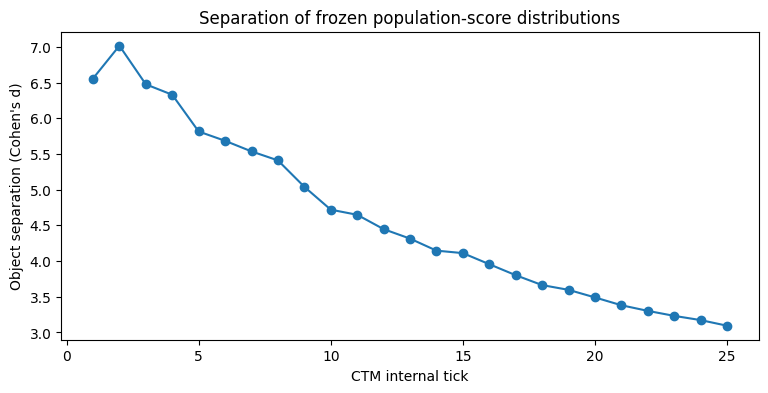

In [106]:
fig, ax = plt.subplots(
    figsize=(
        9,
        4,
    )
)


ax.plot(
    score_separation[
        "tick"
    ],
    score_separation[
        "cohens_d"
    ],
    marker="o",
)


ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "Object separation (Cohen's d)"
)

ax.set_title(
    "Separation of frozen population-score distributions"
)


plt.show()

In [107]:
score_increments = np.diff(
    b1_b4_pair_score,
    axis=1,
)


true_oriented_increments = np.diff(
    true_oriented_score,
    axis=1,
)


print(
    "Increment shape:",
    score_increments.shape,
)

Increment shape: (32, 24)


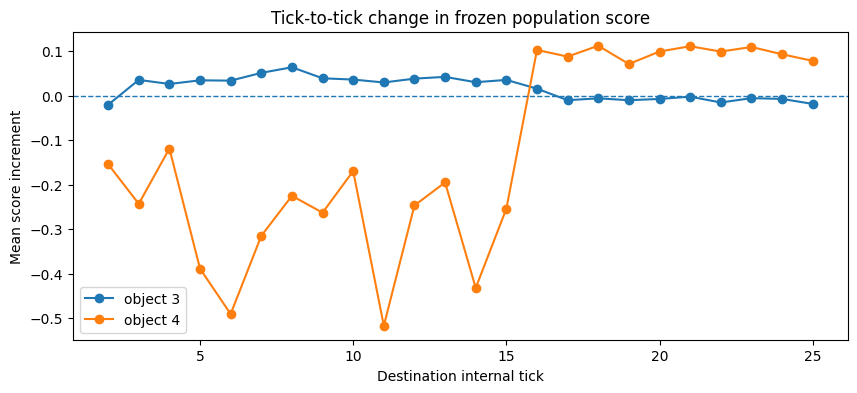

In [108]:
fig, ax = plt.subplots(
    figsize=(
        10,
        4,
    )
)


increment_ticks = np.arange(
    2,
    26,
)


for object_id in [
    OBJECT_A,
    OBJECT_B,
]:

    mask = (
        b1_b4_pair_labels
        ==
        object_id
    )


    mean_increment = (
        score_increments[
            mask
        ]
        .mean(
            axis=0
        )
    )


    ax.plot(
        increment_ticks,
        mean_increment,
        marker="o",
        label=(
            f"object {object_id}"
        ),
    )


ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)


ax.set_xlabel(
    "Destination internal tick"
)

ax.set_ylabel(
    "Mean score increment"
)

ax.set_title(
    "Tick-to-tick change in frozen population score"
)

ax.legend()


plt.show()

In [109]:
score_sign = np.sign(
    b1_b4_pair_score
)


# Treat exact zero as belonging to the positive side,
# consistent with the earlier sign classifier.
score_sign[
    score_sign
    ==
    0
] = 1


sign_reversal_count = np.sum(
    score_sign[
        :,
        1:
    ]
    !=
    score_sign[
        :,
        :-1
    ],
    axis=1,
)


reversal_summary = pd.DataFrame(
    {
        "class_label": (
            b1_b4_pair_labels
        ),

        "correct": (
            b1_b4_pair_metadata[
                "correct"
            ]
            .to_numpy()
        ),

        "sign_reversals": (
            sign_reversal_count
        ),

        "initial_score": (
            b1_b4_pair_score[
                :,
                0
            ]
        ),

        "final_score": (
            b1_b4_pair_score[
                :,
                -1
            ]
        ),

        "score_change": (
            b1_b4_pair_score[
                :,
                -1
            ]
            -
            b1_b4_pair_score[
                :,
                0
            ]
        ),
    }
)


reversal_summary.groupby(
    [
        "class_label",
        "correct",
    ]
).agg(
    n=(
        "sign_reversals",
        "size",
    ),
    mean_reversals=(
        "sign_reversals",
        "mean",
    ),
    max_reversals=(
        "sign_reversals",
        "max",
    ),
    mean_score_change=(
        "score_change",
        "mean",
    ),
)

n  mean_reversals  max_reversals  mean_score_change
class_label correct                                                      
3           False     3             0.0              0           0.708749
            True     13             0.0              0           0.343834
4           False     8             2.0              2          -1.675842
            True      8             1.0              1          -4.415842

In [110]:
late_change = np.abs(
    np.diff(
        b1_b4_pair_score[
            :,
            -5:
        ],
        axis=1,
    )
).mean(
    axis=1
)


late_stability = pd.DataFrame(
    {
        "class_label": (
            b1_b4_pair_labels
        ),

        "correct": (
            b1_b4_pair_metadata[
                "correct"
            ]
            .to_numpy()
        ),

        "mean_absolute_late_increment": (
            late_change
        ),
    }
)


late_stability.groupby(
    [
        "class_label",
        "correct",
    ]
).agg(
    n=(
        "mean_absolute_late_increment",
        "size",
    ),

    median_late_change=(
        "mean_absolute_late_increment",
        "median",
    ),

    mean_late_change=(
        "mean_absolute_late_increment",
        "mean",
    ),
)

n  median_late_change  mean_late_change
class_label correct                                          
3           False     3            0.012229          0.012224
            True     13            0.011121          0.011398
4           False     8            0.082505          0.085036
            True      8            0.103798          0.105222

### Decision-dynamics observations

The frozen population score reveals strongly asymmetric internal dynamics.

Object-related population information is already present at the first tracked tick. Although the midpoint sign rule is at chance at tick 1, the two object-score distributions are already strongly separated relative to their within-object variability.

Absolute separation increases until approximately tick 15, while standardized separation decreases because within-object variability also grows.

Object 3 remains on the positive side of the population axis and changes relatively little. Object 4 moves strongly toward the negative side until approximately tick 15, then partially reverses toward zero.

Sign reversals are also asymmetric. Object-3 recordings show no score-sign reversals. Correct object-4 recordings typically cross the midpoint once, whereas incorrect object-4 recordings cross twice on average, consistent with a late reversal away from the previously correct population direction.

Late activity is nearly stable for object 3 but remains more dynamic for object 4.

These observations are not consistent with a simple symmetric process in which two alternatives begin from an uninformative state and monotonically accumulate evidence toward fixed bounds. They instead suggest transformation of already object-informative population states, with object-dependent settling and reversal dynamics.

In [111]:
BOOTSTRAP_PAIR_SEED = 20260930
N_PAIR_BOOTSTRAPS = 100


rng = np.random.default_rng(
    BOOTSTRAP_PAIR_SEED
)


bootstrap_pair_rows = []


for bootstrap_index in range(
    N_PAIR_BOOTSTRAPS
):

    bootstrap_centroids = {}


    for object_id in sorted(
        np.unique(
            b0_labels
        )
    ):

        object_indices = np.where(
            b0_labels
            ==
            object_id
        )[0]


        sampled_indices = rng.choice(
            object_indices,
            size=len(
                object_indices
            ),
            replace=True,
        )


        bootstrap_centroids[
            int(
                object_id
            )
        ] = (
            b0_pilot_activity[
                sampled_indices
            ]
            .mean(
                axis=(
                    0,
                    1,
                )
            )
        )


    bootstrap_distances = []


    for (
        object_a,
        object_b,
    ) in combinations(
        sorted(
            bootstrap_centroids
        ),
        2,
    ):

        distance = np.linalg.norm(
            bootstrap_centroids[
                object_a
            ]
            -
            bootstrap_centroids[
                object_b
            ]
        )


        bootstrap_distances.append(
            (
                object_a,
                object_b,
                distance,
            )
        )


    selected_a, selected_b, selected_distance = max(
        bootstrap_distances,
        key=lambda row: (
            row[
                2
            ],
            -row[
                0
            ],
            -row[
                1
            ],
        ),
    )


    # Re-estimate the 3-vs-4 direction regardless of
    # which pair wins this particular bootstrap.
    bootstrap_34_direction = (
        bootstrap_centroids[
            OBJECT_A
        ]
        -
        bootstrap_centroids[
            OBJECT_B
        ]
    )


    bootstrap_34_direction /= np.linalg.norm(
        bootstrap_34_direction
    )


    cosine_to_frozen_direction = float(
        np.dot(
            bootstrap_34_direction,
            score_unit_direction,
        )
    )


    bootstrap_pair_rows.append(
        {
            "bootstrap": (
                bootstrap_index
            ),

            "selected_object_a": int(
                selected_a
            ),

            "selected_object_b": int(
                selected_b
            ),

            "selected_distance": float(
                selected_distance
            ),

            "selected_pair_is_3_4": bool(
                {
                    selected_a,
                    selected_b,
                }
                ==
                {
                    OBJECT_A,
                    OBJECT_B,
                }
            ),

            "selected_pair_contains_object_4": bool(
                OBJECT_B
                in
                {
                    selected_a,
                    selected_b,
                }
            ),

            "cosine_34_direction_to_frozen": (
                cosine_to_frozen_direction
            ),
        }
    )


pair_bootstrap = pd.DataFrame(
    bootstrap_pair_rows
)

In [112]:
print(
    "3-vs-4 selected:",
    pair_bootstrap[
        "selected_pair_is_3_4"
    ].mean(),
)


print(
    "Selected pair contains object 4:",
    pair_bootstrap[
        "selected_pair_contains_object_4"
    ].mean(),
)


print()
print(
    "3-vs-4 direction cosine similarity"
)

print(
    pair_bootstrap[
        "cosine_34_direction_to_frozen"
    ].describe()
)


pair_selection_counts = (
    pair_bootstrap
    .groupby(
        [
            "selected_object_a",
            "selected_object_b",
        ]
    )
    .size()
    .sort_values(
        ascending=False
    )
)


pair_selection_counts

3-vs-4 selected: 1.0
Selected pair contains object 4: 1.0

3-vs-4 direction cosine similarity
count    100.000000
mean       0.999993
std        0.000008
min        0.999961
25%        0.999992
50%        0.999997
75%        0.999998
max        1.000000
Name: cosine_34_direction_to_frozen, dtype: float64


selected_object_a  selected_object_b
3                  4                    100
dtype: int64

In [113]:
selected_pair_certainty_rows = []


pair_group131_activity = (
    b1_b4_group_activity[
        b1_b4_pair_mask,
        :,
        group_ids.index(
            131
        ),
    ]
)


for object_id in [
    OBJECT_A,
    OBJECT_B,
]:

    object_mask = (
        b1_b4_pair_labels
        ==
        object_id
    )


    for tick_index in range(
        25
    ):

        r_value = safe_correlation(
            pair_group131_activity[
                object_mask,
                tick_index,
            ],
            pair_certainty[
                object_mask,
                tick_index,
            ],
        )


        selected_pair_certainty_rows.append(
            {
                "object": int(
                    object_id
                ),

                "tick": (
                    tick_index
                    +
                    1
                ),

                "n_recordings": int(
                    object_mask.sum()
                ),

                "r_activity_certainty": (
                    r_value
                ),
            }
        )


selected_pair_certainty = pd.DataFrame(
    selected_pair_certainty_rows
)

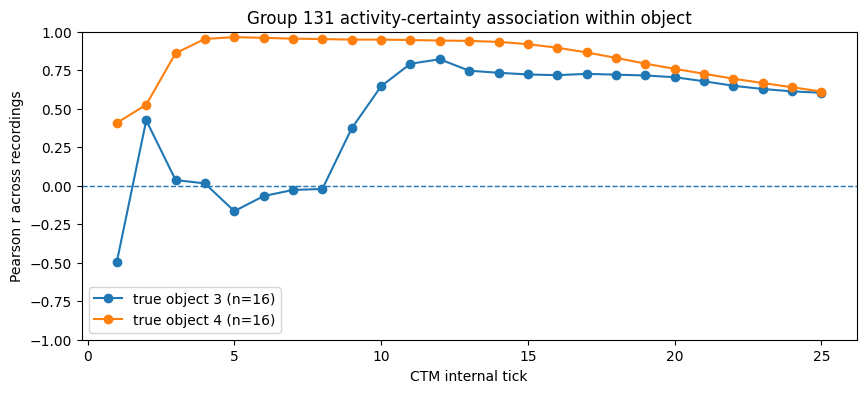

In [114]:
fig, ax = plt.subplots(
    figsize=(
        10,
        4,
    )
)


for object_id in [
    OBJECT_A,
    OBJECT_B,
]:

    data = (
        selected_pair_certainty
        .query(
            "object == @object_id"
        )
    )


    ax.plot(
        data[
            "tick"
        ],
        data[
            "r_activity_certainty"
        ],
        marker="o",
        label=(
            f"true object {object_id} "
            f"(n={data['n_recordings'].iloc[0]})"
        ),
    )


ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)


ax.set_ylim(
    -1,
    1,
)

ax.set_xlabel(
    "CTM internal tick"
)

ax.set_ylabel(
    "Pearson r across recordings"
)

ax.set_title(
    "Group 131 activity-certainty association within object"
)

ax.legend()


plt.show()

### Robustness of the object-directed population axis

The B0-derived object-3-versus-object-4 pilot is highly stable under whole-recording bootstrap resampling.

Across 100 class-stratified B0 resamples:

- object 3 versus object 4 was selected as the maximally separated pair in all 100 resamples,
- the re-estimated 3-versus-4 direction remained almost identical to the frozen direction,
- cosine similarity had mean approximately `0.99999` and minimum approximately `0.99996`.

Thus, within this P1/group-131 pilot, the selected object pair and population direction are robust to the tested B0 recording resampling.

Within-object certainty analysis also shows that activity-certainty coupling differs by object and internal tick. Object 4 shows strong positive coupling over most of computation, whereas object 3 changes from weak or negative early association to strong positive association later.

These results strengthen the descriptive population finding but do not by themselves imply evidence accumulation.

In [115]:
pair_bootstrap.to_csv(
    POPULATION_DIR
    / "signed_score_pair_bootstrap.csv",
    index=False,
)


selected_pair_certainty.to_csv(
    POPULATION_DIR
    / "group131_certainty_within_selected_object.csv",
    index=False,
)


print(
    "Decision-axis robustness results saved."
)

Decision-axis robustness results saved.


## 14. Decision on quantitative DDM modelling

The P1 pilot supports a reproducible object-directed population signal, but the current dynamics do not justify treating that signal as a conventional drift-diffusion process.

The frozen group-131 score:

- distinguishes the selected object pair using a highly stable B0-derived direction,
- transfers to B1-B4,
- develops strong discrimination during internal computation,
- relates to the CTM's output preference without simply duplicating it,
- shows object-dependent settling and reversal dynamics.

However, several observations argue against immediately fitting a standard DDM:

1. object-related information is already present at the first tracked internal state;
2. the two alternatives evolve asymmetrically;
3. discrimination peaks before the final internal tick and subsequently weakens;
4. some trajectories reverse direction rather than approaching a fixed absorbing boundary;
5. the CTM has no observed behavioural reaction time or endogenous stopping event.

**Decision:** the current result is best described as structured internal decision dynamics rather than demonstrated evidence accumulation.

A quantitative accumulation model should only be introduced if a later analysis defines a defensible decision variable and shows that an accumulation model explains its dynamics better than simpler alternatives such as directed transformation or approach to a plateau.